## Setup

In [98]:
from pathlib import Path
import random
import sys
import torch

try:
    import google.colab
    INCOLAB = True
except ImportError:
    INCOLAB = False

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if INCOLAB:
    imagebind_root = Path("/content/ImageBind")
    checkpoint_root = Path("/content")
    nuscenes_root = Path("/content/drive/MyDrive/nuScenes/v1.0-mini")
else:
    imagebind_root = Path.home() / "ImageBind"
    checkpoint_root = Path.home() / "models"
    nuscenes_root = Path.home() / "nuScenes"

if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

checkpoint_file = checkpoint_root / "imagebind_huge.pth"
cache_file = nuscenes_root / "imagebind_nuscenes_embeddings_object_classification.npz"
results_root = nuscenes_root / "uq_results" / "object_classification"

print("Running in Colab:", INCOLAB)
print("Device:", DEVICE)
print("nuScenes root:", nuscenes_root)
print("Cache file:", cache_file)

Running in Colab: False
Device: mps
nuScenes root: /Users/calebcooper/nuScenes
Cache file: /Users/calebcooper/nuScenes/imagebind_nuscenes_embeddings_object_classification.npz


## Connect to Google Drive

## Embedding cache path

In [99]:
# While in Colab, this connects to Google Drive
if INCOLAB:
    from google.colab import drive

    drive.mount("/content/drive", force_remount=False)
    print("Drive is mounted.")

# While in VS Code, this will print instead
else:
    print("Running on VS Code; no Google Drive needed.")

Running on VS Code; no Google Drive needed.


In [100]:
print("Embedding cache path:", cache_file)
print("Embedding cache found:", cache_file.exists())

Embedding cache path: /Users/calebcooper/nuScenes/imagebind_nuscenes_embeddings_object_classification.npz
Embedding cache found: True


In [101]:
# Relabel cache to category-based labels (no attributes)
# This reverts any attribute-based relabeling back to simple category labels.
# vehicle = all vehicle.*, pedestrian = all human.pedestrian.*, static_obstacle = barriers/cones/etc.
# Run this once, then the cache has clean category labels.

if cache_file.exists():
    cache = np.load(cache_file)
    
    # Relabel using annotation categories (not attributes)
    ann_tokens = cache["annotation_tokens"]
    old_labels = cache["y"].copy()
    new_labels = np.zeros(len(ann_tokens), dtype=np.int64)
    
    for idx, ann_token in enumerate(ann_tokens):
        ann = nusc.get("sample_annotation", str(ann_token))
        new_labels[idx] = get_object_label(ann)
    
    changed = (old_labels != new_labels).sum()
    print(f"Relabeled {changed} objects")
    print(f"Old distribution: {dict(zip(['moving_vehicle', 'pedestrian', 'static_obstacle'], np.bincount(old_labels).tolist()))}")
    print(f"New distribution: {dict(zip(CATEGORY_NAMES, np.bincount(new_labels).tolist()))}")
    
    # Save updated cache
    np.savez_compressed(cache_file,
        vision=cache["vision"],
        radar=cache["radar"],
        depth=cache["depth"],
        imu=cache["imu"],
        y=new_labels,
        scene_ids=cache["scene_ids"],
        annotation_tokens=cache["annotation_tokens"])
    cache = np.load(cache_file)
    print("Cache updated with category-based labels")
else:
    print("Cache not found - run encoding first")


Relabeled 0 objects
Old distribution: {'moving_vehicle': 9648, 'pedestrian': 5015, 'static_obstacle': 3790}
New distribution: {'vehicle': 9648, 'pedestrian': 5015, 'static_obstacle': 3790}
Cache updated with category-based labels


## Installing packages

In [102]:
import subprocess

if INCOLAB:
    package_commands = [
        [sys.executable, "-m", "pip", "install", "-q", "--no-deps", "nuscenes-devkit==1.2.0"],
        [sys.executable, "-m", "pip", "install", "-q", "setuptools<81", "pyquaternion", "pycocotools", "fire", "descartes", "parameterized", "ftfy", "regex", "einops", "pytorchvideo==0.1.5", "iopath", "fvcore", "decord", "timm==1.0.27"],
    ]
    for command in package_commands:
        subprocess.run(command, check=True) # This will stop everything if the installation fails in Colab
    print("Packages are ready.")
else:
    print("Running on VS Code; no installs")

Running on VS Code; no installs


## Loading nuScenes and preparing labels

In [103]:
import numpy as np
from collections import Counter
from nuscenes.nuscenes import NuScenes
from nuscenes.utils.data_classes import RadarPointCloud, LidarPointCloud, Box
from nuscenes.utils.geometry_utils import view_points
from pyquaternion import Quaternion
import copy

np.random.seed(SEED)

nuscenes_version = "v1.0-mini"
metadata_directory = nuscenes_root / nuscenes_version
sample_directory = nuscenes_root / "samples"

if not metadata_directory.exists() or not sample_directory.exists():
    raise FileNotFoundError("nuScenes data not found")

results_root.mkdir(parents=True, exist_ok=True)
nusc = NuScenes(version=nuscenes_version, dataroot=str(nuscenes_root), verbose=False)

print(f"nuScenes loaded: {len(nusc.scene)} scenes, {len(nusc.sample)} samples")

# Object category grouping
# Category-based 3-class object classification (NOT motion-state)
# vehicle: all vehicle.* categories (cars, trucks, buses, bicycles, motorcycles)
# pedestrian: all human.pedestrian.* categories
# static_obstacle: barriers, cones, debris, bicycle racks
VEHICLE_CATEGORIES = {
    "vehicle.car", "vehicle.truck", "vehicle.bus.bendy",
    "vehicle.bus.rigid", "vehicle.construction", "vehicle.trailer",
    "vehicle.bicycle", "vehicle.motorcycle",
}
PEDESTRIAN_CATEGORIES = {
    "human.pedestrian.adult", "human.pedestrian.child",
    "human.pedestrian.construction_worker", "human.pedestrian.police_officer",
}
STATIC_CATEGORIES = {
    "movable_object.barrier", "movable_object.debris",
    "movable_object.pushable_pullable", "movable_object.trafficcone",
    "static_object.bicycle_rack",
}
CATEGORY_NAMES = ["vehicle", "pedestrian", "static_obstacle"]
NUM_OBJECT_CLASSES = len(CATEGORY_NAMES)

def get_object_label(annotation_record):
    cat = annotation_record["category_name"]
    if cat in VEHICLE_CATEGORIES:
        return 0  # vehicle
    elif cat in PEDESTRIAN_CATEGORIES:
        return 1  # pedestrian
    elif cat in STATIC_CATEGORIES:
        return 2  # static_obstacle
    return -1

# Count objects per category
all_object_labels = []
for sample in nusc.sample:
    for ann_token in sample["anns"]:
        ann = nusc.get("sample_annotation", ann_token)
        label = get_object_label(ann)
        if label >= 0:
            all_object_labels.append(label)

print(f"Total valid objects: {len(all_object_labels)}")
print(f"Category counts: {Counter(all_object_labels)}")
print(f"Categories: {CATEGORY_NAMES}")

# Sensor constants
CAMERAS = ["CAM_FRONT", "CAM_FRONT_LEFT", "CAM_FRONT_RIGHT",
           "CAM_BACK", "CAM_BACK_LEFT", "CAM_BACK_RIGHT"]
RADAR_CHANNELS = ["RADAR_FRONT", "RADAR_FRONT_LEFT", "RADAR_FRONT_RIGHT",
                  "RADAR_BACK_LEFT", "RADAR_BACK_RIGHT"]

# Per-object camera crop
def find_best_camera(nusc, sample, annotation, dataroot):
    """Find which camera has the best view of the object."""
    box = Box(
        annotation["translation"],
        annotation["size"],
        Quaternion(annotation["rotation"]),
        name=annotation["category_name"])

    best_score = -1
    best_cam = None

    for cam_name in CAMERAS:
        cam_token = sample["data"][cam_name]
        cam_record = nusc.get("sample_data", cam_token)
        cam_cal = nusc.get("calibrated_sensor", cam_record["calibrated_sensor_token"])
        cam_ego = nusc.get("ego_pose", cam_record["ego_pose_token"])

        cam_box = copy.deepcopy(box)
        cam_box.translate(-np.array(cam_ego["translation"]))
        cam_box.rotate(Quaternion(cam_ego["rotation"]).inverse)
        cam_box.translate(-np.array(cam_cal["translation"]))
        cam_box.rotate(Quaternion(cam_cal["rotation"]).inverse)

        corners_3d = cam_box.corners()
        if (corners_3d[2] <= 0).all():
            continue

        corners_2d = view_points(corners_3d, np.array(cam_cal["camera_intrinsic"]), normalize=True)

        with Image.open(dataroot / cam_record["filename"]) as img:
            width, height = img.size

        in_front = corners_3d[2] > 0
        in_bounds = ((corners_2d[0] >= 0) & (corners_2d[0] < width) &
                     (corners_2d[1] >= 0) & (corners_2d[1] < height))
        visible = (in_front & in_bounds).sum()

        if visible > best_score:
            best_score = visible
            best_cam = {
                "name": cam_name,
                "record": cam_record,
                "cal": cam_cal,
                "ego": cam_ego,
                "box_in_cam": cam_box,
            }

    return best_cam

def crop_object_camera(nusc, sample, annotation, best_cam, dataroot, padding=20):
    """Crop the object from the best camera image."""
    cam_record = best_cam["record"]
    cam_cal = best_cam["cal"]
    corners_2d = view_points(best_cam["box_in_cam"].corners(),
                             np.array(cam_cal["camera_intrinsic"]), normalize=True)

    with Image.open(dataroot / cam_record["filename"]) as img:
        width, height = img.size
        x_min = max(0, int(corners_2d[0].min()) - padding)
        x_max = min(width, int(corners_2d[0].max()) + padding)
        y_min = max(0, int(corners_2d[1].min()) - padding)
        y_max = min(height, int(corners_2d[1].max()) + padding)
        if x_max <= x_min or y_max <= y_min:
            return None
        crop = img.crop((x_min, y_min, x_max, y_max))

    return crop

nuScenes loaded: 10 scenes, 404 samples
Total valid objects: 18513
Category counts: Counter({0: 9648, 1: 5015, 2: 3850})
Categories: ['vehicle', 'pedestrian', 'static_obstacle']


## Building the depth and IMU inputs

In [104]:
from PIL import Image
from torchvision import transforms
import torch.nn.functional as F

depth_transform = transforms.Compose([
    transforms.Resize(224, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop((224, 224)),
    transforms.ToTensor()])

vision_transform = transforms.Compose([
    transforms.Resize(224, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop((224, 224)),
    transforms.ToTensor()])

def make_object_depth(nusc, sample, annotation, best_cam, dataroot):
    """Depth image from LiDAR points within the annotation's 3D box."""
    lidar_token = sample["data"]["LIDAR_TOP"]
    lidar_record = nusc.get("sample_data", lidar_token)
    pc = LidarPointCloud.from_file(str(dataroot / lidar_record["filename"]))

    # Transform LiDAR to global frame
    lidar_cal = nusc.get("calibrated_sensor", lidar_record["calibrated_sensor_token"])
    pc.rotate(Quaternion(lidar_cal["rotation"]).rotation_matrix)
    pc.translate(np.array(lidar_cal["translation"]))
    lidar_ego = nusc.get("ego_pose", lidar_record["ego_pose_token"])
    pc.rotate(Quaternion(lidar_ego["rotation"]).rotation_matrix)
    pc.translate(np.array(lidar_ego["translation"]))

    # Filter points within 3D box
    box_center = np.array(annotation["translation"])
    box_size = np.array(annotation["size"])
    box_rot = Quaternion(annotation["rotation"])

    points = pc.points[:3, :]
    centered = points - box_center[:, np.newaxis]
    inv_rot = box_rot.inverse.rotation_matrix
    local = (inv_rot @ centered).T

    inside = (np.abs(local[:, 0]) <= box_size[0]/2) & \
             (np.abs(local[:, 1]) <= box_size[1]/2) & \
             (np.abs(local[:, 2]) <= box_size[2]/2)

    if not inside.any():
        return Image.new("L", (224, 224), 0)

    obj_points = pc.points[:3, inside]

    # Transform to best camera frame (keep pts as (3, M) throughout)
    cam_ego = best_cam["ego"]
    cam_cal = best_cam["cal"]
    # Global -> ego
    pts = obj_points - np.array(cam_ego["translation"])[:, np.newaxis]
    inv_rot_ego = Quaternion(cam_ego["rotation"]).inverse.rotation_matrix
    pts = inv_rot_ego @ pts
    # Ego -> camera sensor
    pts = pts - np.array(cam_cal["translation"])[:, np.newaxis]
    inv_rot_cal = Quaternion(cam_cal["rotation"]).inverse.rotation_matrix
    pts = inv_rot_cal @ pts

    cam_record = best_cam["record"]
    with Image.open(dataroot / cam_record["filename"]) as img:
        width, height = img.size

    projected = view_points(pts, np.array(cam_cal["camera_intrinsic"]), normalize=True)
    depth = pts[2, :]

    valid = (depth > 0) & (projected[0] >= 0) & (projected[0] < width) & \
            (projected[1] >= 0) & (projected[1] < height)

    depth_map = np.zeros((height, width), dtype=np.float32)
    if valid.any():
        np.minimum.at(depth_map,
            (projected[1, valid].astype(int), projected[0, valid].astype(int)),
            depth[valid])

    image = np.zeros_like(depth_map, dtype=np.uint8)
    positive = depth_map > 0
    if positive.any():
        near = depth_map[positive].min()
        far = np.percentile(depth_map[positive], 99)
        scaled = 1 - (depth_map[positive] - near) / max(far - near, 1e-6)
        image[positive] = np.clip(scaled * 255, 0, 255).astype(np.uint8)

    return Image.fromarray(image)

def make_object_radar_bev(nusc, sample, annotation, dataroot, bev_range=15.0, bev_size=224):
    """Small BEV of radar points near the annotation (centered on object)."""
    bev = np.zeros((3, bev_size, bev_size), dtype=np.float32)
    box_center = np.array(annotation["translation"])[:2]

    for channel_name in RADAR_CHANNELS:
        if channel_name not in sample["data"]:
            continue
        radar_token = sample["data"][channel_name]
        radar_record = nusc.get("sample_data", radar_token)
        pc = RadarPointCloud.from_file(str(dataroot / radar_record["filename"]))

        # Transform to global
        radar_cal = nusc.get("calibrated_sensor", radar_record["calibrated_sensor_token"])
        pc.rotate(Quaternion(radar_cal["rotation"]).rotation_matrix)
        pc.translate(np.array(radar_cal["translation"]))
        radar_ego = nusc.get("ego_pose", radar_record["ego_pose_token"])
        pc.rotate(Quaternion(radar_ego["rotation"]).rotation_matrix)
        pc.translate(np.array(radar_ego["translation"]))

        points = pc.points
        x = points[0, :]
        y = points[1, :]

        dx = x - box_center[0]
        dy = y - box_center[1]
        in_range = (np.abs(dx) <= bev_range) & (np.abs(dy) <= bev_range)

        if not in_range.any():
            continue

        x_valid = dx[in_range]
        y_valid = dy[in_range]

        px = ((x_valid + bev_range) / (2 * bev_range) * bev_size).astype(int)
        py = ((y_valid + bev_range) / (2 * bev_range) * bev_size).astype(int)
        px = np.clip(px, 0, bev_size - 1)
        py = np.clip(py, 0, bev_size - 1)

        np.add.at(bev[0], (py, px), 1.0)
        if points.shape[0] > 5:
            np.add.at(bev[1], (py, px), points[5, in_range])
        if points.shape[0] > 9:
            speed = np.sqrt(points[8, in_range]**2 + points[9, in_range]**2)
            np.add.at(bev[2], (py, px), speed)

    for c in range(3):
        max_val = bev[c].max()
        if max_val > 0:
            if c == 1:
                count = bev[0]
                nonzero = count > 0
                bev[c][nonzero] = bev[c][nonzero] / count[nonzero]
                max_val = bev[c].max()
            bev[c] = bev[c] / max(max_val, 1e-6)

    return bev

def get_lidar_ego_pose(nusc, sample_record):
    lidar = nusc.get("sample_data", sample_record["data"]["LIDAR_TOP"])
    return nusc.get("ego_pose", lidar["ego_pose_token"])

def get_ego_motion(nusc, sample_record):
    previous_token = sample_record["prev"]
    if not previous_token:
        return np.zeros(6, dtype=np.float32)
    previous = nusc.get("sample", previous_token)
    current_pose = get_lidar_ego_pose(nusc, sample_record)
    previous_pose = get_lidar_ego_pose(nusc, previous)
    dt = (sample_record["timestamp"] - previous["timestamp"]) / 1e6
    if dt <= 0:
        return np.zeros(6, dtype=np.float32)
    velocity_global = (
        np.asarray(current_pose["translation"]) - np.asarray(previous_pose["translation"])
    ) / dt
    velocity_body = np.asarray(
        Quaternion(current_pose["rotation"]).inverse.rotate(velocity_global),
        dtype=np.float32)
    acceleration_body = np.zeros(3, dtype=np.float32)
    if previous["prev"]:
        older = nusc.get("sample", previous["prev"])
        older_pose = get_lidar_ego_pose(nusc, older)
        previous_dt = (previous["timestamp"] - older["timestamp"]) / 1e6
        previous_velocity_global = (
            np.asarray(previous_pose["translation"]) - np.asarray(older_pose["translation"])
        ) / previous_dt
        previous_velocity_body = np.asarray(
            Quaternion(previous_pose["rotation"]).inverse.rotate(previous_velocity_global))
        acceleration_body = (velocity_body - previous_velocity_body) / dt
    return np.concatenate([velocity_body, acceleration_body]).astype(np.float32)

def make_imu_proxy(nusc, sample_record, window_size=6, target_length=2000):
    history, current = [], sample_record
    for _ in range(window_size):
        history.append(get_ego_motion(nusc, current))
        if not current["prev"]:
            break
        current = nusc.get("sample", current["prev"])
    motion = np.stack(history[::-1], axis=1)
    if motion.shape[1] == 1:
        motion = np.repeat(motion, 2, axis=1)
    return F.interpolate(
        torch.from_numpy(motion).unsqueeze(0),
        size=target_length,
        mode="linear",
        align_corners=True)

def prepare_depth_for_imagebind(depth_image):
    return depth_transform(depth_image).unsqueeze(0)

def prepare_radar_for_imagebind(bev_array):
    return torch.from_numpy(bev_array).float().unsqueeze(0)

# Multi-class Brier score (replaces binary brier_score_loss)
def multiclass_brier_score(labels, probabilities):
    """Brier score for multi-class classification."""
    n = len(labels)
    one_hot = np.zeros((n, probabilities.shape[1]))
    one_hot[np.arange(n), labels] = 1
    return np.mean(np.sum((probabilities - one_hot) ** 2, axis=1))

# Test on first annotation
test_sample = nusc.sample[0]
test_ann = nusc.get("sample_annotation", test_sample["anns"][0])
print(f"Test annotation: {test_ann['category_name']} -> label {get_object_label(test_ann)}")
best_cam = find_best_camera(nusc, test_sample, test_ann, nuscenes_root)
if best_cam:
    print(f"Best camera: {best_cam['name']}")
    cam_crop = crop_object_camera(nusc, test_sample, test_ann, best_cam, nuscenes_root)
    print(f"Camera crop size: {cam_crop.size}")
    depth_img = make_object_depth(nusc, test_sample, test_ann, best_cam, nuscenes_root)
    print(f"Depth image size: {depth_img.size}")
else:
    print("Not visible in any camera")
radar_bev = make_object_radar_bev(nusc, test_sample, test_ann, nuscenes_root)
print(f"Radar BEV shape: {radar_bev.shape}, nonzero: {(radar_bev > 0).sum()}")
imu = make_imu_proxy(nusc, test_sample)
print(f"IMU shape: {imu.shape}")

Test annotation: human.pedestrian.adult -> label 1
Best camera: CAM_FRONT
Camera crop size: (59, 76)
Depth image size: (1600, 900)
Radar BEV shape: (3, 224, 224), nonzero: 24
IMU shape: torch.Size([1, 6, 2000])


In [105]:
# Quick test: verify per-object extraction works on a few annotations
test_count = 0
for sample in nusc.sample[:3]:
    for ann_token in sample["anns"][:3]:
        ann = nusc.get("sample_annotation", ann_token)
        label = get_object_label(ann)
        if label < 0:
            continue
        best_cam = find_best_camera(nusc, sample, ann, nuscenes_root)
        if best_cam:
            cam = crop_object_camera(nusc, sample, ann, best_cam, nuscenes_root)
            depth = make_object_depth(nusc, sample, ann, best_cam, nuscenes_root)
            radar = make_object_radar_bev(nusc, sample, ann, nuscenes_root)
            print(f"  {ann['category_name']:40s} cam={best_cam['name']:15s} "
                  f"crop={cam.size} radar_nz={(radar>0).sum()}")
            test_count += 1
        else:
            print(f"  {ann['category_name']:40s} NOT VISIBLE")
print(f"\nTested {test_count} objects from 3 samples")

  human.pedestrian.adult                   cam=CAM_FRONT       crop=(59, 76) radar_nz=24
  human.pedestrian.adult                   cam=CAM_FRONT       crop=(73, 102) radar_nz=23
  vehicle.car                              cam=CAM_FRONT_RIGHT crop=(148, 71) radar_nz=3
  human.pedestrian.adult                   cam=CAM_FRONT       crop=(62, 79) radar_nz=15
  human.pedestrian.adult                   cam=CAM_FRONT_RIGHT crop=(83, 103) radar_nz=34
  vehicle.car                              cam=CAM_FRONT_RIGHT crop=(150, 73) radar_nz=3
  human.pedestrian.adult                   cam=CAM_FRONT       crop=(65, 83) radar_nz=15
  human.pedestrian.adult                   cam=CAM_FRONT_RIGHT crop=(85, 108) radar_nz=21
  vehicle.car                              cam=CAM_FRONT_RIGHT crop=(152, 74) radar_nz=3

Tested 9 objects from 3 samples


In [106]:
rebuild_cache = False  # Set to True only if you need to re-encode
if cache_file.exists() and not rebuild_cache:
    cache = np.load(cache_file)
    print("Using existing embedding cache:", cache_file)
else:
    import os
    if not imagebind_root.exists():
        subprocess.run(["git", "clone", "https://github.com/facebookresearch/ImageBind.git", str(imagebind_root)], check=True)
    if not checkpoint_file.exists():
        subprocess.run(["wget", "-O", str(checkpoint_file), "https://dl.fbaipublicfiles.com/imagebind/imagebind_huge.pth"], check=True)
    imagebind_path = str(imagebind_root)
    if imagebind_path not in sys.path:
        sys.path.insert(0, imagebind_path)
    import torchvision.transforms._functional_tensor as functional_tensor
    sys.modules["torchvision.transforms.functional_tensor"] = functional_tensor
    from imagebind import data
    from imagebind.models import imagebind_model
    from imagebind.models.imagebind_model import ModalityType

    imagebind_encoder = imagebind_model.imagebind_huge(pretrained=False)
    imagebind_encoder.load_state_dict(torch.load(checkpoint_file, map_location="cpu"))
    imagebind_encoder.to(DEVICE).eval()
    for parameter in imagebind_encoder.parameters():
        parameter.requires_grad = False

    imagenet_mean = torch.tensor([0.485, 0.456, 0.406], device=DEVICE).view(1, 3, 1, 1)
    imagenet_std = torch.tensor([0.229, 0.224, 0.225], device=DEVICE).view(1, 3, 1, 1)

    def encode_one_object(nusc, annotation, sample_record, dataroot):
        best_cam = find_best_camera(nusc, sample_record, annotation, dataroot)
        if best_cam is None:
            return None

        cam_crop = crop_object_camera(nusc, sample_record, annotation, best_cam, dataroot)
        if cam_crop is None:
            return None
        vision_input = vision_transform(cam_crop).unsqueeze(0).to(DEVICE)

        radar_bev = make_object_radar_bev(nusc, sample_record, annotation, dataroot)
        radar_input = prepare_radar_for_imagebind(radar_bev).to(DEVICE)
        radar_input = (radar_input - imagenet_mean) / imagenet_std

        depth_img = make_object_depth(nusc, sample_record, annotation, best_cam, dataroot)
        depth_input = prepare_depth_for_imagebind(depth_img).to(DEVICE)

        imu_input = make_imu_proxy(nusc, sample_record).to(DEVICE)

        with torch.no_grad():
            encoded_vision = imagebind_encoder({ModalityType.VISION: vision_input})
            encoded_radar = imagebind_encoder({ModalityType.VISION: radar_input})
            encoded_rest = imagebind_encoder({
                ModalityType.DEPTH: depth_input,
                ModalityType.IMU: imu_input})

        return {
            "vision": encoded_vision[ModalityType.VISION].squeeze(0).cpu().numpy(),
            "radar": encoded_radar[ModalityType.VISION].squeeze(0).cpu().numpy(),
            "depth": encoded_rest[ModalityType.DEPTH].squeeze(0).cpu().numpy(),
            "imu": encoded_rest[ModalityType.IMU].squeeze(0).cpu().numpy(),
            "label": get_object_label(annotation),
            "scene_id": sample_record["scene_token"],
            "annotation_token": annotation["token"]}

    # Build list of all valid objects
    from tqdm.auto import tqdm
    object_list = []
    for sample_record in tqdm(nusc.sample, desc="Scanning annotations"):
        for ann_token in sample_record["anns"]:
            ann = nusc.get("sample_annotation", ann_token)
            label = get_object_label(ann)
            if label >= 0:
                object_list.append((ann, sample_record))

    print(f"Found {len(object_list)} valid objects to encode")

    # Encode each object
    rows = []
    skipped = 0
    for ann, sample_record in tqdm(object_list, desc="Encoding objects"):
        result = encode_one_object(nusc, ann, sample_record, nuscenes_root)
        if result is not None:
            rows.append(result)
        else:
            skipped += 1

    print(f"Encoded {len(rows)} objects, skipped {skipped} (not visible in any camera)")

    np.savez_compressed(cache_file,
        vision=np.stack([row["vision"] for row in rows]).astype(np.float32),
        radar=np.stack([row["radar"] for row in rows]).astype(np.float32),
        depth=np.stack([row["depth"] for row in rows]).astype(np.float32),
        imu=np.stack([row["imu"] for row in rows]).astype(np.float32),
        y=np.asarray([row["label"] for row in rows], dtype=np.int64),
        scene_ids=np.asarray([row["scene_id"] for row in rows]),
        annotation_tokens=np.asarray([row["annotation_token"] for row in rows]))
    del imagebind_encoder
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    cache = np.load(cache_file)
    print("Created embedding cache (object classification):", cache_file)
    print("Cache shapes:", {key: cache[key].shape for key in ["vision", "radar", "depth", "imu", "y"]})
    print("Label distribution:", dict(zip(CATEGORY_NAMES, np.bincount(cache["y"]).tolist())))

Using existing embedding cache: /Users/calebcooper/nuScenes/imagebind_nuscenes_embeddings_object_classification.npz


In [107]:
scene_ids = cache["scene_ids"]
labels = cache["y"]
num_classes = NUM_OBJECT_CLASSES

# Split by scene — search for the most balanced split across seeds
# With only 10 scenes, random splitting can put all of one class in test
# Try multiple seeds and pick the one with the most balanced class distribution
unique_scenes = np.unique(scene_ids)
n_scenes = len(unique_scenes)
n_test = max(num_classes, n_scenes // 5)
n_val = max(num_classes, n_scenes // 5)

# Count class distribution per scene
scene_class_counts = {}
for scene in unique_scenes:
    scene_mask = scene_ids == scene
    scene_class_counts[scene] = np.bincount(labels[scene_mask], minlength=num_classes)

best_seed = 42
best_score = float('inf')
for trial_seed in range(1000):
    rng = np.random.default_rng(trial_seed)
    shuffled = unique_scenes.copy()
    rng.shuffle(shuffled)

    test_s = shuffled[:n_test]
    val_s = shuffled[n_test:n_test + n_val]
    train_s = shuffled[n_test + n_val:]

    train_counts = np.zeros(num_classes, dtype=int)
    val_counts = np.zeros(num_classes, dtype=int)
    test_counts = np.zeros(num_classes, dtype=int)
    for s in train_s:
        train_counts += scene_class_counts[s]
    for s in val_s:
        val_counts += scene_class_counts[s]
    for s in test_s:
        test_counts += scene_class_counts[s]

    # Score: minimize the coefficient of variation of class proportions across splits
    # We want each class to be roughly proportional in train/val/test
    total_per_class = train_counts + val_counts + test_counts
    train_prop = train_counts / total_per_class
    val_prop = val_counts / total_per_class
    test_prop = test_counts / total_per_class

    # Ideal: train ~60%, val ~30%, test ~30% of each class (with 4/3/3 scene split)
    ideal_train = 0.4
    ideal_val = 0.3
    ideal_test = 0.3

    score = (np.abs(train_prop - ideal_train).sum() +
             np.abs(val_prop - ideal_val).sum() +
             np.abs(test_prop - ideal_test).sum())

    # Also penalize any split having zero of a class
    for counts in [train_counts, val_counts, test_counts]:
        if (counts == 0).any():
            score += 1000

    if score < best_score:
        best_score = score
        best_seed = trial_seed
        best_split = (train_s, val_s, test_s, train_counts, val_counts, test_counts)

print(f"Best split found at seed {best_seed} (balance score: {best_score:.3f})")

train_scenes, validation_scenes, test_scenes, train_counts, val_counts, test_counts = best_split

train_mask = np.isin(scene_ids, train_scenes)
validation_mask = np.isin(scene_ids, validation_scenes)
test_mask = np.isin(scene_ids, test_scenes)

train_indices = np.where(train_mask)[0]
validation_indices = np.where(validation_mask)[0]
test_indices = np.where(test_mask)[0]

print(f"Scenes: {len(train_scenes)} train / {len(validation_scenes)} val / {len(test_scenes)} test")
print(f"Objects: {len(train_indices)} train / {len(validation_indices)} val / {len(test_indices)} test")
print(f"Categories: {CATEGORY_NAMES}")
print(f"Train class counts: {train_counts}")
print(f"Val class counts: {val_counts}")
print(f"Test class counts: {test_counts}")

Best split found at seed 264 (balance score: 0.777)
Scenes: 4 train / 3 val / 3 test
Objects: 8724 train / 5080 val / 4649 test
Categories: ['vehicle', 'pedestrian', 'static_obstacle']
Train class counts: [4018 1985 2721]
Val class counts: [3254 1590  236]
Test class counts: [2376 1440  833]


In [108]:
from torch.utils.data import Dataset, DataLoader

class FourModalEmbeddingDataset(Dataset):
    def __init__(self, cache_file, indices):
        self.vision = torch.from_numpy(cache_file["vision"][indices]).float()
        self.radar = torch.from_numpy(cache_file["radar"][indices]).float()
        self.depth = torch.from_numpy(cache_file["depth"][indices]).float()
        self.imu = torch.from_numpy(cache_file["imu"][indices]).float()
        self.labels = torch.from_numpy(cache_file["y"][indices]).long()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "vision": self.vision[idx],
            "radar": self.radar[idx],
            "depth": self.depth[idx],
            "imu": self.imu[idx],
            "label": self.labels[idx]}

batch_size = 32
train_dataset = FourModalEmbeddingDataset(cache, train_indices)
validation_dataset = FourModalEmbeddingDataset(cache, validation_indices)
test_dataset = FourModalEmbeddingDataset(cache, test_indices)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print("Train loader length:", len(train_loader))
print("Validation loader length:", len(validation_loader))
print("Test loader length:", len(test_loader))


Train loader length: 273
Validation loader length: 159
Test loader length: 146


In [109]:
import torch.nn as nn

embedding_dim = 1024
adapter_hidden_dim = 256
dropout_rate = 0.35
num_classes = NUM_OBJECT_CLASSES
modality_order = ("vision", "radar", "depth", "imu")

class ModalityAdapter(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, output_dim),
            nn.GELU(),
            nn.Linear(output_dim, output_dim))

    def forward(self, embedding):
        return self.network(embedding)

class PresenceAwareFusion(nn.Module):
    def __init__(self):
        super().__init__()
        self.depth_pre_norm = nn.LayerNorm(embedding_dim)
        self.vision_adapter = ModalityAdapter(embedding_dim, adapter_hidden_dim)
        self.radar_adapter = ModalityAdapter(embedding_dim, adapter_hidden_dim)
        self.depth_adapter = ModalityAdapter(embedding_dim, adapter_hidden_dim)
        self.imu_adapter = ModalityAdapter(embedding_dim, adapter_hidden_dim)
        self.gate = nn.Sequential(
            nn.Linear((4 * adapter_hidden_dim) + 4, adapter_hidden_dim),
            nn.GELU(),
            nn.Linear(adapter_hidden_dim, 4))
        self.no_input_embedding = nn.Parameter(torch.zeros(adapter_hidden_dim))
        self.classifier = nn.Sequential(
            nn.Linear(adapter_hidden_dim, adapter_hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(adapter_hidden_dim, num_classes))

    def forward(self, vision, radar, depth, imu, presence_mask=None):
        batch_size = vision.size(0)
        if presence_mask is None:
            presence_mask = torch.ones(
                batch_size, 4, device=vision.device, dtype=vision.dtype)
        adapted = torch.stack([
            self.vision_adapter(vision),
            self.radar_adapter(radar),
            self.depth_adapter(self.depth_pre_norm(depth)),
            self.imu_adapter(imu)], dim=1)
        adapted = adapted * presence_mask.unsqueeze(-1)
        gate_input = torch.cat([adapted.flatten(start_dim=1), presence_mask], dim=1)
        gate_logits = self.gate(gate_input).masked_fill(presence_mask == 0, -1e9)
        gate_weights = torch.softmax(gate_logits, dim=1) * presence_mask
        normalizer = gate_weights.sum(dim=1, keepdim=True).clamp_min(1e-12)
        gate_weights = gate_weights / normalizer
        fused = (adapted * gate_weights.unsqueeze(-1)).sum(dim=1)
        no_input = presence_mask.sum(dim=1, keepdim=True) == 0
        fused = torch.where(no_input, self.no_input_embedding.unsqueeze(0).expand(batch_size, -1), fused)
        return self.classifier(fused), gate_weights

fusion_model = PresenceAwareFusion().to(DEVICE)
print("Trainable parameters:", sum(
    parameter.numel() for parameter in fusion_model.parameters()
    if parameter.requires_grad))
print(f"Number of classes: {num_classes} ({CATEGORY_NAMES})")

Trainable parameters: 1646087
Number of classes: 3 (['vehicle', 'pedestrian', 'static_obstacle'])


In [110]:
clean_batch = next(iter(train_loader))
vision_batch = clean_batch["vision"].to(DEVICE)
radar_batch = clean_batch["radar"].to(DEVICE)
depth_batch = clean_batch["depth"].to(DEVICE)
imu_batch = clean_batch["imu"].to(DEVICE)

with torch.no_grad():
    logits, gate_weights = fusion_model(vision_batch, radar_batch, depth_batch, imu_batch)
print("Logits shape:", logits.shape)
print("Gate-weight shape:", gate_weights.shape)
print("First sample gate weights:", gate_weights[0].cpu().numpy())
print("First sample gate-weight sum:", gate_weights[0].sum().item())


Logits shape: torch.Size([32, 3])
Gate-weight shape: torch.Size([32, 4])
First sample gate weights: [0.2555793  0.25193456 0.23759532 0.25489092]
First sample gate-weight sum: 1.0000001192092896


In [111]:
from torch.optim import AdamW

learning_rate = 3e-4
weight_decay = 1e-4
max_epochs = 50
early_stopping_patience = 10
train_modality_dropout_rate = 0.20
train_all_missing_rate = 0.02
train_class_counts = torch.bincount(train_dataset.labels)
class_weights = (train_class_counts.sum() / (num_classes * train_class_counts.float())).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = AdamW(
    fusion_model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay)
def sample_training_presence(batch_size, device):
    mask = (torch.rand(batch_size, 4, device=device) > train_modality_dropout_rate).float()
    force_all_missing = (torch.rand(batch_size, device=device) < train_all_missing_rate)
    mask[force_all_missing] = 0
    return mask

print("Training class counts:", train_class_counts.tolist())
print("Class weights:", class_weights.cpu().numpy())
print("Training modality-drop rate:", train_modality_dropout_rate)



TRAINING_MODE = "fedprox" 
NUM_FEDERATED_CLIENTS = 4   
COMMUNICATION_ROUNDS = 30
LOCAL_EPOCHS = 1
FEDPROX_MU = 0.01

if TRAINING_MODE not in {"centralized", "fedavg", "fedprox"}:
    raise ValueError("TRAINING_MODE must be centralized, fedavg, or fedprox")
if FEDPROX_MU < 0:
    raise ValueError("FEDPROX_MU must be nonnegative")

print("Training mode:", TRAINING_MODE)
if TRAINING_MODE != "centralized":
    print(
        f"Federated setup: {NUM_FEDERATED_CLIENTS} clients, "
        f"{COMMUNICATION_ROUNDS} rounds, {LOCAL_EPOCHS} local epoch(s), "
        f"mu={0.0 if TRAINING_MODE == 'fedavg' else FEDPROX_MU}"
    )


Training class counts: [4018, 1985, 2721]
Class weights: [0.72374314 1.4649874  1.0687248 ]
Training modality-drop rate: 0.2
Training mode: fedprox
Federated setup: 4 clients, 30 rounds, 1 local epoch(s), mu=0.01


## FedProx

The four training scenes are divided between four simulated clients, giving each client one complete scene. At each communication round, all four clients receive the same global fusion model and locally train the depth normalization, four modality adapters, presence-aware gate, no-input embedding, and three-class classifier. Cached ImageBind embeddings remain fixed. Local training retains the notebook's class-weighted cross-entropy and training-time modality dropout. FedProx adds $\frac{\mu}{2}\lVert w_k-w^{(t)}\rVert_2^2$ to that local loss. The server performs sample-count-weighted parameter averaging. `TRAINING_MODE="fedavg"` sets $\mu=0$; `TRAINING_MODE="fedprox"` uses `FEDPROX_MU`. Validation, test, MCAR/MNAR, MC-dropout, calibration, and multi-seed analyses remain scene-disjoint and otherwise unchanged.


In [112]:
# Scene-based FedAvg/FedProx simulation
from collections import OrderedDict
import pandas as pd

def build_scene_clients(train_indices, scene_ids, labels, num_clients, seed=42):
    """Assign complete training scenes to clients while balancing object counts."""
    scenes = np.unique(scene_ids[train_indices]).copy()
    if num_clients < 2:
        raise ValueError("Federated training requires at least two clients")
    if num_clients > len(scenes):
        raise ValueError(
            f"Requested {num_clients} clients but only {len(scenes)} training scenes exist"
        )

    rng = np.random.default_rng(seed)
    rng.shuffle(scenes)
    records = []
    for scene in scenes:
        idx = train_indices[scene_ids[train_indices] == scene]
        counts = np.bincount(labels[idx], minlength=num_classes)
        records.append((scene, idx, counts))
    records.sort(key=lambda row: len(row[1]), reverse=True)

    assignments = [[] for _ in range(num_clients)]
    client_sizes = np.zeros(num_clients, dtype=int)
    client_class_counts = np.zeros((num_clients, num_classes), dtype=int)

    for scene, idx, counts in records:
        # Prefer the client with the fewest objects; class imbalance breaks ties.
        scores = []
        for client_id in range(num_clients):
            projected = client_class_counts[client_id] + counts
            imbalance = projected.max() - projected.min()
            scores.append((client_sizes[client_id], imbalance, client_id))
        client_id = min(scores)[2]
        assignments[client_id].append((scene, idx))
        client_sizes[client_id] += len(idx)
        client_class_counts[client_id] += counts

    client_indices = [
        np.concatenate([idx for _, idx in assignment]).astype(int)
        for assignment in assignments
    ]
    rows = []
    for client_id, (assignment, idx) in enumerate(zip(assignments, client_indices)):
        row = {
            "client": client_id,
            "n_objects": len(idx),
            "scenes": ", ".join(str(scene) for scene, _ in assignment),
        }
        for class_id, class_name in enumerate(CATEGORY_NAMES):
            row[f"n_{class_name}"] = int((labels[idx] == class_id).sum())
        rows.append(row)
    return client_indices, pd.DataFrame(rows)


federated_client_indices = None
federated_client_datasets = None
federated_partition_df = None
if TRAINING_MODE in {"fedavg", "fedprox"}:
    federated_client_indices, federated_partition_df = build_scene_clients(
        train_indices=train_indices,
        scene_ids=scene_ids,
        labels=labels,
        num_clients=NUM_FEDERATED_CLIENTS,
        seed=42,
    )
    federated_client_datasets = [
        FourModalEmbeddingDataset(cache, indices)
        for indices in federated_client_indices
    ]
    display(federated_partition_df)
    federated_partition_df.to_csv(
        results_root / "fedprox_client_partition.csv", index=False
    )


def make_client_loader(dataset, seed):
    generator = torch.Generator()
    generator.manual_seed(seed)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        generator=generator,
    )


def train_local_client(global_model, dataset, mu, round_seed):
    """Train one client from the current global state and return its parameters."""
    local_model = copy.deepcopy(global_model).to(DEVICE)
    local_model.train()
    global_anchor = {
        name: parameter.detach().clone()
        for name, parameter in global_model.named_parameters()
        if parameter.requires_grad
    }
    local_optimizer = AdamW(
        local_model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )
    loader = make_client_loader(dataset, round_seed)
    task_loss_sum = 0.0
    proximal_norm_sum = 0.0
    examples_seen = 0

    for _ in range(LOCAL_EPOCHS):
        for batch in loader:
            inputs = [batch[name].to(DEVICE) for name in modality_order]
            targets = batch["label"].to(DEVICE)
            presence = sample_training_presence(len(targets), DEVICE)

            local_optimizer.zero_grad(set_to_none=True)
            logits, _ = local_model(*inputs, presence_mask=presence)
            task_loss = criterion(logits, targets)
            proximal_norm = torch.zeros((), device=DEVICE)
            if mu > 0:
                for name, parameter in local_model.named_parameters():
                    if parameter.requires_grad:
                        proximal_norm = proximal_norm + torch.sum(
                            (parameter - global_anchor[name]) ** 2
                        )
            loss = task_loss + 0.5 * mu * proximal_norm
            loss.backward()
            torch.nn.utils.clip_grad_norm_(local_model.parameters(), max_norm=1.0)
            local_optimizer.step()

            task_loss_sum += task_loss.item() * len(targets)
            proximal_norm_sum += proximal_norm.item() * len(targets)
            examples_seen += len(targets)

    state = OrderedDict(
        (name, tensor.detach().cpu().clone())
        for name, tensor in local_model.state_dict().items()
    )
    diagnostics = {
        "task_loss": task_loss_sum / max(examples_seen, 1),
        "proximal_norm_sq": proximal_norm_sum / max(examples_seen, 1),
    }
    del local_model
    return state, len(dataset), diagnostics


def sample_weighted_average(client_updates):
    """FedAvg server aggregation, also used by FedProx."""
    total_samples = sum(n_samples for _, n_samples, _ in client_updates)
    averaged = OrderedDict()
    first_state = client_updates[0][0]
    for name, first_tensor in first_state.items():
        if torch.is_floating_point(first_tensor):
            value = torch.zeros_like(first_tensor)
            for state, n_samples, _ in client_updates:
                value += state[name] * (n_samples / total_samples)
            averaged[name] = value
        else:
            averaged[name] = first_tensor.clone()
    return averaged


def train_federated(global_model, seed, checkpoint_path=None):
    """Synchronous, full-participation FedAvg/FedProx with validation stopping."""
    if federated_client_datasets is None:
        raise RuntimeError("Run the federated client-partition cell first")

    set_seed = globals().get("set_experiment_seed")
    if set_seed is not None:
        set_seed(seed)
    else:
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

    mu = 0.0 if TRAINING_MODE == "fedavg" else FEDPROX_MU
    best_validation_f1 = -np.inf
    best_state = copy.deepcopy(global_model.state_dict())
    rounds_without_improvement = 0
    history = []

    for round_id in range(1, COMMUNICATION_ROUNDS + 1):
        updates = []
        for client_id, dataset in enumerate(federated_client_datasets):
            update = train_local_client(
                global_model,
                dataset,
                mu=mu,
                round_seed=seed * 100000 + round_id * 100 + client_id,
            )
            updates.append(update)

        global_model.load_state_dict(sample_weighted_average(updates))
        global_model.to(DEVICE)
        validation_accuracy, validation_f1 = evaluate_model(
            global_model, validation_loader
        )
        weighted_task_loss = np.average(
            [item[2]["task_loss"] for item in updates],
            weights=[item[1] for item in updates],
        )
        weighted_proximal_norm = np.average(
            [item[2]["proximal_norm_sq"] for item in updates],
            weights=[item[1] for item in updates],
        )
        history.append({
            "round": round_id,
            "seed": seed,
            "algorithm": TRAINING_MODE,
            "mu": mu,
            "train_task_loss": float(weighted_task_loss),
            "proximal_norm_sq": float(weighted_proximal_norm),
            "validation_accuracy": validation_accuracy,
            "validation_macro_f1": validation_f1,
        })
        print(
            f"Round {round_id:02d} | {TRAINING_MODE.upper()} mu={mu:g} | "
            f"Task loss: {weighted_task_loss:.4f} | "
            f"Prox norm²: {weighted_proximal_norm:.4f} | "
            f"Val acc: {validation_accuracy:.3f} | Val Macro F1: {validation_f1:.3f}"
        )

        if validation_f1 > best_validation_f1:
            best_validation_f1 = validation_f1
            best_state = copy.deepcopy(global_model.state_dict())
            rounds_without_improvement = 0
        else:
            rounds_without_improvement += 1
            if rounds_without_improvement >= early_stopping_patience:
                print("Federated early stopping: validation Macro F1 did not improve.")
                break

    global_model.load_state_dict(best_state)
    history_df = pd.DataFrame(history)
    if checkpoint_path is not None:
        torch.save({
            "model_state": best_state,
            "algorithm": TRAINING_MODE,
            "mu": mu,
            "seed": seed,
            "best_validation_macro_f1": float(best_validation_f1),
            "client_partition": federated_partition_df.to_dict(orient="records"),
        }, checkpoint_path)
    return global_model, best_validation_f1, history_df


,client,n_objects,scenes,n_vehicle,n_pedestrian,n_static_obstacle
0,0,4693,cc8c0bf57f984915a77078b10eb33198,728,1393,2572
1,1,2406,325cef682f064c55a255f2625c533b75,1979,427,0
2,2,909,d25718445d89453381c659b9c8734939,764,0,145
3,3,716,c5224b9b454b4ded9b5d2d2634bbda8a,547,165,4


In [113]:
%pip install pandas


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [114]:
import copy
from sklearn.metrics import accuracy_score, f1_score

algorithm_tag = (
    "centralized" if TRAINING_MODE == "centralized"
    else f"{TRAINING_MODE}_mu_{0.0 if TRAINING_MODE == 'fedavg' else FEDPROX_MU:g}"
)
fusion_checkpoint_file = results_root / f"best_fusion_model_{algorithm_tag}.pt"

def evaluate_model(model, data_loader):
    # Evaluation uses all four modalities and disables ordinary dropout.
    model.eval()
    all_labels = []
    all_predictions = []
    with torch.no_grad():
        for batch in data_loader:
            inputs = [batch[name].to(DEVICE) for name in modality_order]
            labels_batch = batch["label"].to(DEVICE)
            logits, _ = model(*inputs)
            predictions = logits.argmax(dim=1)
            all_labels.extend(labels_batch.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())
    accuracy = accuracy_score(all_labels, all_predictions)
    macro_f1 = f1_score(all_labels, all_predictions, average="macro")
    return accuracy, macro_f1


retrain_model = True
if fusion_checkpoint_file.exists() and not retrain_model:
    saved = torch.load(fusion_checkpoint_file, map_location=DEVICE)
    saved_state = saved.get("model_state", saved) if isinstance(saved, dict) else saved
    fusion_model.load_state_dict(saved_state)
    print("Loaded existing fusion checkpoint:", fusion_checkpoint_file)
else:
    if TRAINING_MODE in {"fedavg", "fedprox"}:
        fusion_model, best_validation_f1, federated_training_history = train_federated(
            global_model=fusion_model,
            seed=42,
            checkpoint_path=fusion_checkpoint_file,
        )
        federated_training_history.to_csv(
            results_root / f"federated_training_history_{algorithm_tag}.csv",
            index=False,
        )
    else:
        best_validation_f1 = -float("inf")
        best_model_state = None
        epochs_without_improvement = 0
        training_history = {
            "train_loss": [],
            "validation_accuracy": [],
            "validation_macro_f1": [],
        }
        for epoch in range(1, max_epochs + 1):
            fusion_model.train()
            running_loss = 0.0
            for batch in train_loader:
                inputs = [batch[name].to(DEVICE) for name in modality_order]
                labels_batch = batch["label"].to(DEVICE)
                optimizer.zero_grad(set_to_none=True)
                training_presence = sample_training_presence(
                    labels_batch.size(0), DEVICE
                )
                logits, _ = fusion_model(
                    *inputs, presence_mask=training_presence
                )
                loss = criterion(logits, labels_batch)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    fusion_model.parameters(), max_norm=1.0
                )
                optimizer.step()
                running_loss += loss.item() * labels_batch.size(0)

            average_train_loss = running_loss / len(train_dataset)
            validation_accuracy, validation_macro_f1 = evaluate_model(
                fusion_model, validation_loader
            )
            training_history["train_loss"].append(average_train_loss)
            training_history["validation_accuracy"].append(validation_accuracy)
            training_history["validation_macro_f1"].append(validation_macro_f1)
            print(
                f"Epoch {epoch:02d} | Train loss: {average_train_loss:.4f} | "
                f"Validation accuracy: {validation_accuracy:.3f} | "
                f"Validation Macro F1: {validation_macro_f1:.3f}"
            )
            if validation_macro_f1 > best_validation_f1:
                best_validation_f1 = validation_macro_f1
                best_model_state = copy.deepcopy(fusion_model.state_dict())
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1
            if epochs_without_improvement >= early_stopping_patience:
                print("Early stopping: validation Macro F1 did not improve.")
                break
        fusion_model.load_state_dict(best_model_state)
        torch.save(fusion_model.state_dict(), fusion_checkpoint_file)

    print("Best validation Macro F1:", best_validation_f1)
    print("Best model saved to:", fusion_checkpoint_file)


Round 01 | FEDPROX mu=0.01 | Task loss: 0.8597 | Prox norm²: 3.7429 | Val acc: 0.638 | Val Macro F1: 0.261
Round 02 | FEDPROX mu=0.01 | Task loss: 0.8367 | Prox norm²: 2.6671 | Val acc: 0.626 | Val Macro F1: 0.384
Round 03 | FEDPROX mu=0.01 | Task loss: 0.8269 | Prox norm²: 2.1358 | Val acc: 0.311 | Val Macro F1: 0.165
Round 04 | FEDPROX mu=0.01 | Task loss: 0.8226 | Prox norm²: 1.9302 | Val acc: 0.338 | Val Macro F1: 0.222
Round 05 | FEDPROX mu=0.01 | Task loss: 0.8199 | Prox norm²: 1.7367 | Val acc: 0.336 | Val Macro F1: 0.220
Round 06 | FEDPROX mu=0.01 | Task loss: 0.8228 | Prox norm²: 1.7208 | Val acc: 0.639 | Val Macro F1: 0.415
Round 07 | FEDPROX mu=0.01 | Task loss: 0.8186 | Prox norm²: 1.7216 | Val acc: 0.278 | Val Macro F1: 0.178
Round 08 | FEDPROX mu=0.01 | Task loss: 0.8246 | Prox norm²: 2.0680 | Val acc: 0.326 | Val Macro F1: 0.241
Round 09 | FEDPROX mu=0.01 | Task loss: 0.8145 | Prox norm²: 2.1793 | Val acc: 0.306 | Val Macro F1: 0.223
Round 10 | FEDPROX mu=0.01 | Task los

In [115]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    brier_score_loss)

def expected_calibration_error(probabilities, true_labels, n_bins=10):
    confidences = probabilities.max(axis=1)
    predictions = probabilities.argmax(axis=1)
    correctness = (predictions == true_labels).astype(float)

    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0

    for bin_index in range(n_bins):
        lower_edge = bin_edges[bin_index]
        upper_edge = bin_edges[bin_index + 1]
        in_bin = ((confidences > lower_edge) & (confidences <= upper_edge))
        if in_bin.any():
            bin_accuracy = correctness[in_bin].mean()
            bin_confidence = confidences[in_bin].mean()
            ece += (in_bin.mean() * abs(bin_accuracy - bin_confidence))
    return ece

def collect_clean_predictions(model, data_loader):
    model.eval()
    all_probabilities = []
    all_labels = []
    all_gate_weights = []
    with torch.no_grad():
        for batch in data_loader:
            vision = batch["vision"].to(DEVICE)
            radar = batch["radar"].to(DEVICE)
            depth = batch["depth"].to(DEVICE)
            imu = batch["imu"].to(DEVICE)
            logits, gate_weights = model(vision, radar, depth, imu)
            probabilities = torch.softmax(logits, dim=1)
            all_probabilities.append(probabilities.cpu().numpy())
            all_labels.append(batch["label"].numpy())
            all_gate_weights.append(gate_weights.cpu().numpy())

    return (
        np.concatenate(all_probabilities),
        np.concatenate(all_labels),
        np.concatenate(all_gate_weights))


test_probabilities, test_labels, test_gate_weights = (collect_clean_predictions(fusion_model, test_loader))
test_predictions = test_probabilities.argmax(axis=1)
test_accuracy = accuracy_score(test_labels, test_predictions)
test_macro_f1 = f1_score(test_labels, test_predictions, average="macro")
test_ece = expected_calibration_error(test_probabilities, test_labels)
test_brier = multiclass_brier_score(test_labels, test_probabilities)
test_nll = -np.log(test_probabilities[np.arange(len(test_labels)), test_labels] + 1e-12).mean()

print("Clean test accuracy:", test_accuracy)
print("Clean test Macro F1:", test_macro_f1)
print("Clean test ECE:", test_ece)
print("Clean test Brier score:", test_brier)
print("Clean test NLL:", test_nll)
print("\nConfusion matrix:")
print(confusion_matrix(test_labels, test_predictions))
print("\nMean clean gate weights")
print("Vision:", test_gate_weights[:, 0].mean())
print("Radar:", test_gate_weights[:, 1].mean())
print("Depth:", test_gate_weights[:, 2].mean())
print("IMU:", test_gate_weights[:, 3].mean())

import pandas as pd
from scipy.optimize import minimize_scalar
from scipy.special import logsumexp

def collect_logits_and_labels(model, data_loader):
    model.eval()
    logits_list = []
    labels_list = []

    with torch.no_grad():
        for batch in data_loader:
            inputs = [
                batch[name].to(DEVICE)
                for name in modality_order
            ]
            logits, _ = model(*inputs)
            logits_list.append(logits.cpu().numpy())
            labels_list.append(batch["label"].numpy())

    return np.concatenate(logits_list), np.concatenate(labels_list)

def probabilities_from_logits(logits, temperature=1.0):
    scaled_logits = logits / float(temperature)
    scaled_logits = scaled_logits - scaled_logits.max(axis=1, keepdims=True)
    exponentials = np.exp(scaled_logits)
    return exponentials / exponentials.sum(axis=1, keepdims=True)

def negative_log_likelihood_from_logits(logits, labels, temperature):
    scaled_logits = logits / float(temperature)
    correct_logits = scaled_logits[np.arange(len(labels)), labels]
    return float((logsumexp(scaled_logits, axis=1) - correct_logits).mean())

validation_logits, calibration_validation_labels = collect_logits_and_labels(
    fusion_model,
    validation_loader)
calibration_test_logits, calibration_test_labels = collect_logits_and_labels(
    fusion_model,
    test_loader)

log_temperature_bounds = (-4.0, 4.0)
temperature_fit = minimize_scalar(
    lambda log_temperature: negative_log_likelihood_from_logits(validation_logits, calibration_validation_labels,
        np.exp(log_temperature)), bounds=log_temperature_bounds, method="bounded")
temperature = float(np.exp(temperature_fit.x))

def calibration_metric_row(split, stage, logits, labels, temperature_value):
    probabilities = probabilities_from_logits(logits, temperature_value)
    predictions = probabilities.argmax(axis=1)
    return {
        "split": split,
        "stage": stage,
        "temperature": float(temperature_value),
        "accuracy": accuracy_score(labels, predictions),
        "macro_f1": f1_score(labels, predictions, average="macro"),
        "ece": expected_calibration_error(probabilities, labels),
        "brier": multiclass_brier_score(labels, probabilities),
        "nll": negative_log_likelihood_from_logits(
            logits, labels, temperature_value)}

calibration_metrics_df = pd.DataFrame([
    calibration_metric_row("validation", "before", validation_logits, calibration_validation_labels, 1.0),
    calibration_metric_row("validation", "after", validation_logits, calibration_validation_labels, temperature),
    calibration_metric_row("test", "before", calibration_test_logits, calibration_test_labels, 1.0),
    calibration_metric_row("test", "after", calibration_test_logits, calibration_test_labels, temperature)])
calibration_metrics_df.to_csv(results_root / "temperature_scaling_metrics.csv", index=False)

print(f"Fitted validation temperature: {temperature:.6f}")
display(calibration_metrics_df.round(6))

Clean test accuracy: 0.7276833727683373
Clean test Macro F1: 0.6329320741083813
Clean test ECE: 0.11172995387315494
Clean test Brier score: 0.35039872649103765
Clean test NLL: 0.5873515

Confusion matrix:
[[1863  513    0]
 [  65 1330   45]
 [   9  634  190]]

Mean clean gate weights
Vision: 0.9993486
Radar: 0.00061935245
Depth: 1.942435e-05
IMU: 1.2580716e-05
Fitted validation temperature: 0.897381


,split,stage,temperature,accuracy,macro_f1,ece,brier,nll
0,validation,before,1.000000,0.858071,0.866061,0.024709,0.202187,0.347677
1,validation,after,0.897381,0.858071,0.866061,0.016614,0.201259,0.345926
2,test,before,1.000000,0.727683,0.632932,0.111730,0.350399,0.587352
3,test,after,0.897381,0.727683,0.632932,0.116475,0.359603,0.605082


In [116]:
modality_names = ["Vision", "Radar", "Depth", "IMU"]

def evaluate_with_presence_mask(model, data_loader, missing_idx=None):
    # evaluation with one modality removed
    model.eval()
    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for batch in data_loader:
            vision = batch["vision"].to(DEVICE)
            radar = batch["radar"].to(DEVICE)
            depth = batch["depth"].to(DEVICE)
            imu = batch["imu"].to(DEVICE)
            labels_batch = batch["label"].to(DEVICE)
            presence_mask = torch.ones(vision.size(0), 4, device=DEVICE)

            if missing_idx is not None:
                presence_mask[:, missing_idx] = 0
            logits, _ = model(vision, radar, depth, imu, presence_mask=presence_mask)
            predictions = logits.argmax(dim=1)
            all_labels.extend(labels_batch.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())
    return {"accuracy": accuracy_score(all_labels, all_predictions), "macro_f1": f1_score(all_labels, all_predictions, average="macro")}

ablation_results = {}
ablation_results["All present"] = (evaluate_with_presence_mask(fusion_model, test_loader))

for modality_index, modality_name in enumerate(modality_names):
    ablation_results[f"No {modality_name}"] = (evaluate_with_presence_mask(fusion_model, test_loader, missing_idx=modality_index))
for condition, metrics in ablation_results.items():
  print(f"{condition:12s} | Accuracy: {metrics['accuracy']:.3f} | Macro F1: {metrics['macro_f1']:.3f}")

All present  | Accuracy: 0.728 | Macro F1: 0.633
No Vision    | Accuracy: 0.310 | Macro F1: 0.158
No Radar     | Accuracy: 0.728 | Macro F1: 0.633
No Depth     | Accuracy: 0.712 | Macro F1: 0.585
No IMU       | Accuracy: 0.728 | Macro F1: 0.633


In [117]:
mc_passes = 50

def enable_mc_dropout(model):
    model.eval()
    for module in model.modules():
        if isinstance(module, nn.Dropout):
            module.train()

def entropy(probabilities):
    p = np.clip(probabilities, 1e-12, 1.0)
    return -np.sum(p * np.log(p), axis=-1)

def uncertainty_decomposition(mc_probabilities):
    # total - aleatoric = epistemic (BALD)
    mc_probabilities = np.asarray(mc_probabilities, dtype=np.float64)
    mean_probabilities = mc_probabilities.mean(axis=0)
    total = entropy(mean_probabilities)
    aleatoric = entropy(mc_probabilities).mean(axis=0)
    difference = total - aleatoric
    epistemic = np.clip(difference, 0.0, None)
    return (mean_probabilities, total, aleatoric, epistemic)

print("MC-dropout passes per condition:", mc_passes)


MC-dropout passes per condition: 50


In [118]:
def class_centroid_distance(embeddings, labels, train_indices):
    scores = np.zeros(len(labels), dtype=np.float32)
    for label in np.unique(labels):
        class_train = train_indices[labels[train_indices] == label]
        centroid = embeddings[class_train].mean(axis=0)
        class_rows = np.where(labels == label)[0]
        scores[class_rows] = np.linalg.norm(embeddings[class_rows] - centroid, axis=1)
    # normalize to 0-1
    score_range = scores.max() - scores.min()
    if score_range == 0:
        return np.zeros_like(scores)
    return (scores - scores.min()) / score_range

mnar_scores_by_modality = np.column_stack([
    class_centroid_distance(cache[name], labels, train_indices)
    for name in modality_order
]).astype(np.float32)

np.save(results_root / "nuscenes_mnar_scores_by_modality.npy", mnar_scores_by_modality)
print("MNAR score matrix shape:", mnar_scores_by_modality.shape)
print("Per-modality score means:", mnar_scores_by_modality.mean(axis=0))


MNAR score matrix shape: (18453, 4)
Per-modality score means: [0.31673747 0.2564561  0.60317594 0.42413104]


In [119]:
missingness_rates = [0.1, 0.3, 0.5]
mask_repeats = 10
conditions = {
    "vision": [0],
    "radar": [1],
    "depth": [2],
    "imu": [3],
    "all_modalities": [0, 1, 2, 3]
}

def make_presence_mask(n_samples, target_modalities, rate, rng, scores=None):
    presence_mask = np.ones((n_samples, 4), dtype=np.float32)
    number_missing = int(round(n_samples * rate))
    if number_missing == 0:
        return presence_mask
    for modality_index in target_modalities:
        # mcar: completely random
        if scores is None:
            probabilities = None
        # mnar: higher distance from centroid means its more likely missing
        else:
            modality_scores = scores[:, modality_index]
            probabilities = np.exp(3.0 * modality_scores)
            probabilities = (probabilities / probabilities.sum())
        missing_rows = rng.choice(n_samples, size=number_missing, replace=False, p=probabilities)
        presence_mask[missing_rows, modality_index] = 0
    return presence_mask

test_mnar_scores = mnar_scores_by_modality[test_indices]
mask_sets = []
for repeat in range(mask_repeats):
    for rate_index, rate in enumerate(missingness_rates):
        for condition_index, (condition, modalities) in enumerate(conditions.items()):
            mcar_rng = np.random.default_rng(10_000 + repeat * 100 + rate_index * 10 + condition_index)
            mnar_rng = np.random.default_rng(20_000 + repeat * 100 + rate_index * 10 + condition_index)
            mask_sets.append({
                "repeat": repeat,
                "mechanism": "MCAR",
                "condition": condition,
                "rate": rate,
                "mask": make_presence_mask(
                    len(test_indices), modalities, rate, mcar_rng)})
            mask_sets.append({
                "repeat": repeat,
                "mechanism": "MNAR",
                "condition": condition,
                "rate": rate,
                "mask": make_presence_mask(
                    len(test_indices), modalities, rate, mnar_rng,
                    scores=test_mnar_scores)})

print("Missingness evaluations:", len(mask_sets))
print("Mask repeats per mechanism/condition/rate:", mask_repeats)

Missingness evaluations: 300
Mask repeats per mechanism/condition/rate: 10


In [120]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, brier_score_loss
from tqdm.auto import tqdm

def adaptive_ece(probabilities, true_labels, n_bins=10):
    confidence = probabilities.max(axis=1)
    prediction = probabilities.argmax(axis=1)
    order = np.argsort(confidence)
    bins = np.array_split(order, n_bins)
    value = 0.0

    for indices in bins:
        if len(indices):
            accuracy = (prediction[indices] == true_labels[indices]).mean()
            value += (len(indices) / len(true_labels) * abs(accuracy - confidence[indices].mean()))
    return value

def evaluate_uq_condition(model, data_loader, presence_matrix, mc_passes):
    enable_mc_dropout(model)
    probability_batches = []
    label_batches = []
    gate_batches = []
    sample_offset = 0

    with torch.no_grad():
        for batch in data_loader:
            batch_size = batch["label"].size(0)
            inputs = [batch[name].to(DEVICE) for name in modality_order]
            presence = torch.from_numpy(presence_matrix[sample_offset:sample_offset + batch_size]).to(DEVICE)

            pass_probabilities = []
            pass_gates = []

            for _ in range(mc_passes):
                logits, gates = model(*inputs, presence_mask=presence)
                pass_probabilities.append(torch.softmax(logits, dim=1).cpu().numpy())
                pass_gates.append(gates.cpu().numpy())
            probability_batches.append(np.stack(pass_probabilities))
            gate_batches.append(np.stack(pass_gates))
            label_batches.append(batch["label"].numpy())
            sample_offset += batch_size

    model.eval()

    mc_probabilities = np.concatenate(probability_batches, axis=1)
    mc_gates = np.concatenate(gate_batches, axis=1)
    labels_array = np.concatenate(label_batches)
    mean_probabilities, total, aleatoric, epistemic = (uncertainty_decomposition(mc_probabilities))
    predictions = mean_probabilities.argmax(axis=1)
    mean_gates = mc_gates.mean(axis=0)

    return {
        "accuracy": accuracy_score(labels_array, predictions),
        "macro_f1": f1_score(labels_array, predictions,average="macro"),
        "ece": expected_calibration_error(mean_probabilities, labels_array),
        "adaptive_ece": adaptive_ece(mean_probabilities, labels_array),
        "brier": multiclass_brier_score(labels_array, mean_probabilities),
        "nll": -np.log(mean_probabilities[np.arange(len(labels_array)), labels_array ] + 1e-12).mean(),
        "total_uncertainty": total.mean(),
        "aleatoric_uncertainty": aleatoric.mean(),
        "epistemic_uncertainty": epistemic.mean(),
        "vision_gate": mean_gates[:, 0].mean(),
        "text_gate": mean_gates[:, 1].mean(),
        "depth_gate": mean_gates[:, 2].mean(),
        "imu_gate": mean_gates[:, 3].mean(),
        "details": {
            "labels": labels_array,
            "predictions": predictions,
            "mean_probabilities": mean_probabilities,
            "total_uncertainty": total,
            "aleatoric_uncertainty": aleatoric,
            "epistemic_uncertainty": epistemic,
            "gate_weights": mean_gates,
            "presence_mask": presence_matrix.copy()}}

all_present = np.ones((len(test_indices), 4), dtype=np.float32)
clean_result = evaluate_uq_condition(fusion_model, test_loader, all_present, mc_passes)
raw_rows = [{
    "repeat": 0,
    "mechanism": "Clean",
    "condition": "all_present",
    "rate": 0.0,
    **{key: value for key, value in clean_result.items() if key != "details"}}]

# store details for later analysis
condition_details = {"Clean__all_present__0.0__0": clean_result["details"]}

for item in tqdm(mask_sets, desc="MCAR/MNAR evaluations"):
    result = evaluate_uq_condition(fusion_model, test_loader, item["mask"], mc_passes)
    row = {key: item[key] for key in ("repeat", "mechanism", "condition", "rate")}
    row.update({key: value for key, value in result.items() if key != "details"})

    for index, name in enumerate(modality_order): row[f"actual_{name}_missing"] = (1 - item["mask"][:, index].mean())
    raw_rows.append(row)
    detail_key = (
        f"{item['mechanism']}__"
        f"{item['condition']}__"
        f"{item['rate']}__"
        f"{item['repeat']}")
    condition_details[detail_key] = result["details"]

raw_results_df = pd.DataFrame(raw_rows)
raw_results_df.to_csv(results_root / "uq_results_all_repeats.csv", index=False)

metric_columns = [
    "accuracy",
    "macro_f1",
    "ece",
    "adaptive_ece",
    "brier",
    "nll",
    "total_uncertainty",
    "aleatoric_uncertainty",
    "epistemic_uncertainty",
    "vision_gate",
    "text_gate",
    "depth_gate",
    "imu_gate"]

nonclean = raw_results_df[raw_results_df["mechanism"] != "Clean"]
group_columns = ["mechanism", "condition", "rate"]

means = nonclean.groupby(group_columns)[metric_columns].mean()
stds = nonclean.groupby(group_columns)[metric_columns].std()
results_df = means.reset_index()

for metric in metric_columns:
    results_df[f"{metric}_std"] = stds[metric].to_numpy()
    results_df[f"{metric}_ci95"] = (1.96 * results_df[f"{metric}_std"] / np.sqrt(mask_repeats))

clean_row = raw_results_df[raw_results_df["mechanism"] == "Clean"].copy()

for metric in metric_columns:
    clean_row[f"{metric}_std"] = 0.0
    clean_row[f"{metric}_ci95"] = 0.0

results_df = pd.concat([clean_row[results_df.columns], results_df], ignore_index=True)
results_df.to_csv(results_root / "uq_results_summary.csv", index=False)
display(results_df.round(4))

MCAR/MNAR evaluations: 100%|██████████| 300/300 [40:45<00:00,  8.15s/it]


,mechanism,condition,rate,accuracy,macro_f1,ece,adaptive_ece,brier,nll,total_uncertainty,...,epistemic_uncertainty_std,epistemic_uncertainty_ci95,vision_gate_std,vision_gate_ci95,text_gate_std,text_gate_ci95,depth_gate_std,depth_gate_ci95,imu_gate_std,imu_gate_ci95
0,Clean,all_present,0.0,0.7281,0.6338,0.1130,0.1158,0.3497,0.5860,0.4581,...,0.0,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,MCAR,all_modalities,0.1,0.6833,0.5921,0.1171,0.1168,0.3881,0.6472,0.5200,...,0.0,0.0,0.0003,0.0002,0.0009,0.0006,0.0007,0.0004,0.0007,0.0005
2,MCAR,all_modalities,0.3,0.5983,0.5162,0.1202,0.1255,0.4714,0.7822,0.6268,...,0.0,0.0,0.0006,0.0004,0.0021,0.0013,0.0019,0.0012,0.0014,0.0009
3,MCAR,all_modalities,0.5,0.5088,0.4453,0.1518,0.1523,0.5661,0.9401,0.7193,...,0.0,0.0,0.0006,0.0004,0.0031,0.0019,0.0028,0.0017,0.0034,0.0021
4,MCAR,depth,0.1,0.7260,0.6291,0.1151,0.1168,0.3509,0.5875,0.4610,...,0.0,0.0,0.0002,0.0001,0.0001,0.0001,0.0000,0.0000,0.0001,0.0001
5,MCAR,depth,0.3,0.7237,0.6205,0.1191,0.1186,0.3529,0.5898,0.4662,...,0.0,0.0,0.0004,0.0002,0.0002,0.0001,0.0000,0.0000,0.0002,0.0001
6,MCAR,depth,0.5,0.7205,0.6114,0.1226,0.1218,0.3551,0.5923,0.4715,...,0.0,0.0,0.0005,0.0003,0.0002,0.0001,0.0000,0.0000,0.0003,0.0002
7,MCAR,imu,0.1,0.7277,0.6333,0.1126,0.1160,0.3496,0.5858,0.4583,...,0.0,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
8,MCAR,imu,0.3,0.7274,0.6326,0.1134,0.1163,0.3496,0.5858,0.4584,...,0.0,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
9,MCAR,imu,0.5,0.7274,0.6329,0.1129,0.1157,0.3496,0.5859,0.4586,...,0.0,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


In [121]:
# Sanity check: verify per-modality masks affect predictions
# If removing vision doesn't hurt, something is wrong with the masking.

print('=== SANITY CHECK ===')
print(f'Clean test accuracy: {clean_result["accuracy"]:.4f}')
print()

# Test: remove each modality entirely on TEST data
for mod_name, mod_idx in zip(['Vision', 'Radar', 'Depth', 'IMU'], [0, 1, 2, 3]):
    mask = np.ones((len(test_indices), 4), dtype=np.float32)
    mask[:, mod_idx] = 0
    result = evaluate_uq_condition(fusion_model, test_loader, mask, mc_passes=5)
    drop = clean_result['accuracy'] - result['accuracy']
    print(f'No {mod_name:6s}: accuracy={result["accuracy"]:.4f}, drop={drop:+.4f}')

print()
# Test: 50% MCAR on vision
half_mask = np.ones((len(test_indices), 4), dtype=np.float32)
half_idx = np.random.default_rng(42).choice(len(test_indices), size=len(test_indices)//2, replace=False)
half_mask[half_idx, 0] = 0
result_half = evaluate_uq_condition(fusion_model, test_loader, half_mask, mc_passes=5)
print(f'50% MCAR vision: accuracy={result_half["accuracy"]:.4f}, drop={clean_result["accuracy"] - result_half["accuracy"]:+.4f}')
print(f'Actual vision missingness: {1 - half_mask[:, 0].mean():.4f}')


=== SANITY CHECK ===
Clean test accuracy: 0.7281

No Vision: accuracy=0.3095, drop=+0.4186
No Radar : accuracy=0.7270, drop=+0.0011
No Depth : accuracy=0.7107, drop=+0.0174
No IMU   : accuracy=0.7270, drop=+0.0011

50% MCAR vision: accuracy=0.5117, drop=+0.2164
Actual vision missingness: 0.4999


In [122]:
def risk_coverage_curve(labels, predictions, uncertainty):
    order = np.argsort(uncertainty)
    ordered_errors = (predictions[order] != labels[order]).astype(float)
    coverage = np.arange(1, len(labels) + 1) / len(labels)
    retained_risk = np.cumsum(ordered_errors) / np.arange(1, len(labels) + 1)
    return coverage, retained_risk

def calculate_aurc(labels, predictions, uncertainty):
    coverage, risk = risk_coverage_curve(labels, predictions, uncertainty)
    coverage = np.concatenate([[0.0], coverage])
    risk = np.concatenate([[0.0], risk])
    return np.trapz(risk, coverage)

def calculate_auarc(labels, predictions, uncertainty):
    coverage, risk = risk_coverage_curve(labels, predictions, uncertainty)
    retained_accuracy = 1.0 - risk
    coverage = np.concatenate([[0.0], coverage])
    retained_accuracy = np.concatenate([[1.0], retained_accuracy])
    return np.trapz(retained_accuracy, coverage)

def accuracy_at_coverage(labels, predictions, uncertainty, coverage_level=0.80):
    n_to_keep = max(1, int(np.ceil(len(labels) * coverage_level)))
    retained = np.argsort(uncertainty)[:n_to_keep]
    return accuracy_score(labels[retained], predictions[retained])

clean_accuracy = clean_result["accuracy"]
clean_epistemic = clean_result["epistemic_uncertainty"]
selective_rows = []
for item in mask_sets:
    key = (
        f"{item['mechanism']}__{item['condition']}__"
        f"{item['rate']}__{item['repeat']}")
    details = condition_details[key]
    accuracy = accuracy_score(details["labels"], details["predictions"])
    accuracy_drop = clean_accuracy - accuracy
    epistemic_increase = details["epistemic_uncertainty"].mean() - clean_epistemic
    selective_rows.append({
        "repeat": item["repeat"],
        "mechanism": item["mechanism"],
        "condition": item["condition"],
        "rate": item["rate"],
        "accuracy_drop_from_clean": accuracy_drop,
        "epistemic_increase_from_clean": epistemic_increase,
        "silent_failure_index": (max(0.0, accuracy_drop) / (max(0.0, epistemic_increase) + 1e-3)),
        "auarc_epistemic": calculate_auarc(details["labels"], details["predictions"], details["epistemic_uncertainty"]),
        "aurc_epistemic": calculate_aurc(details["labels"], details["predictions"], details["epistemic_uncertainty"]),
        "accuracy_at_80pct_coverage": accuracy_at_coverage(details["labels"], details["predictions"], details["epistemic_uncertainty"], 0.80)})

selective_raw_df = pd.DataFrame(selective_rows)
selective_metric_columns = [
    "accuracy_drop_from_clean",
    "epistemic_increase_from_clean",
    "silent_failure_index",
    "auarc_epistemic",
    "aurc_epistemic",
    "accuracy_at_80pct_coverage"]
selective_groups = ["mechanism", "condition", "rate"]

# keep columns flat instead of multi-index
selective_means = (selective_raw_df.groupby(selective_groups)[selective_metric_columns].mean().add_suffix("_mean"))
selective_stds = (selective_raw_df.groupby(selective_groups)[selective_metric_columns].std().add_suffix("_std"))
selective_counts = (selective_raw_df.groupby(selective_groups).size().rename("n_of_repeats"))
selective_summary_df = pd.concat([selective_counts, selective_means, selective_stds], axis=1).reset_index()

selective_raw_df.to_csv(results_root / "selective_metrics_all_repeats.csv", index=False)
selective_summary_df.to_csv(results_root / "selective_metrics_summary.csv", index=False)
display(selective_summary_df.round(4))


,mechanism,condition,rate,n_of_repeats,accuracy_drop_from_clean_mean,epistemic_increase_from_clean_mean,silent_failure_index_mean,auarc_epistemic_mean,aurc_epistemic_mean,accuracy_at_80pct_coverage_mean,accuracy_drop_from_clean_std,epistemic_increase_from_clean_std,silent_failure_index_std,auarc_epistemic_std,aurc_epistemic_std,accuracy_at_80pct_coverage_std
0,MCAR,all_modalities,0.1,10,0.0448,-0.0004,44.8053,0.7133,0.2867,0.7274,0.0019,0.0,1.9427,0.0049,0.0049,0.0037
1,MCAR,all_modalities,0.3,10,0.1298,-0.0009,129.8344,0.5539,0.4461,0.6200,0.0041,0.0,4.0537,0.0065,0.0065,0.0049
2,MCAR,all_modalities,0.5,10,0.2193,-0.0013,219.2730,0.4437,0.5563,0.5052,0.0061,0.0,6.0976,0.0078,0.0078,0.0085
3,MCAR,depth,0.1,10,0.0021,-0.0000,2.0650,0.8942,0.1058,0.7801,0.0008,0.0,0.8061,0.0013,0.0013,0.0032
4,MCAR,depth,0.3,10,0.0045,-0.0001,4.4526,0.8877,0.1123,0.7745,0.0010,0.0,1.0491,0.0013,0.0013,0.0029
5,MCAR,depth,0.5,10,0.0076,-0.0001,7.5715,0.8816,0.1184,0.7672,0.0008,0.0,0.7506,0.0017,0.0017,0.0030
6,MCAR,imu,0.1,10,0.0004,-0.0000,0.5377,0.8980,0.1020,0.7860,0.0006,0.0,0.4563,0.0012,0.0012,0.0026
7,MCAR,imu,0.3,10,0.0007,-0.0000,0.7083,0.8980,0.1020,0.7839,0.0007,0.0,0.6732,0.0014,0.0014,0.0031
8,MCAR,imu,0.5,10,0.0007,-0.0000,0.6812,0.8981,0.1019,0.7846,0.0005,0.0,0.5147,0.0013,0.0013,0.0018
9,MCAR,radar,0.1,10,0.0008,-0.0000,0.7925,0.8978,0.1022,0.7846,0.0006,0.0,0.5791,0.0009,0.0009,0.0032


In [123]:
%pip install seaborn


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


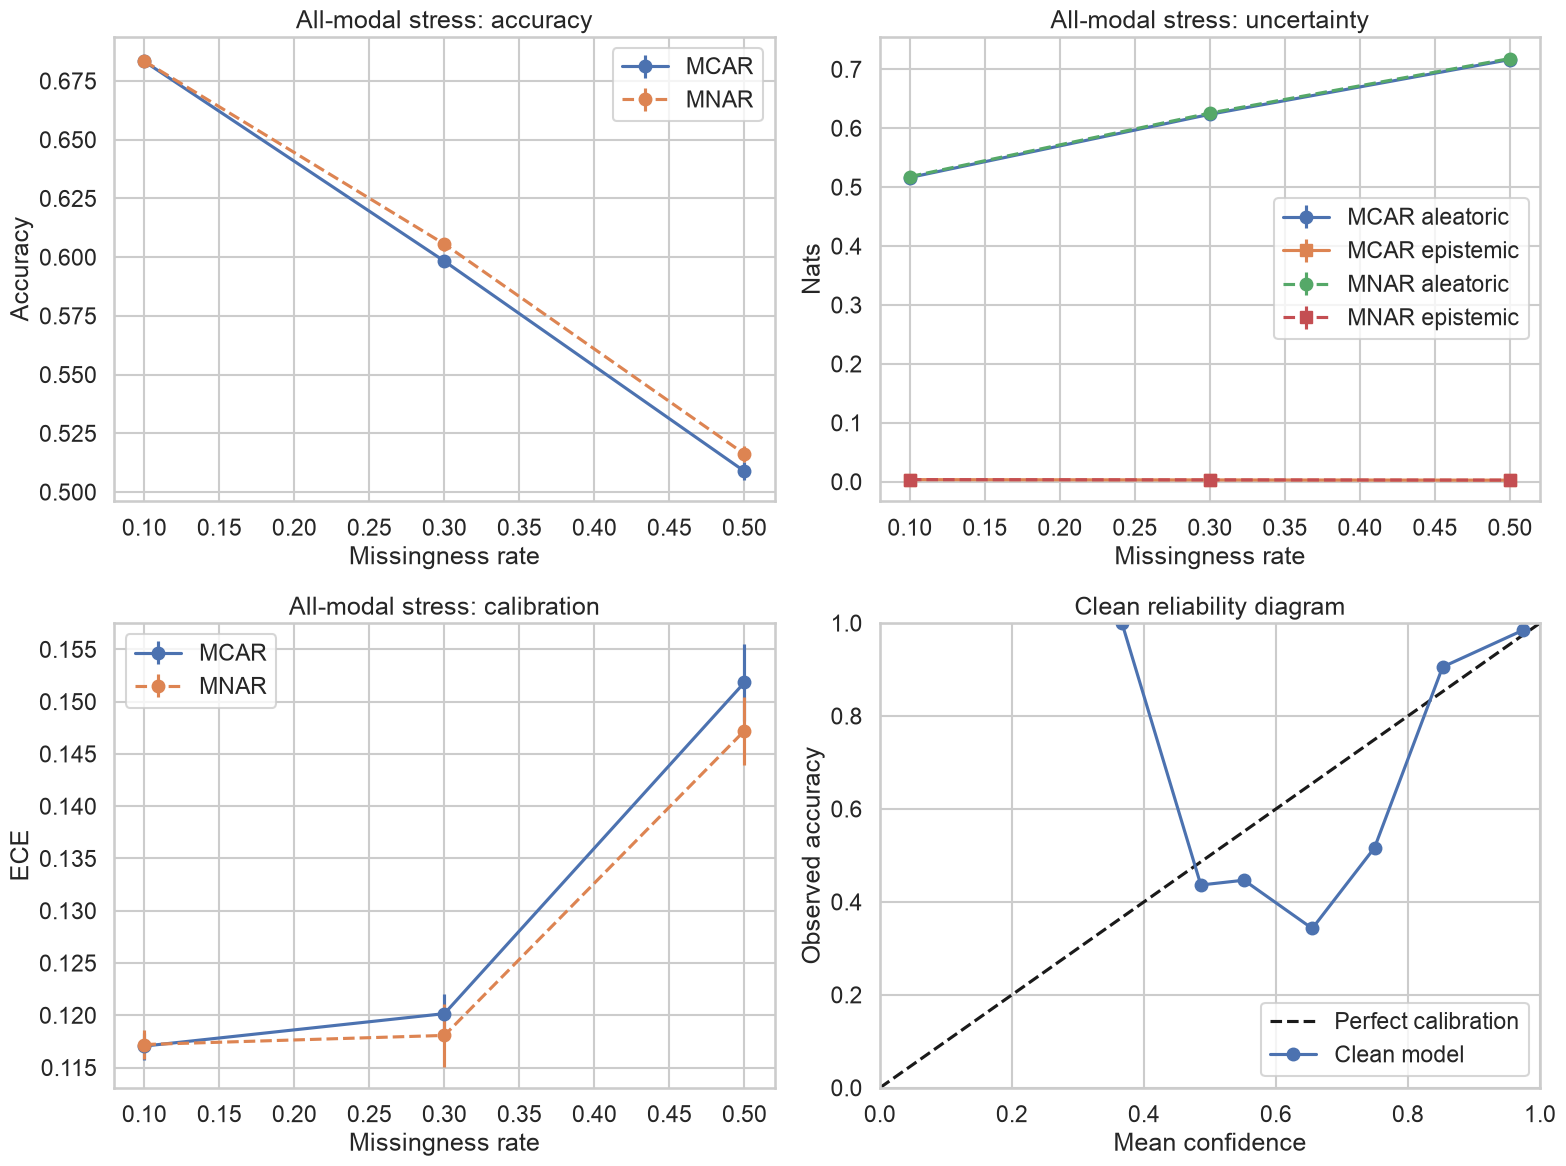

Saved figure: /Users/calebcooper/nuScenes/uq_results/object_classification/uq_core_results.png


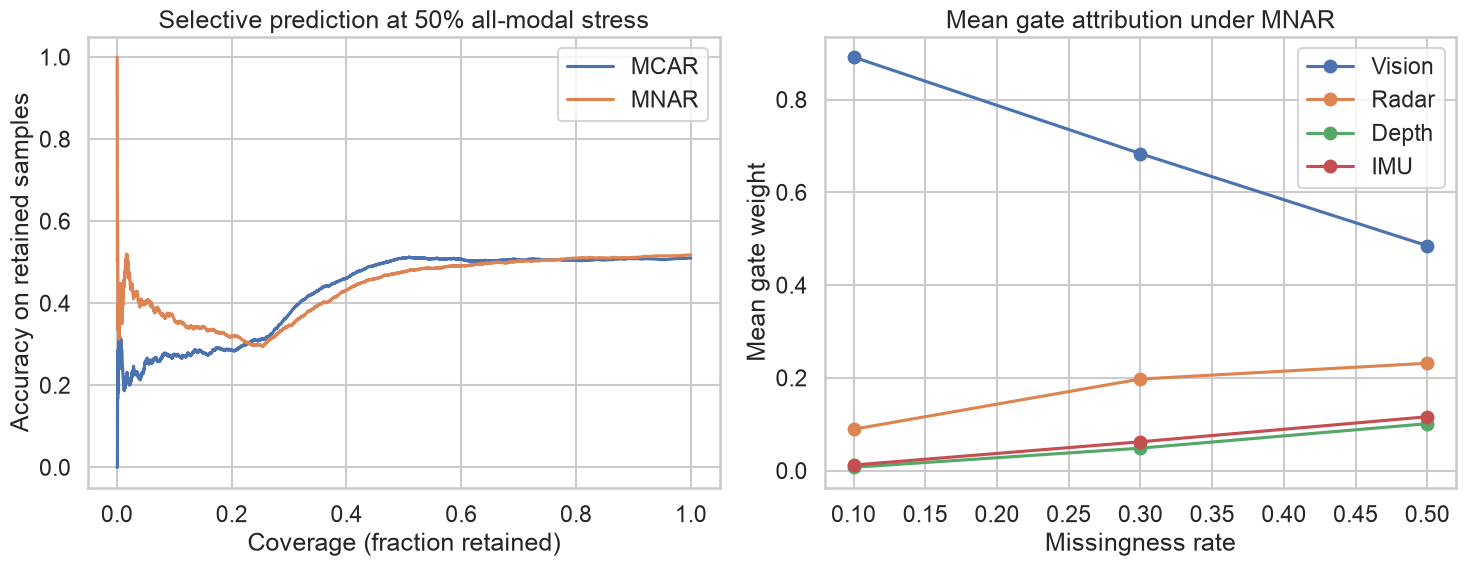

Saved figure: /Users/calebcooper/nuScenes/uq_results/object_classification/uq_selective_and_gate_results.png


In [124]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plot_results = results_df[results_df["mechanism"] != "Clean"].copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for mechanism, style in [("MCAR", "-"), ("MNAR", "--")]:
    subset = plot_results[(plot_results["condition"] == "all_modalities") & (plot_results["mechanism"] == mechanism)]
    axes[0, 0].errorbar(subset["rate"], subset["accuracy"], yerr=subset["accuracy_ci95"], marker="o", linestyle=style, label=mechanism)
    axes[0, 1].errorbar(subset["rate"], subset["aleatoric_uncertainty"], yerr=subset["aleatoric_uncertainty_ci95"], marker="o", linestyle=style, label=f"{mechanism} aleatoric")
    axes[0, 1].errorbar(subset["rate"], subset["epistemic_uncertainty"], yerr=subset["epistemic_uncertainty_ci95"], marker="s", linestyle=style, label=f"{mechanism} epistemic")
    axes[1, 0].errorbar(subset["rate"], subset["ece"], yerr=subset["ece_ci95"], marker="o", linestyle=style, label=mechanism)

axes[0, 0].set(title="All-modal stress: accuracy", xlabel="Missingness rate", ylabel="Accuracy")
axes[0, 1].set(title="All-modal stress: uncertainty", xlabel="Missingness rate", ylabel="Nats")
axes[1, 0].set(title="All-modal stress: calibration", xlabel="Missingness rate", ylabel="ECE")
for axis in axes.flat[:3]:
    axis.legend()

probabilities = clean_result["details"]["mean_probabilities"]
labels_clean = clean_result["details"]["labels"]
confidence = probabilities.max(axis=1)
prediction = probabilities.argmax(axis=1)
edges = np.linspace(0, 1, 11)
centers, observed = [], []
for lower, upper in zip(edges[:-1], edges[1:]):
    members = (confidence > lower) & (confidence <= upper)
    if members.any():
        centers.append(confidence[members].mean())
        observed.append((prediction[members] == labels_clean[members]).mean())
axes[1, 1].plot([0, 1], [0, 1], "k--", label="Perfect calibration")
axes[1, 1].plot(centers, observed, "o-", label="Clean model")
axes[1, 1].set(
    title="Clean reliability diagram",
    xlabel="Mean confidence",
    ylabel="Observed accuracy",
    xlim=(0, 1),
    ylim=(0, 1))
axes[1, 1].legend()
plt.tight_layout()
figure_path = results_root / "uq_core_results.png"
plt.savefig(figure_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved figure:", figure_path)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for mechanism in ("MCAR", "MNAR"):
    detail_key = f"{mechanism}__all_modalities__0.5__0"
    details = condition_details[detail_key]
    coverage, risk = risk_coverage_curve(
        details["labels"],
        details["predictions"],
        details["epistemic_uncertainty"])
    axes[0].plot(coverage, 1 - risk, label=mechanism)
axes[0].set(
    title="Selective prediction at 50% all-modal stress",
    xlabel="Coverage (fraction retained)",
    ylabel="Accuracy on retained samples")
axes[0].legend()

gate_columns = ["vision_gate", "text_gate", "depth_gate", "imu_gate"]
gate_names = ["Vision", "Radar", "Depth", "IMU"]
gate_subset = plot_results[
    (plot_results["mechanism"] == "MNAR")
    & (plot_results["condition"] == "all_modalities")]
for column, name in zip(gate_columns, gate_names):
    axes[1].plot(gate_subset["rate"], gate_subset[column], marker="o", label=name)
axes[1].set(
    title="Mean gate attribution under MNAR",
    xlabel="Missingness rate",
    ylabel="Mean gate weight")
axes[1].legend()
plt.tight_layout()
diagnostic_path = results_root / "uq_selective_and_gate_results.png"
plt.savefig(diagnostic_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved figure:", diagnostic_path)

In [125]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

figure_root = Path(results_root)
figure_root.mkdir(parents=True, exist_ok=True)

def summarize_values(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return np.nan, np.nan
    mean = values.mean()
    if len(values) == 1:
        return mean, 0.0
    standard_error = values.std(ddof=1) / np.sqrt(len(values))
    return mean, 1.96 * standard_error

def create_all_sensor_summary(mechanism):
    mechanism_results = raw_results_df[(raw_results_df["mechanism"] == mechanism) & (raw_results_df["condition"] == "all_modalities")].copy()
    rows = []
    # Add the clean baseline as the 0% condition.
    clean_total = clean_result["total_uncertainty"]
    clean_aleatoric = clean_result["aleatoric_uncertainty"]
    clean_epistemic = clean_result["epistemic_uncertainty"]
    clean_share = (100 * clean_epistemic / clean_total if clean_total > 0 else 0.0)
    rows.append({
        "rate": 0.0,
        "macro_f1": clean_result["macro_f1"],
        "macro_f1_ci": 0.0,
        "aleatoric": clean_aleatoric,
        "aleatoric_ci": 0.0,
        "epistemic": clean_epistemic,
        "epistemic_ci": 0.0,
        "epistemic_share": clean_share,
        "epistemic_share_ci": 0.0})
    # Average the repeated masks at each missingness rate.
    for rate in [0.1, 0.3, 0.5]:
        rate_results = mechanism_results[mechanism_results["rate"] == rate].copy()
        share_values = (100 * rate_results["epistemic_uncertainty"] / rate_results["total_uncertainty"].clip(lower=1e-12))
        macro_f1, macro_f1_ci = summarize_values(rate_results["macro_f1"])
        aleatoric, aleatoric_ci = summarize_values(rate_results["aleatoric_uncertainty"])
        epistemic, epistemic_ci = summarize_values(rate_results["epistemic_uncertainty"])
        epistemic_share, epistemic_share_ci = (summarize_values(share_values))
        rows.append({
            "rate": rate,
            "macro_f1": macro_f1,
            "macro_f1_ci": macro_f1_ci,
            "aleatoric": aleatoric,
            "aleatoric_ci": aleatoric_ci,
            "epistemic": epistemic,
            "epistemic_ci": epistemic_ci,
            "epistemic_share": epistemic_share,
            "epistemic_share_ci": epistemic_share_ci})
    return pd.DataFrame(rows)

def create_auarc_summary(mechanism):
    clean_details = clean_result["details"]
    clean_auarc = calculate_auarc(
        clean_details["labels"],
        clean_details["predictions"],
        clean_details["epistemic_uncertainty"])
    rows = [{"rate": 0.0, "auarc": clean_auarc, "auarc_ci": 0.0}]
    mechanism_results = selective_raw_df[(selective_raw_df["mechanism"] == mechanism) & (selective_raw_df["condition"] == "all_modalities")].copy()

    for rate in [0.1, 0.3, 0.5]:
        values = mechanism_results.loc[mechanism_results["rate"] == rate, "auarc_epistemic"]
        auarc, auarc_ci = summarize_values(values)
        rows.append({"rate": rate, "auarc": auarc, "auarc_ci": auarc_ci})
    return pd.DataFrame(rows)

def format_missingness_axis(axis):
    axis.set_xticks([0.0, 0.1, 0.3, 0.5])
    axis.set_xticklabels(["0%", "10%", "30%", "50%"])
    axis.set_xlabel("All-modality missingness")

def save_figure(figure, output_folder, filename):
    output_path = output_folder / filename
    figure.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(figure)
    print("Saved:", output_path)

def create_uncertainty_figures(mechanism):
    summary = create_all_sensor_summary(mechanism)
    auarc_summary = create_auarc_summary(mechanism)
    output_folder = figure_root / mechanism
    output_folder.mkdir(parents=True, exist_ok=True)
    rates = summary["rate"].to_numpy()
    clean_aleatoric = summary.loc[summary["rate"] == 0, "aleatoric"].iloc[0]
    clean_auarc = auarc_summary.loc[auarc_summary["rate"] == 0, "auarc"].iloc[0]
    # Figure A: stacked uncertainty decomposition
    figure, axis = plt.subplots(figsize=(7, 5))
    aleatoric_bars = axis.bar(rates, summary["aleatoric"], width=0.06, color="#1f77b4", label="Aleatoric (data uncertainty)")
    epistemic_bars = axis.bar(rates, summary["epistemic"], width=0.06, bottom=summary["aleatoric"], color="#ff7f0e", label="Epistemic (model uncertainty)")
    axis.set_title(f"(a) Predictive uncertainty decomposition: {mechanism}")
    axis.set_ylabel("Predictive uncertainty (nats)")
    format_missingness_axis(axis)
    axis.grid(axis="y", alpha=0.3)
    axis.legend(loc="upper left")
    figure.tight_layout()
    save_figure(figure, output_folder, f"predictive_uncertainty_decomposition_{mechanism.lower()}.png")
    # Figure A2: epistemic uncertainty on its own scale
    figure, axis = plt.subplots(figsize=(7, 5))
    axis.bar(rates, summary["epistemic"], width=0.06, yerr=summary["epistemic_ci"], color="#ff7f0e")
    axis.set_title(f"(a2) Epistemic uncertainty: {mechanism}")
    axis.set_ylabel("Epistemic uncertainty (BALD, nats)")
    format_missingness_axis(axis)
    axis.grid(axis="y", alpha=0.3)
    figure.tight_layout()
    save_figure(figure, output_folder, f"epistemic_uncertainty_{mechanism.lower()}.png")
    # Figure B: Epistemic share of total uncertainty
    figure, axis = plt.subplots(
        figsize=(7, 5))
    axis.errorbar(rates, summary["epistemic_share"], yerr=summary["epistemic_share_ci"], color="#1f77b4", marker="o", linewidth=2, capsize=4)
    axis.fill_between(
        rates,
        0,
        summary["epistemic_share"],
        color="#d62728",
        alpha=0.15)
    axis.set_title(f"(b) Epistemic share of total uncertainty: {mechanism}")
    axis.set_ylabel("Epistemic / total (%)")
    format_missingness_axis(axis)
    axis.grid(alpha=0.3)
    figure.tight_layout()
    save_figure(figure, output_folder, f"epistemic_share_{mechanism.lower()}.png")
    # Figure C: Macro F1 and epistemic uncertainty
    figure, left_axis = plt.subplots(figsize=(7, 5))
    right_axis = left_axis.twinx()
    left_line = left_axis.errorbar(rates, summary["macro_f1"], yerr=summary["macro_f1_ci"], color="#1f77b4", marker="o", linewidth=2, capsize=4, label="Macro F1")
    right_line = right_axis.errorbar(rates, summary["epistemic"], yerr=summary["epistemic_ci"], color="#d62728", marker="s", linestyle="--", linewidth=2, capsize=4, label="Epistemic")
    left_axis.set_title(f"(c) Macro F1 and epistemic uncertainty: {mechanism}")
    left_axis.set_ylabel("Macro F1", color="#1f77b4")
    right_axis.set_ylabel("Epistemic uncertainty (BALD, nats)", color="#d62728")
    left_axis.tick_params(axis="y", labelcolor="#1f77b4")
    right_axis.tick_params(axis="y", labelcolor="#d62728")
    format_missingness_axis(left_axis)
    left_axis.grid(alpha=0.3)
    lines = [left_line, right_line]
    labels_for_legend = ["Macro F1", "Epistemic"]
    left_axis.legend(lines, labels_for_legend, loc="lower left")
    figure.tight_layout()
    save_figure(figure, output_folder, f"macro_f1_and_epistemic_{mechanism.lower()}.png")
    # Figure D: Aleatoric uncertainty
    figure, axis = plt.subplots(figsize=(7, 5))
    axis.errorbar(rates, summary["aleatoric"], yerr=summary["aleatoric_ci"], color="#1f77b4", marker="o", linewidth=2, capsize=4)
    axis.axhline(clean_aleatoric, color="gray", linestyle=":", label="Clean baseline")
    axis.set_title(f"(d) Aleatoric uncertainty: {mechanism}")
    axis.set_ylabel("Aleatoric uncertainty (nats)")
    format_missingness_axis(axis)
    axis.legend()
    axis.grid(alpha=0.3)
    figure.tight_layout()
    save_figure(figure, output_folder, f"aleatoric_uncertainty_{mechanism.lower()}.png")
    # Figure E: AUARC
    figure, axis = plt.subplots(figsize=(7, 5))
    axis.errorbar(auarc_summary["rate"], auarc_summary["auarc"], yerr=auarc_summary["auarc_ci"], color="#2ca02c", marker="o", linewidth=2, capsize=4)
    axis.axhline(clean_auarc, color="gray", linestyle=":", label="Clean baseline")

    axis.set_title(f"(e) AUARC using epistemic uncertainty (BALD): {mechanism}")
    axis.set_ylabel("AUARC")

    format_missingness_axis(axis)
    axis.legend()
    axis.grid(alpha=0.3)

    figure.tight_layout()
    save_figure(figure, output_folder, f"auarc_epistemic_{mechanism.lower()}.png")
    print(f"\nFinished all {mechanism} figures.")
    display(summary.round(5))
    display(auarc_summary.round(5))

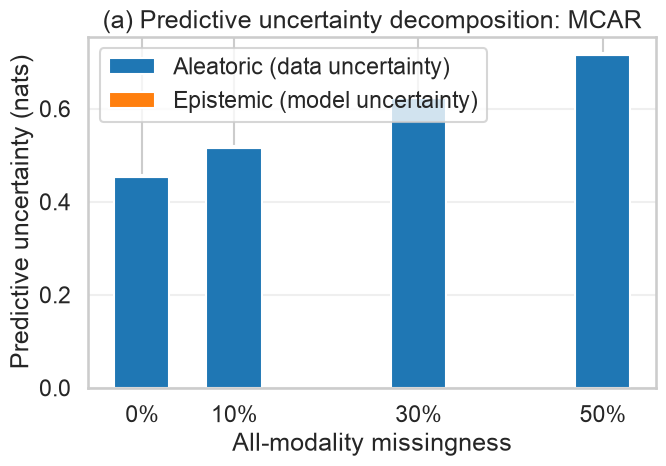

Saved: /Users/calebcooper/nuScenes/uq_results/object_classification/MCAR/predictive_uncertainty_decomposition_mcar.png


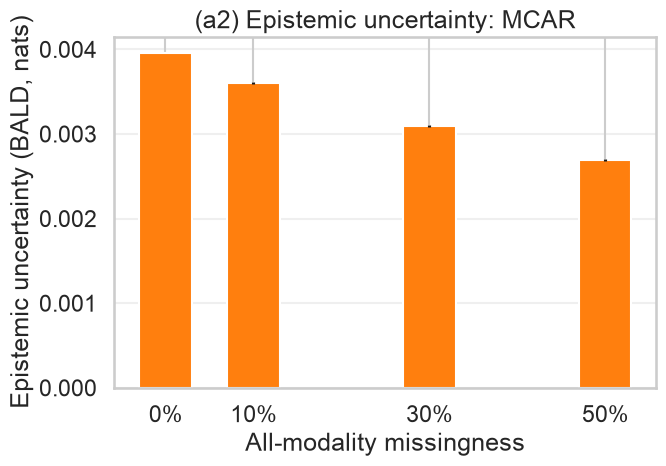

Saved: /Users/calebcooper/nuScenes/uq_results/object_classification/MCAR/epistemic_uncertainty_mcar.png


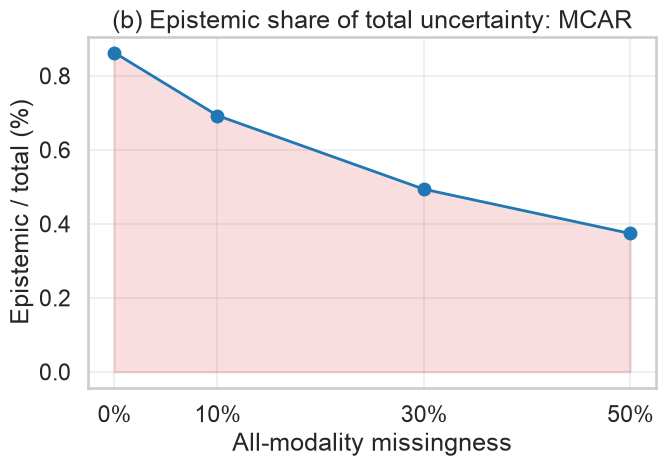

Saved: /Users/calebcooper/nuScenes/uq_results/object_classification/MCAR/epistemic_share_mcar.png


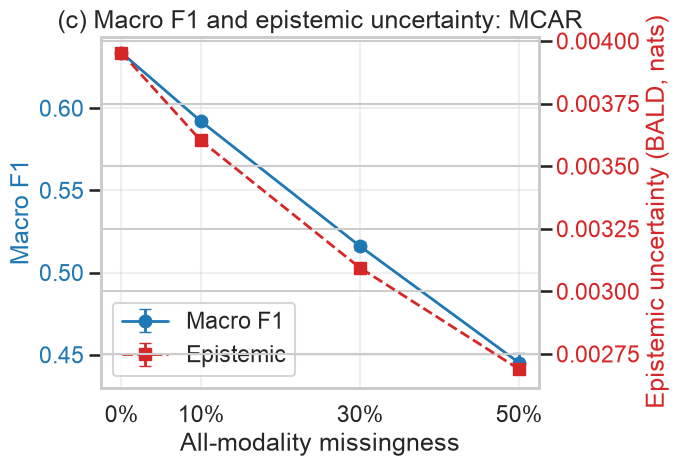

Saved: /Users/calebcooper/nuScenes/uq_results/object_classification/MCAR/macro_f1_and_epistemic_mcar.png


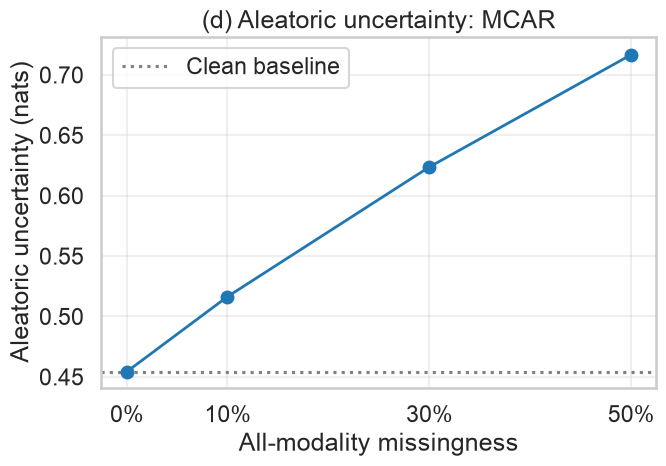

Saved: /Users/calebcooper/nuScenes/uq_results/object_classification/MCAR/aleatoric_uncertainty_mcar.png


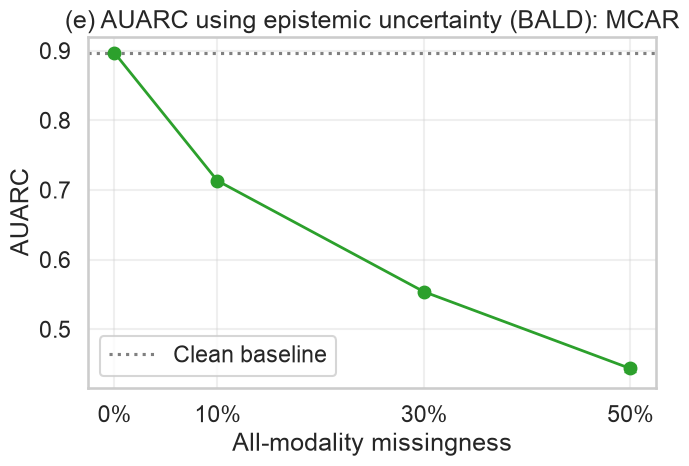

Saved: /Users/calebcooper/nuScenes/uq_results/object_classification/MCAR/auarc_epistemic_mcar.png

Finished all MCAR figures.


,rate,macro_f1,macro_f1_ci,aleatoric,aleatoric_ci,epistemic,epistemic_ci,epistemic_share,epistemic_share_ci
0,0.0,0.63384,0.00000,0.45416,0.00000,0.00395,0.00000,0.86306,0.00000
1,0.1,0.59208,0.00163,0.51639,0.00083,0.00360,0.00001,0.69279,0.00183
2,0.3,0.51615,0.00258,0.62366,0.00176,0.00309,0.00001,0.49373,0.00112
3,0.5,0.44529,0.00565,0.71658,0.00199,0.00269,0.00001,0.37396,0.00173


,rate,auarc,auarc_ci
0,0.0,0.89736,0.00000
1,0.1,0.71326,0.00302
2,0.3,0.55394,0.00404
3,0.5,0.44365,0.00482


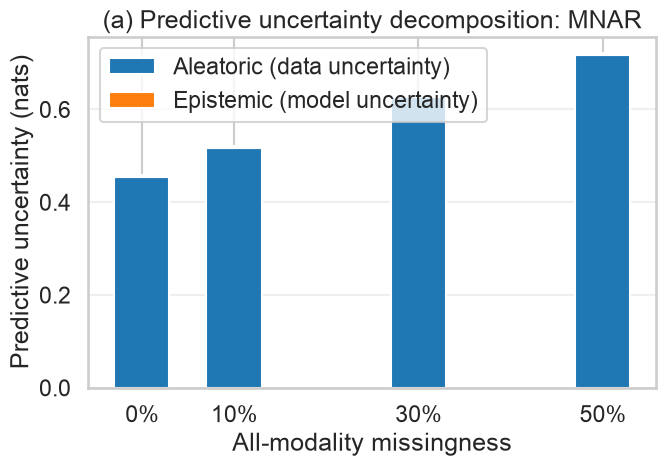

Saved: /Users/calebcooper/nuScenes/uq_results/object_classification/MNAR/predictive_uncertainty_decomposition_mnar.png


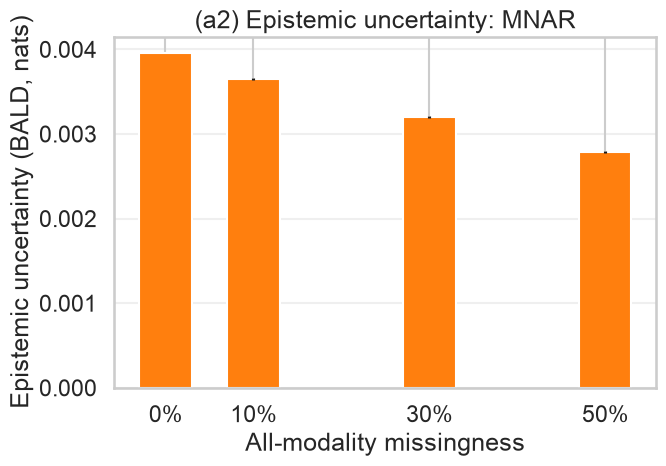

Saved: /Users/calebcooper/nuScenes/uq_results/object_classification/MNAR/epistemic_uncertainty_mnar.png


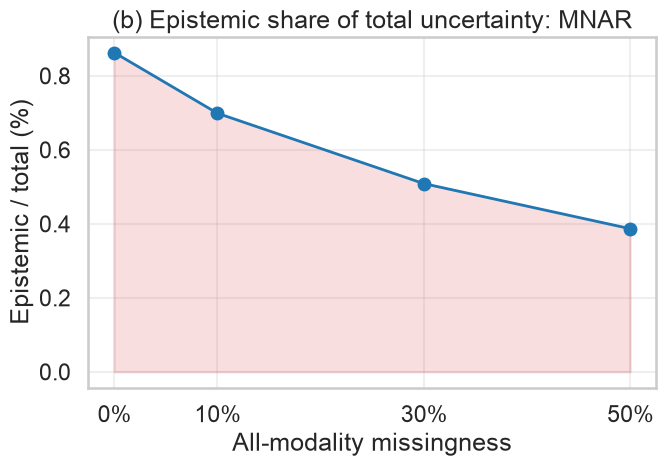

Saved: /Users/calebcooper/nuScenes/uq_results/object_classification/MNAR/epistemic_share_mnar.png


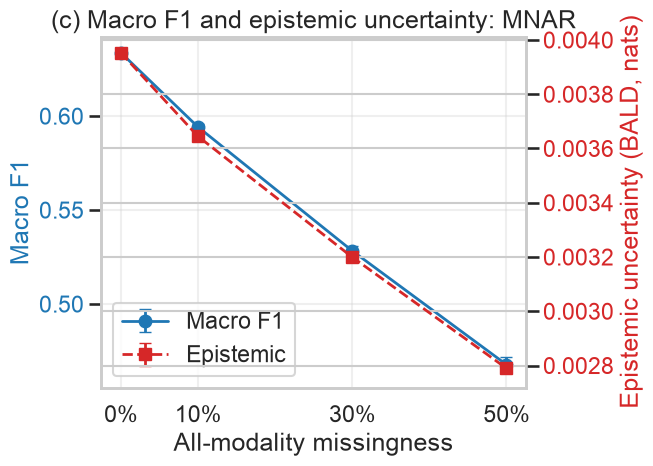

Saved: /Users/calebcooper/nuScenes/uq_results/object_classification/MNAR/macro_f1_and_epistemic_mnar.png


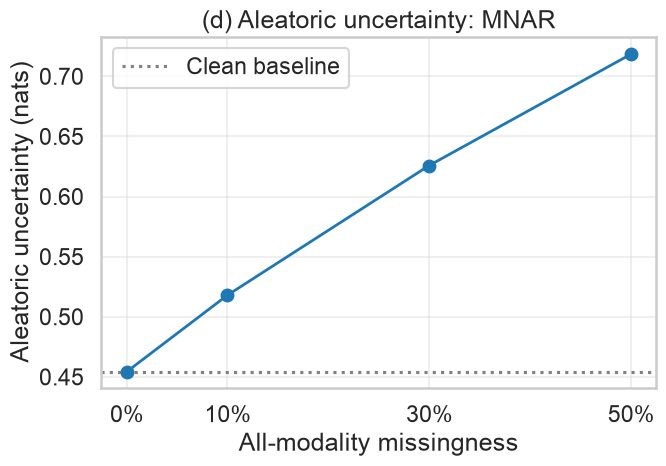

Saved: /Users/calebcooper/nuScenes/uq_results/object_classification/MNAR/aleatoric_uncertainty_mnar.png


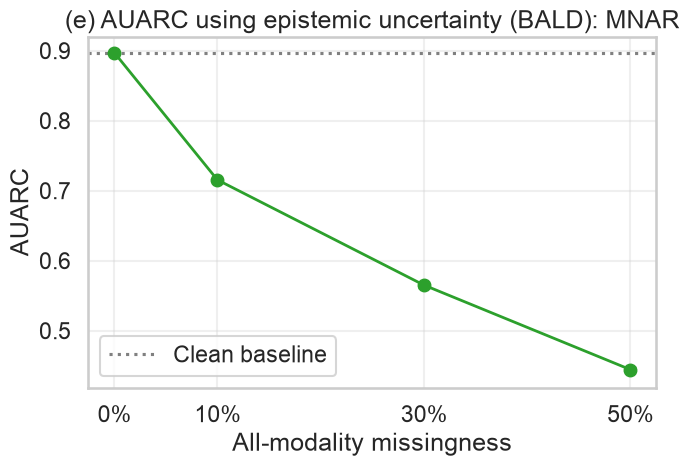

Saved: /Users/calebcooper/nuScenes/uq_results/object_classification/MNAR/auarc_epistemic_mnar.png

Finished all MNAR figures.


,rate,macro_f1,macro_f1_ci,aleatoric,aleatoric_ci,epistemic,epistemic_ci,epistemic_share,epistemic_share_ci
0,0.0,0.63384,0.00000,0.45416,0.00000,0.00395,0.00000,0.86306,0.00000
1,0.1,0.59431,0.00170,0.51793,0.00066,0.00365,0.00001,0.69892,0.00165
2,0.3,0.52837,0.00278,0.62577,0.00157,0.00320,0.00002,0.50875,0.00198
3,0.5,0.46783,0.00389,0.71833,0.00145,0.00279,0.00001,0.38689,0.00176


,rate,auarc,auarc_ci
0,0.0,0.89736,0.00000
1,0.1,0.71545,0.00332
2,0.3,0.56522,0.00359
3,0.5,0.44449,0.00327


In [126]:
create_uncertainty_figures("MCAR")
create_uncertainty_figures("MNAR")

/var/folders/_j/y35nsxln38dd8dc1trg4qtnc0000gq/T/ipykernel_78656/1128939803.py:49: UserWarning: The figure layout has changed to tight
  figure.tight_layout()


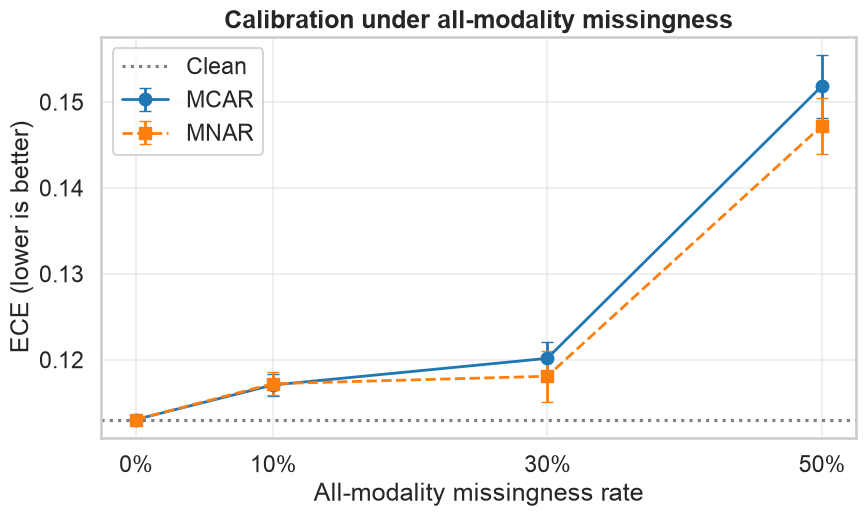

Saved: /Users/calebcooper/nuScenes/uq_results/object_classification/diagnostic_figures/calibration_all_modality_missingness.png


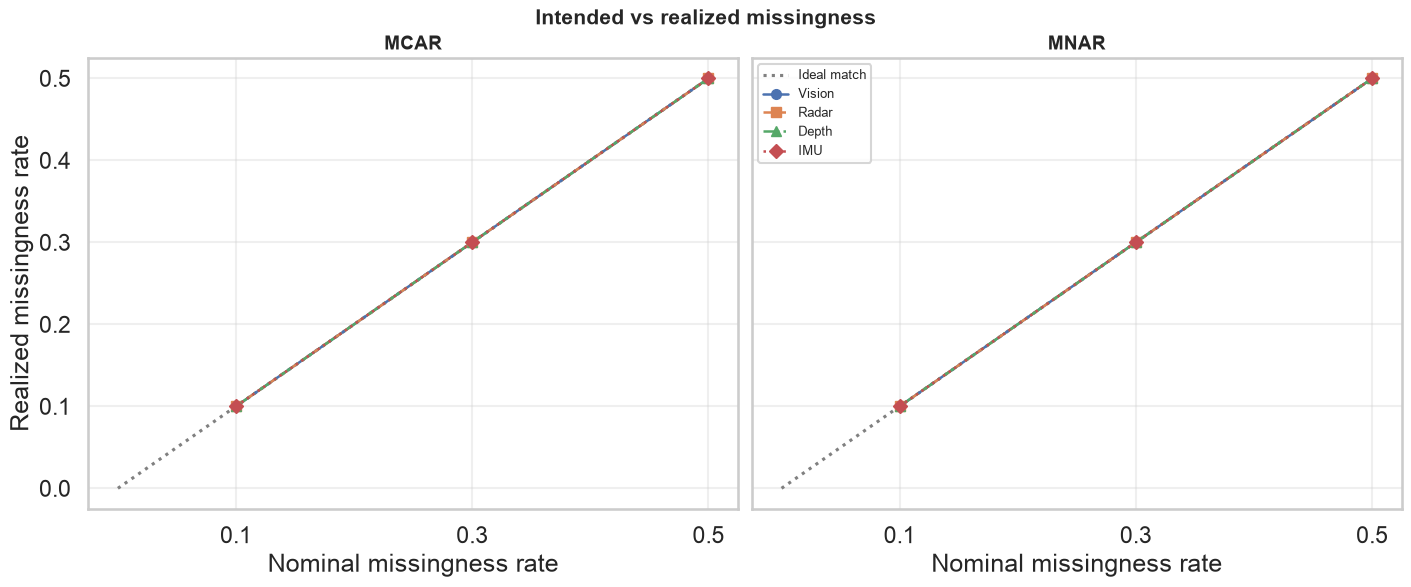

Saved: /Users/calebcooper/nuScenes/uq_results/object_classification/diagnostic_figures/intended_vs_realized_missingness.png


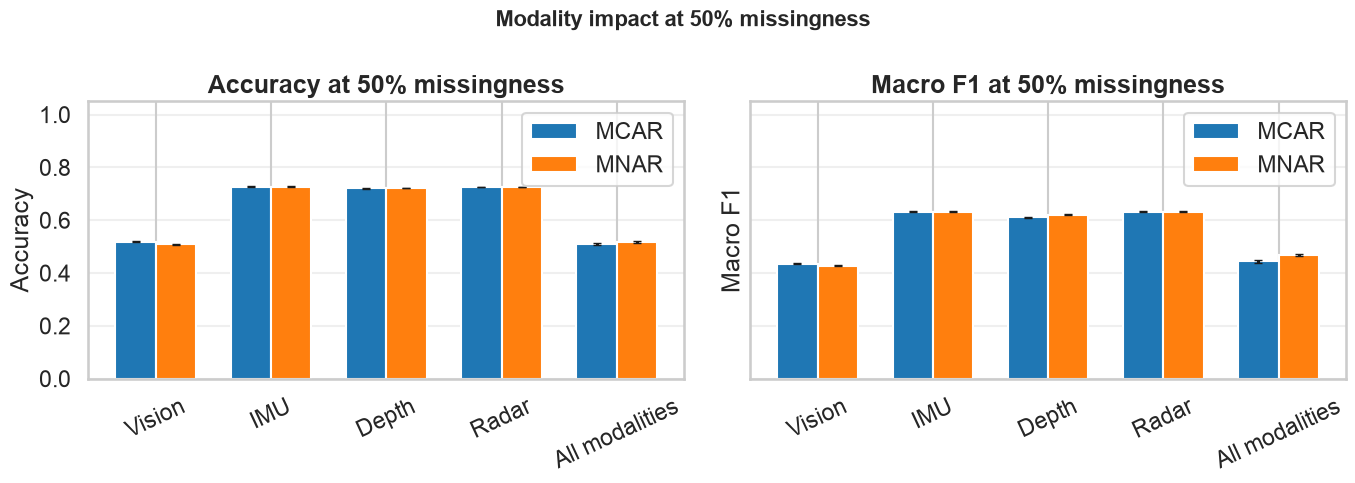

Saved: /Users/calebcooper/nuScenes/uq_results/object_classification/diagnostic_figures/modality_impact_at_50pct.png


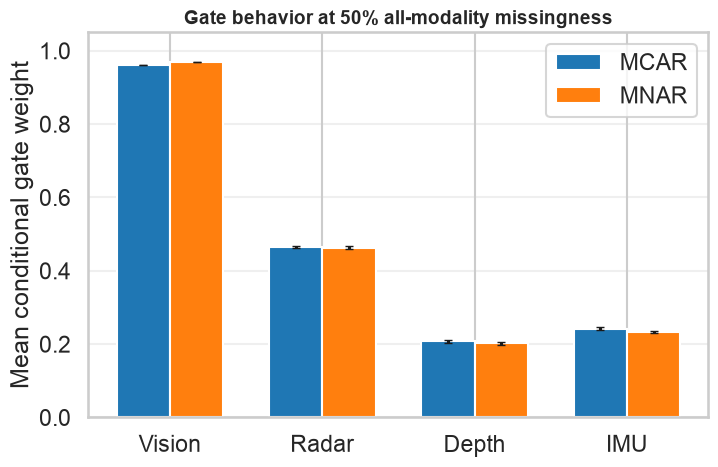

Saved: /Users/calebcooper/nuScenes/uq_results/object_classification/diagnostic_figures/gate_behavior_at_50pct.png


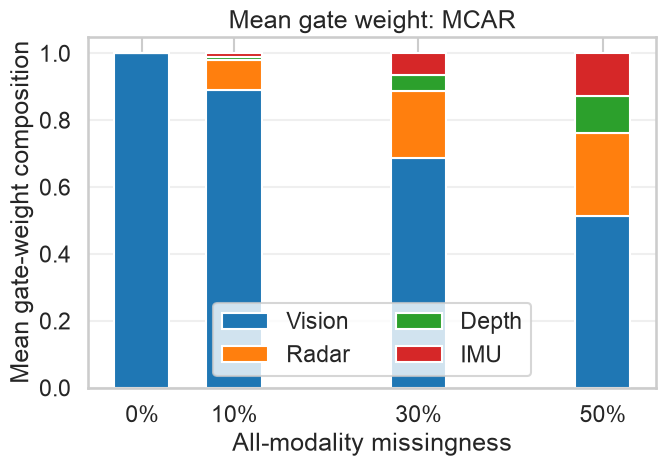

Saved: /Users/calebcooper/nuScenes/uq_results/object_classification/diagnostic_figures/mean_gate_weight_mcar.png


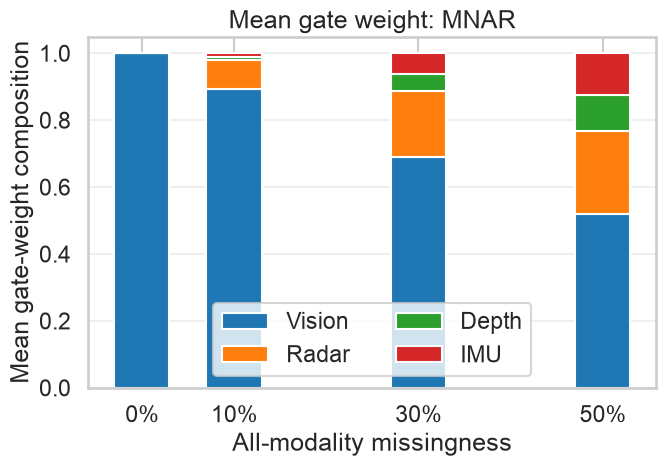

Saved: /Users/calebcooper/nuScenes/uq_results/object_classification/diagnostic_figures/mean_gate_weight_mnar.png


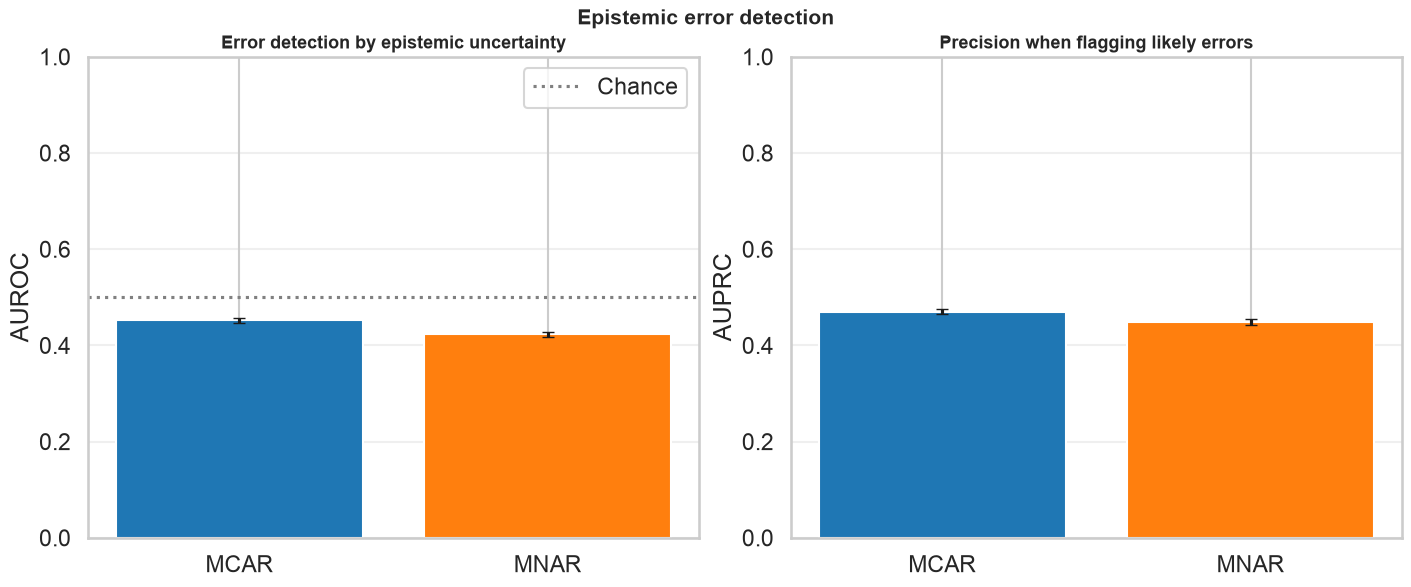

Saved: /Users/calebcooper/nuScenes/uq_results/object_classification/diagnostic_figures/epistemic_error_recognition.png


,mechanism,AUROC,AUPRC,error_rate
0,MCAR,0.4523,0.4702,0.4912
1,MNAR,0.4230,0.4486,0.4838


In [127]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import roc_auc_score, average_precision_score

diagnostic_root = Path(results_root) / "diagnostic_figures"
diagnostic_root.mkdir(parents=True, exist_ok=True)

modalities = ["vision", "radar", "depth", "imu"]
display_names = ["Vision", "Radar", "Depth", "IMU"]
rates = [0.0, 0.1, 0.3, 0.5]

def save_diagnostic_figure(figure, filename):
    path = diagnostic_root / filename
    figure.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(figure)
    print("Saved:", path)

def all_modality_rows(mechanism, rate):
    return raw_results_df[(raw_results_df["mechanism"] == mechanism) & (raw_results_df["condition"] == "all_modalities") & np.isclose(raw_results_df["rate"], rate)].copy()

def create_calibration_figure():
    clean_ece = clean_result["ece"]
    figure, axis = plt.subplots(figsize=(9, 5.5), constrained_layout=True)

    for mechanism, color, marker, linestyle in [
        ("MCAR", "#1f77b4", "o", "-"),
        ("MNAR", "#ff7f0e", "s", "--")]:
        means = [clean_ece]
        intervals = [0.0]

        for rate in rates[1:]:
            mean, interval = summarize_values(all_modality_rows(mechanism, rate)["ece"])
            means.append(mean)
            intervals.append(interval)

        axis.errorbar(rates, means, yerr=intervals, color=color, marker=marker, linestyle=linestyle, linewidth=2, capsize=4, label=mechanism)

    axis.axhline(clean_ece, color="gray", linestyle=":", label="Clean")
    axis.set_title("Calibration under all-modality missingness", fontweight="bold")
    axis.set_xlabel("All-modality missingness rate")
    axis.set_ylabel("ECE (lower is better)")
    axis.set_xticks(rates)
    axis.set_xticklabels(["0%", "10%", "30%", "50%"])
    axis.grid(alpha=0.3)
    axis.legend()
    figure.tight_layout()
    save_diagnostic_figure(figure, "calibration_all_modality_missingness.png")

def create_missingness_validation_figure():
    figure, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharex=True, sharey=True, constrained_layout=True)
    figure.suptitle("Intended vs realized missingness", fontsize=15, fontweight="bold", y=1.04)
    for axis, mechanism in zip(axes, ["MCAR", "MNAR"]):
        axis.plot([0, 0.5], [0, 0.5], color="gray", linestyle=":", label="Ideal match")

        line_styles = ["-", "--", "-.", ":"]
        markers = ["o", "s", "^", "D"]

        for modality_index, (modality, display_name) in enumerate(zip(modalities, display_names)):
            means = []
            for rate in rates[1:]:
                rows = all_modality_rows(mechanism, rate)
                means.append(
                    rows[f"actual_{modality}_missing"].mean())
            axis.plot(rates[1:], means, marker=markers[modality_index], linestyle=line_styles[modality_index], linewidth=1.8, markersize=7, label=display_name)
        axis.set_title(mechanism, fontsize=14, fontweight="bold")
        axis.set_xlabel("Nominal missingness rate")
        axis.set_xticks([0.1, 0.3, 0.5])
        axis.grid(alpha=0.3)

    axes[0].set_ylabel("Realized missingness rate")
    axes[1].legend(loc="upper left", fontsize=9)
    save_diagnostic_figure(figure, "intended_vs_realized_missingness.png")

def create_modality_impact_figure():
    conditions = ["vision", "imu", "depth", "radar", "all_modalities"]
    labels = ["Vision", "IMU", "Depth", "Radar", "All modalities"]

    x_positions = np.arange(len(conditions))
    bar_width = 0.35
    figure, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    figure.suptitle("Modality impact at 50% missingness", fontsize=16, fontweight="bold")

    for axis, metric, title in [
        (axes[0], "accuracy", "Accuracy at 50% missingness"),
        (axes[1], "macro_f1", "Macro F1 at 50% missingness")]:
        for offset, mechanism, color in [
            (-bar_width / 2, "MCAR", "#1f77b4"),
            (bar_width / 2, "MNAR", "#ff7f0e")]:
            means = []
            intervals = []

            for condition in conditions:
                values = raw_results_df.loc[
                    (raw_results_df["mechanism"] == mechanism)
                    & (raw_results_df["condition"] == condition)
                    & np.isclose(raw_results_df["rate"], 0.5),
                    metric]
                mean, interval = summarize_values(values)
                means.append(mean)
                intervals.append(interval)

            axis.bar(x_positions + offset, means, width=bar_width, yerr=intervals, color=color, capsize=3, label=mechanism)
        axis.set_title(title, fontweight="bold")
        axis.set_xticks(x_positions)
        axis.set_xticklabels(labels, rotation=25)
        axis.set_ylabel(metric.replace("_", " ").title())
        axis.set_ylim(0, 1.05)
        axis.grid(axis="y", alpha=0.3)
        axis.legend()
    figure.tight_layout()
    save_diagnostic_figure(figure,"modality_impact_at_50pct.png")

def conditional_gate_weights(mechanism, rate):
    repeat_weights = []
    if rate == 0:
      gates = clean_result["details"]["gate_weights"]
      repeat_weights.append(gates.mean(axis=0))
    else:
        for item in mask_sets:
            if (item["mechanism"] == mechanism and item["condition"] == "all_modalities" and np.isclose(item["rate"], rate)):
                key = (f"{mechanism}__all_modalities__" f"{rate}__{item['repeat']}")
                gates = condition_details[key]["gate_weights"]
                mask = item["mask"]
                one_repeat = []

                for modality_index in range(4):
                    present = mask[:, modality_index] == 1

                    if present.any(): one_repeat.append(gates[present, modality_index].mean())
                    else:
                        one_repeat.append(np.nan)
                repeat_weights.append(one_repeat)
    repeat_weights = np.asarray(repeat_weights, dtype=float)
    means = np.nanmean(repeat_weights, axis=0)

    if len(repeat_weights) > 1:
        intervals = (1.96 * np.nanstd(repeat_weights, axis=0, ddof=1) / np.sqrt(len(repeat_weights)))
    else:
        intervals = np.zeros(4)
    return means, intervals

def create_gate_behavior_figure():
    x_positions = np.arange(4)
    bar_width = 0.35
    figure, axis = plt.subplots(figsize=(8, 5))

    for offset, mechanism, color in [(-bar_width / 2, "MCAR", "#1f77b4"), (bar_width / 2, "MNAR", "#ff7f0e")]:
        means, intervals = conditional_gate_weights(mechanism, 0.5)
        axis.bar(x_positions + offset, means, width=bar_width, yerr=intervals, color=color, capsize=3, label=mechanism)
    axis.set_title("Gate behavior at 50% all-modality missingness", fontsize=14, fontweight="bold")
    axis.set_ylabel("Mean conditional gate weight")
    axis.set_xticks(x_positions)
    axis.set_xticklabels(display_names)
    axis.set_ylim(0, 1.05)
    axis.grid(axis="y", alpha=0.3)
    axis.legend()
    save_diagnostic_figure(figure, "gate_behavior_at_50pct.png")

def create_mean_gate_weight_figures():
    colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
    for mechanism in ["MCAR", "MNAR"]:
        gate_means = []
        for rate in rates:
            if rate == 0:
                gates = clean_result["details"]["gate_weights"]
                nonempty = np.ones(len(gates), dtype=bool)
                repeat_compositions = [gates[nonempty].mean(axis=0)]
            else:
                repeat_compositions = []

                for item in mask_sets:
                    if (item["mechanism"] == mechanism and item["condition"] == "all_modalities" and np.isclose(item["rate"], rate)):
                        key = (f"{mechanism}__all_modalities__" f"{rate}__{item['repeat']}")
                        details = condition_details[key]
                        gates = details["gate_weights"]
                        mask = details["presence_mask"]
                        nonempty = mask.sum(axis=1) > 0
                        repeat_compositions.append(
                            gates[nonempty].mean(axis=0))

            gate_means.append(np.mean(repeat_compositions, axis=0))
        gate_means = np.asarray(gate_means)
        figure, axis = plt.subplots(figsize=(7, 5))
        bottom = np.zeros(len(rates))

        for modality_index, (display_name, color) in enumerate(zip(display_names, colors)):
            axis.bar(
                rates,
                gate_means[:, modality_index],
                width=0.06,
                bottom=bottom,
                color=color,
                label=display_name)
            bottom += gate_means[:, modality_index]

        axis.set_title(f"Mean gate weight: {mechanism}")
        axis.set_xlabel("All-modality missingness")
        axis.set_ylabel("Mean gate-weight composition")
        axis.set_xticks(rates)
        axis.set_xticklabels(["0%", "10%", "30%", "50%"])
        axis.set_ylim(0, 1.05)
        axis.grid(axis="y", alpha=0.3)
        axis.legend(loc="lower center", ncol=2)
        figure.tight_layout()
        save_diagnostic_figure(figure, f"mean_gate_weight_{mechanism.lower()}.png")

def error_detection_scores(mechanism):
    auroc_values = []
    auprc_values = []
    error_rates = []

    for item in mask_sets:
        if (item["mechanism"] == mechanism and item["condition"] == "all_modalities" and np.isclose(item["rate"], 0.5)):
            key = (f"{mechanism}__all_modalities__" f"0.5__{item['repeat']}")
            details = condition_details[key]
            errors = (details["predictions"] != details["labels"]).astype(int)
            uncertainty = details["epistemic_uncertainty"]
            error_rates.append(errors.mean())

            if len(np.unique(errors)) == 2: auroc_values.append(roc_auc_score(errors, uncertainty))
            auprc_values.append(average_precision_score(errors, uncertainty))
    return {"auroc": summarize_values(auroc_values), "auprc": summarize_values(auprc_values), "error_rate": np.mean(error_rates)}

def create_error_recognition_figure():
    scores = {mechanism: error_detection_scores(mechanism) for mechanism in ["MCAR", "MNAR"]}
    x_positions = np.arange(2)
    colors = ["#1f77b4", "#ff7f0e"]
    figure, axes = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)
    figure.suptitle("Epistemic error detection", fontsize=15, fontweight="bold", y=1.04)
    auroc_means = [scores["MCAR"]["auroc"][0], scores["MNAR"]["auroc"][0]]
    auroc_intervals = [scores["MCAR"]["auroc"][1], scores["MNAR"]["auroc"][1]]
    axes[0].bar(x_positions, auroc_means, yerr=auroc_intervals, color=colors, capsize=4)
    axes[0].axhline(0.5, color="gray", linestyle=":", label="Chance")
    axes[0].set_title("Error detection by epistemic uncertainty", fontsize=13, fontweight="bold")
    axes[0].set_ylabel("AUROC")
    axes[0].set_xticks(x_positions)
    axes[0].set_xticklabels(["MCAR", "MNAR"])
    axes[0].set_ylim(0, 1)
    axes[0].grid(axis="y", alpha=0.3)
    axes[0].legend()

    auprc_means = [scores["MCAR"]["auprc"][0], scores["MNAR"]["auprc"][0]]
    auprc_intervals = [scores["MCAR"]["auprc"][1], scores["MNAR"]["auprc"][1]]
    axes[1].bar(x_positions, auprc_means, yerr=auprc_intervals, color=colors, capsize=4)
    axes[1].set_title("Precision when flagging likely errors", fontsize=13, fontweight="bold")
    axes[1].set_ylabel("AUPRC")
    axes[1].set_xticks(x_positions)
    axes[1].set_xticklabels(["MCAR", "MNAR"])
    axes[1].set_ylim(0, 1)
    axes[1].grid(axis="y", alpha=0.3)

    save_diagnostic_figure(figure, "epistemic_error_recognition.png")

    display(pd.DataFrame({
            "mechanism": ["MCAR", "MNAR"],
            "AUROC": auroc_means,
            "AUPRC": auprc_means,
            "error_rate": [scores["MCAR"]["error_rate"], scores["MNAR"]["error_rate"]]}).round(4))

create_calibration_figure()
create_missingness_validation_figure()
create_modality_impact_figure()
create_gate_behavior_figure()
create_mean_gate_weight_figures()
create_error_recognition_figure()

In [128]:
print("\nClean mean gate weights")
for name, value in zip(["Vision", "Radar", "Depth", "IMU"], clean_result["details"]["gate_weights"].mean(axis=0)):
    print(f"{name:6s}: {value:.6f}")


Clean mean gate weights
Vision: 0.999350
Radar : 0.000619
Depth : 0.000019
IMU   : 0.000013


In [129]:
for mechanism in ["MCAR", "MNAR"]:
    means, intervals = conditional_gate_weights(mechanism, 0.5)

    print(f"\n{mechanism}: gate weight when each modality is present")

    for name, mean, interval in zip(display_names, means, intervals):
        print(f"{name:6s}: " f"{mean:.6f} ± {interval:.6f}")


MCAR: gate weight when each modality is present
Vision: 0.960679 ± 0.000745
Radar : 0.465125 ± 0.003796
Depth : 0.207427 ± 0.003415
IMU   : 0.241479 ± 0.004196

MNAR: gate weight when each modality is present
Vision: 0.969220 ± 0.000807
Radar : 0.462763 ± 0.004657
Depth : 0.202236 ± 0.004242
IMU   : 0.232189 ± 0.002317


In [130]:
print("Final result files")
for path in sorted(results_root.rglob("*")):
    if path.is_file():
        print("-", path.relative_to(results_root))

Final result files
- MCAR/aleatoric_uncertainty_mcar.png
- MCAR/auarc_epistemic_mcar.png
- MCAR/epistemic_share_mcar.png
- MCAR/epistemic_uncertainty_mcar.png
- MCAR/macro_f1_and_epistemic_mcar.png
- MCAR/predictive_uncertainty_decomposition_mcar.png
- MNAR/aleatoric_uncertainty_mnar.png
- MNAR/auarc_epistemic_mnar.png
- MNAR/epistemic_share_mnar.png
- MNAR/epistemic_uncertainty_mnar.png
- MNAR/macro_f1_and_epistemic_mnar.png
- MNAR/predictive_uncertainty_decomposition_mnar.png
- best_fusion_model.pt
- best_fusion_model_fedprox_mu_0.01.pt
- best_fusion_model_fedprox_mu_0.1.pt
- conclusive_multiseed/fusion_model_fedprox_mu_0.01_seed_42.pt
- conclusive_multiseed/fusion_model_fedprox_mu_0.01_seed_43.pt
- conclusive_multiseed/fusion_model_fedprox_mu_0.01_seed_44.pt
- conclusive_multiseed/fusion_model_fedprox_mu_0.01_seed_45.pt
- conclusive_multiseed/fusion_model_fedprox_mu_0.01_seed_46.pt
- conclusive_multiseed/fusion_model_fedprox_mu_0.1_seed_42.pt
- conclusive_multiseed/fusion_model_fedp

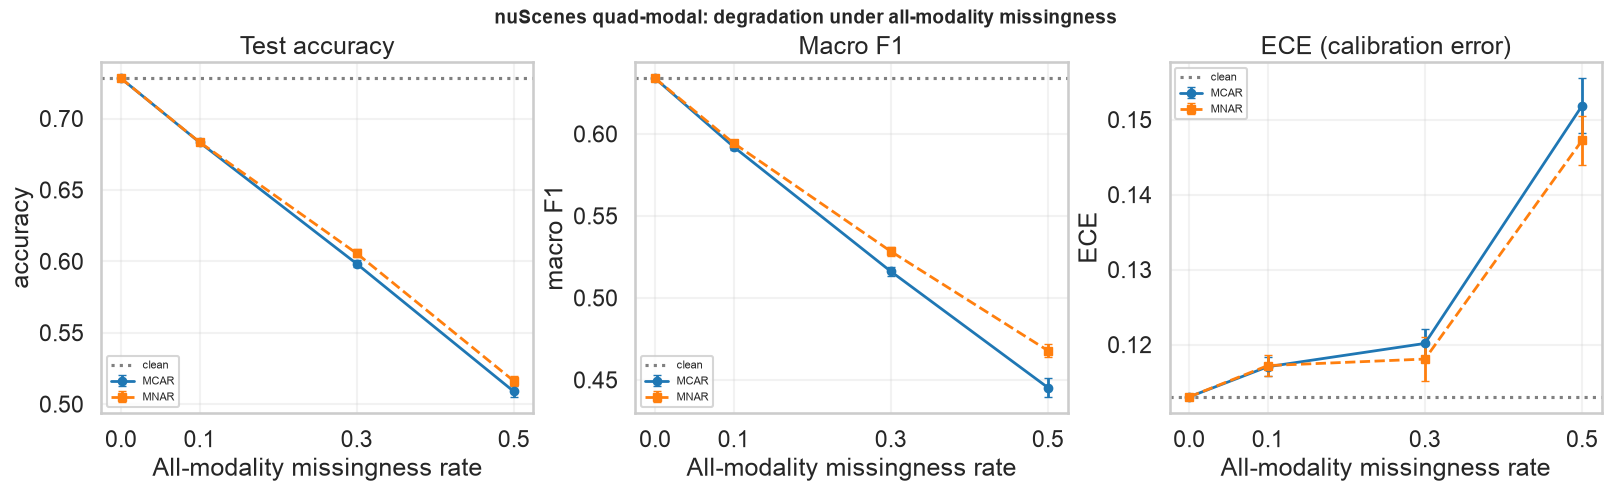

Saved: /Users/calebcooper/nuScenes/uq_results/object_classification/new_matched_figures/01_degradation_three_panel.png


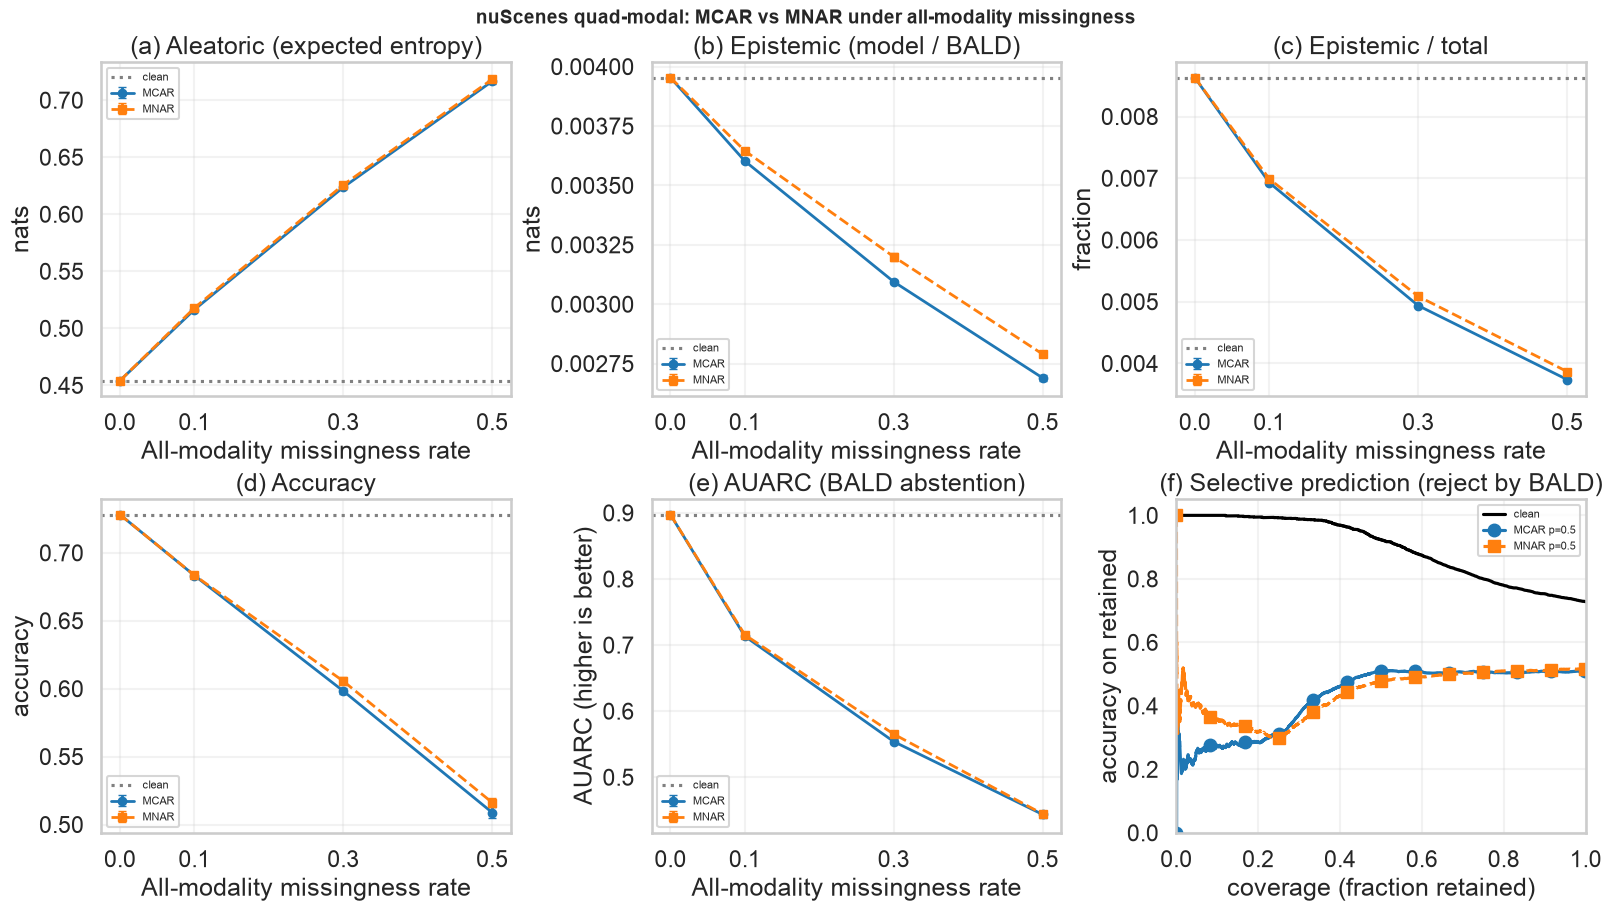

Saved: /Users/calebcooper/nuScenes/uq_results/object_classification/new_matched_figures/02_uq_bald_six_panel.png


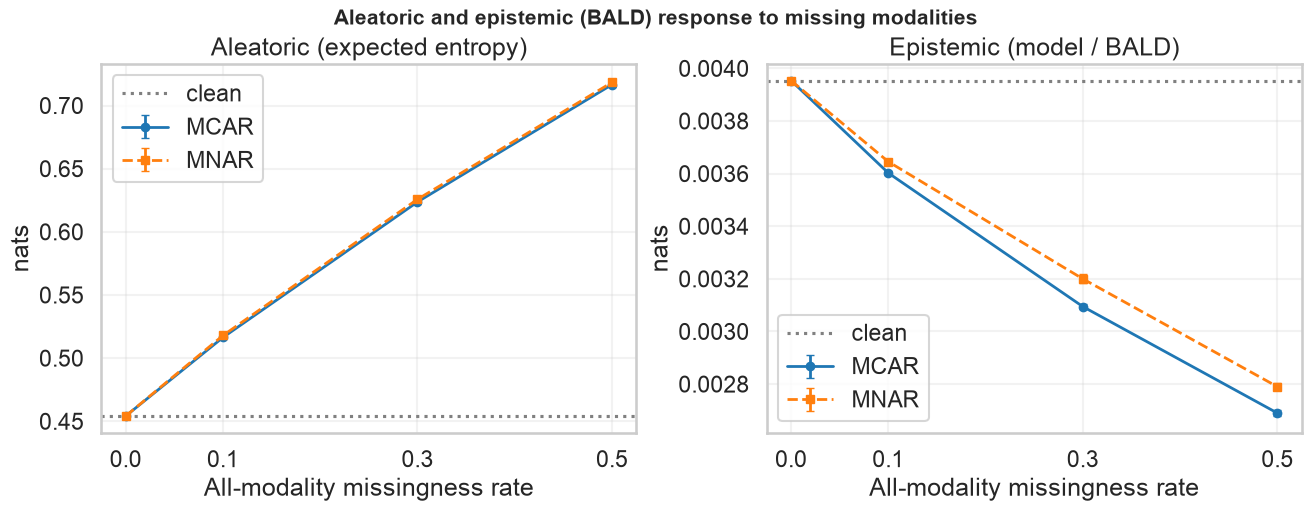

Saved: /Users/calebcooper/nuScenes/uq_results/object_classification/new_matched_figures/03_aleatoric_vs_bald.png


,mechanism,rate,accuracy,accuracy_ci95,macro_f1,macro_f1_ci95,ece,ece_ci95,aleatoric,aleatoric_ci95,bald,bald_ci95,bald_fraction,bald_fraction_ci95,auarc,auarc_ci95
0,MCAR,0.0,0.728114,0.000000,0.633841,0.000000,0.113032,0.000000,0.454163,0.000000,0.003954,0.000000,0.008631,0.000000,0.897357,0.000000
1,MCAR,0.1,0.683308,0.001204,0.592077,0.001630,0.117055,0.001298,0.516386,0.000829,0.003602,0.000008,0.006928,0.000018,0.713262,0.003022
2,MCAR,0.3,0.598279,0.002512,0.516150,0.002578,0.120159,0.001858,0.623663,0.001757,0.003094,0.000010,0.004937,0.000011,0.553938,0.004040
3,MCAR,0.5,0.508841,0.003779,0.445285,0.005651,0.151837,0.003661,0.716582,0.001986,0.002690,0.000011,0.003740,0.000017,0.443655,0.004824
4,MNAR,0.0,0.728114,0.000000,0.633841,0.000000,0.113032,0.000000,0.454163,0.000000,0.003954,0.000000,0.008631,0.000000,0.897357,0.000000
5,MNAR,0.1,0.683459,0.001465,0.594309,0.001700,0.117205,0.001358,0.517925,0.000657,0.003645,0.000010,0.006989,0.000017,0.715451,0.003322
6,MNAR,0.3,0.605550,0.002784,0.528374,0.002782,0.118075,0.002990,0.625769,0.001569,0.003200,0.000017,0.005088,0.000020,0.565219,0.003589
7,MNAR,0.5,0.516197,0.003315,0.467834,0.003889,0.147220,0.003234,0.718335,0.001452,0.002790,0.000013,0.003869,0.000018,0.444492,0.003266


In [131]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

new_figure_root = Path(results_root) / "new_matched_figures"
new_figure_root.mkdir(parents=True, exist_ok=True)

presentation_rates = np.array([0.0, 0.1, 0.3, 0.5])
presentation_styles = {
    "MCAR": {"color": "#1f77b4", "marker": "o", "linestyle": "-"},
    "MNAR": {"color": "#ff7f0e", "marker": "s", "linestyle": "--"}}

def build_presentation_summary():
    rows = []
    clean_auarc = calculate_auarc(
        clean_result["details"]["labels"],
        clean_result["details"]["predictions"],
        clean_result["details"]["epistemic_uncertainty"])

    for mechanism in ["MCAR", "MNAR"]:
        clean_total = clean_result["total_uncertainty"]
        rows.append({
            "mechanism": mechanism,
            "rate": 0.0,
            "accuracy": clean_result["accuracy"],
            "accuracy_ci95": 0.0,
            "macro_f1": clean_result["macro_f1"],
            "macro_f1_ci95": 0.0,
            "ece": clean_result["ece"],
            "ece_ci95": 0.0,
            "aleatoric": clean_result["aleatoric_uncertainty"],
            "aleatoric_ci95": 0.0,
            "bald": clean_result["epistemic_uncertainty"],
            "bald_ci95": 0.0,
            "bald_fraction": (clean_result["epistemic_uncertainty"] / max(clean_total, 1e-12)),
            "bald_fraction_ci95": 0.0,
            "auarc": clean_auarc,
            "auarc_ci95": 0.0})

        for rate in presentation_rates[1:]:
            subset = raw_results_df[(raw_results_df["mechanism"] == mechanism) & (raw_results_df["condition"] == "all_modalities") & np.isclose(raw_results_df["rate"], rate)].copy()
            selective_subset = selective_raw_df[(selective_raw_df["mechanism"] == mechanism) & (selective_raw_df["condition"] == "all_modalities") & np.isclose(selective_raw_df["rate"], rate)]
            bald_fraction = (subset["epistemic_uncertainty"] / subset["total_uncertainty"].clip(lower=1e-12))
            accuracy, accuracy_ci = summarize_values(subset["accuracy"])
            macro_f1, macro_f1_ci = summarize_values(subset["macro_f1"])
            ece, ece_ci = summarize_values(subset["ece"])
            aleatoric, aleatoric_ci = summarize_values(subset["aleatoric_uncertainty"])
            bald, bald_ci = summarize_values(subset["epistemic_uncertainty"])
            fraction, fraction_ci = summarize_values(bald_fraction)
            auarc, auarc_ci = summarize_values(selective_subset["auarc_epistemic"])

            rows.append({
                "mechanism": mechanism,
                "rate": rate,
                "accuracy": accuracy,
                "accuracy_ci95": accuracy_ci,
                "macro_f1": macro_f1,
                "macro_f1_ci95": macro_f1_ci,
                "ece": ece,
                "ece_ci95": ece_ci,
                "aleatoric": aleatoric,
                "aleatoric_ci95": aleatoric_ci,
                "bald": bald,
                "bald_ci95": bald_ci,
                "bald_fraction": fraction,
                "bald_fraction_ci95": fraction_ci,
                "auarc": auarc,
                "auarc_ci95": auarc_ci})

    summary = pd.DataFrame(rows)
    summary.to_csv(new_figure_root / "new_matched_plot_values.csv", index=False)
    return summary

def format_presentation_axis(axis, ylabel):
    axis.set_xlabel("All-modality missingness rate")
    axis.set_ylabel(ylabel)
    axis.set_xticks(presentation_rates)
    axis.set_xticklabels(["0.0", "0.1", "0.3", "0.5"])
    axis.grid(alpha=0.25)

def plot_presentation_metric(axis, summary, metric, ci_column, ylabel, clean_value):
    for mechanism in ["MCAR", "MNAR"]:
        subset = summary[summary["mechanism"] == mechanism].sort_values("rate")
        style = presentation_styles[mechanism]
        axis.errorbar(
            subset["rate"], subset[metric], yerr=subset[ci_column],
            color=style["color"], marker=style["marker"],
            linestyle=style["linestyle"], linewidth=2,
            markersize=6, capsize=3, label=mechanism)
    axis.axhline(clean_value, color="gray", linestyle=":", label="clean")
    format_presentation_axis(axis, ylabel)

def save_presentation_figure(figure, filename):
    output_path = new_figure_root / filename
    figure.savefig(output_path, dpi=250, bbox_inches="tight")
    plt.show()
    plt.close(figure)
    print("Saved:", output_path)

presentation_summary_df = build_presentation_summary()

# Figure 1: performance and calibration degradation.
figure, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)
figure.suptitle(
    "nuScenes quad-modal: degradation under all-modality missingness",
    fontsize=14, fontweight="bold")
for axis, metric, ci_column, title, ylabel, clean_value in [
    (axes[0], "accuracy", "accuracy_ci95", "Test accuracy", "accuracy", clean_result["accuracy"]),
    (axes[1], "macro_f1", "macro_f1_ci95", "Macro F1", "macro F1", clean_result["macro_f1"]),
    (axes[2], "ece", "ece_ci95", "ECE (calibration error)", "ECE", clean_result["ece"])]:
    plot_presentation_metric(axis, presentation_summary_df, metric, ci_column, ylabel, clean_value)
    axis.set_title(title)
    axis.legend(fontsize=8)
save_presentation_figure(figure, "01_degradation_three_panel.png")

# Figure 2: uncertainty, performance, and BALD-based abstention.
figure, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)
figure.suptitle(
    "nuScenes quad-modal: MCAR vs MNAR under all-modality missingness",
    fontsize=14, fontweight="bold")
six_panel_specs = [
    (axes[0, 0], "aleatoric", "aleatoric_ci95", "(a) Aleatoric (expected entropy)", "nats", clean_result["aleatoric_uncertainty"]),
    (axes[0, 1], "bald", "bald_ci95", "(b) Epistemic (model / BALD)", "nats", clean_result["epistemic_uncertainty"]),
    (axes[0, 2], "bald_fraction", "bald_fraction_ci95", "(c) Epistemic / total", "fraction", clean_result["epistemic_uncertainty"] / max(clean_result["total_uncertainty"], 1e-12)),
    (axes[1, 0], "accuracy", "accuracy_ci95", "(d) Accuracy", "accuracy", clean_result["accuracy"]),
    (axes[1, 1], "auarc", "auarc_ci95", "(e) AUARC (BALD abstention)", "AUARC (higher is better)", presentation_summary_df.loc[presentation_summary_df["rate"].eq(0), "auarc"].iloc[0])]
for axis, metric, ci_column, title, ylabel, clean_value in six_panel_specs:
    plot_presentation_metric(axis, presentation_summary_df, metric, ci_column, ylabel, clean_value)
    axis.set_title(title)
    axis.legend(fontsize=8)

selective_axis = axes[1, 2]
clean_coverage, clean_risk = risk_coverage_curve(
    clean_result["details"]["labels"],
    clean_result["details"]["predictions"],
    clean_result["details"]["epistemic_uncertainty"])
selective_axis.plot(clean_coverage, 1 - clean_risk, color="black", label="clean")
for mechanism in ["MCAR", "MNAR"]:
    key = f"{mechanism}__all_modalities__0.5__0"
    details = condition_details[key]
    coverage, risk = risk_coverage_curve(details["labels"], details["predictions"], details["epistemic_uncertainty"])
    style = presentation_styles[mechanism]
    selective_axis.plot(
        coverage, 1 - risk, color=style["color"],
        marker=style["marker"], markevery=max(1, len(coverage) // 12),
        linestyle=style["linestyle"], label=f"{mechanism} p=0.5")
selective_axis.set_title("(f) Selective prediction (reject by BALD)")
selective_axis.set_xlabel("coverage (fraction retained)")
selective_axis.set_ylabel("accuracy on retained")
selective_axis.set_xlim(0, 1)
selective_axis.set_ylim(0, 1.05)
selective_axis.grid(alpha=0.25)
selective_axis.legend(fontsize=8)
save_presentation_figure(figure, "02_uq_bald_six_panel.png")

# Figure 3: the focused uncertainty conclusion slide.
figure, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
figure.suptitle("Aleatoric and epistemic (BALD) response to missing modalities", fontsize=15, fontweight="bold")
plot_presentation_metric(axes[0], presentation_summary_df, "aleatoric", "aleatoric_ci95", "nats", clean_result["aleatoric_uncertainty"])
axes[0].set_title("Aleatoric (expected entropy)")
axes[0].legend()
plot_presentation_metric(axes[1], presentation_summary_df, "bald", "bald_ci95", "nats", clean_result["epistemic_uncertainty"])
axes[1].set_title("Epistemic (model / BALD)")
axes[1].legend()
save_presentation_figure(figure, "03_aleatoric_vs_bald.png")

display(presentation_summary_df.round(6))

In [132]:

conclusive_seeds = [42, 43, 44, 45, 46]
conclusive_mask_repeats = 5
conclusive_mc_passes = 20
conclusive_rates = [0.1, 0.3, 0.5]

conclusive_root = results_root / "conclusive_multiseed"
conclusive_root.mkdir(parents=True, exist_ok=True)

print("Conclusive seeds:", conclusive_seeds)
print("Mask repeats per condition:", conclusive_mask_repeats)
print("MC-dropout passes:", conclusive_mc_passes)

Conclusive seeds: [42, 43, 44, 45, 46]
Mask repeats per condition: 5
MC-dropout passes: 20


In [133]:
import copy

def set_experiment_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if hasattr(torch.backends, "cudnn"):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

def make_seeded_train_loader(seed):
    generator = torch.Generator()
    generator.manual_seed(seed)
    return DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, generator=generator)

def train_one_seed(seed):
    set_experiment_seed(seed)
    mode_tag = (
        "centralized" if TRAINING_MODE == "centralized"
        else f"{TRAINING_MODE}_mu_{0.0 if TRAINING_MODE == 'fedavg' else FEDPROX_MU:g}"
    )
    checkpoint_path = conclusive_root / f"fusion_model_{mode_tag}_seed_{seed}.pt"
    model = PresenceAwareFusion().to(DEVICE)

    if TRAINING_MODE in {"fedavg", "fedprox"}:
        model, best_validation_f1, seed_history = train_federated(
            global_model=model,
            seed=seed,
            checkpoint_path=checkpoint_path,
        )
        seed_history.to_csv(
            conclusive_root / f"training_history_{mode_tag}_seed_{seed}.csv",
            index=False,
        )
        print(
            f"Seed {seed}: {TRAINING_MODE} trained and saved; "
            f"best validation Macro F1={best_validation_f1:.3f}"
        )
        return model, best_validation_f1

    loader = make_seeded_train_loader(seed)
    optimizer_for_seed = AdamW(
        model.parameters(), lr=learning_rate, weight_decay=weight_decay
    )
    best_validation_f1 = -np.inf
    best_state = None
    epochs_without_improvement = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        for batch in loader:
            inputs = [batch[name].to(DEVICE) for name in modality_order]
            targets = batch["label"].to(DEVICE)
            optimizer_for_seed.zero_grad(set_to_none=True)
            presence = sample_training_presence(len(targets), DEVICE)
            logits, _ = model(*inputs, presence_mask=presence)
            loss = criterion(logits, targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer_for_seed.step()

        _, validation_f1 = evaluate_model(model, validation_loader)
        if validation_f1 > best_validation_f1:
            best_validation_f1 = validation_f1
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
        if epochs_without_improvement >= early_stopping_patience:
            break

    model.load_state_dict(best_state)
    package = {
        "model_state": best_state,
        "algorithm": "centralized",
        "seed": seed,
        "best_validation_macro_f1": float(best_validation_f1),
    }
    torch.save(package, checkpoint_path)
    print(
        f"Seed {seed}: centralized model trained and saved; "
        f"best validation Macro F1={best_validation_f1:.3f}"
    )
    return model, best_validation_f1


In [134]:
def evaluate_dataset_arrays(model, dataset, presence_vector=None, permute_modality_index=None, permutation_seed=0):
    model.eval()
    modality_tensors = [dataset.vision, dataset.radar, dataset.depth, dataset.imu]
    permutation = None
    if permute_modality_index is not None:
        generator = torch.Generator()
        generator.manual_seed(permutation_seed)
        permutation = torch.randperm(len(dataset), generator=generator)

    labels_out = []
    predictions_out = []
    gates_out = []

    with torch.no_grad():
        for start in range(0, len(dataset), batch_size):
            stop = min(start + batch_size, len(dataset))
            batch_inputs = []
            for modality_index, values in enumerate(modality_tensors):
                if modality_index == permute_modality_index:
                    selected = values[permutation[start:stop]]
                else:
                    selected = values[start:stop]

                batch_inputs.append(selected.to(DEVICE))
            if presence_vector is None:
                presence = torch.ones(stop - start, 4, dtype=torch.float32, device=DEVICE)
            else:
                presence = torch.as_tensor(presence_vector, dtype=torch.float32, device=DEVICE).repeat(stop - start, 1)

            logits, gates = model(*batch_inputs, presence_mask=presence)
            labels_out.append(dataset.labels[start:stop].numpy())
            predictions_out.append(logits.argmax(dim=1).cpu().numpy())
            gates_out.append(gates.cpu().numpy())

    labels_out = np.concatenate(labels_out)
    predictions_out = np.concatenate(predictions_out)
    gates_out = np.concatenate(gates_out)
    return {
        "accuracy": accuracy_score(labels_out, predictions_out),
        "macro_f1": f1_score(labels_out, predictions_out, average="macro"), "gate_weights": gates_out}

def run_modality_importance(model, seed):
    rows = []
    clean = evaluate_dataset_arrays(model, test_dataset)
    for modality_index, modality_name in enumerate(modality_order):
        leave_one_out = np.ones(4, dtype=np.float32)
        leave_one_out[modality_index] = 0
        only_one = np.zeros(4, dtype=np.float32)
        only_one[modality_index] = 1
        removed = evaluate_dataset_arrays(model, test_dataset, presence_vector=leave_one_out)
        only = evaluate_dataset_arrays(model, test_dataset, presence_vector=only_one)
        shuffled = evaluate_dataset_arrays(model, test_dataset, permute_modality_index=modality_index, permutation_seed=1000 + seed + modality_index)
        rows.append({
            "seed": seed,
            "modality": modality_name,
            "clean_accuracy": clean["accuracy"],
            "clean_macro_f1": clean["macro_f1"],
            "clean_gate_weight": clean["gate_weights"][
                :, modality_index].mean(),
            "leave_one_out_accuracy": removed["accuracy"],
            "leave_one_out_macro_f1": removed["macro_f1"],
            "leave_one_out_f1_drop": (
                clean["macro_f1"] - removed["macro_f1"]),
            "only_modality_accuracy": only["accuracy"],
            "only_modality_macro_f1": only["macro_f1"],
            "permuted_accuracy": shuffled["accuracy"],
            "permuted_macro_f1": shuffled["macro_f1"],
            "permutation_f1_drop": (
                clean["macro_f1"] - shuffled["macro_f1"])})
    return rows

trained_models = {}
seed_training_rows = []
importance_rows = []

for experiment_seed in conclusive_seeds:
    model, best_validation_f1 = train_one_seed(experiment_seed)
    trained_models[experiment_seed] = model
    seed_training_rows.append({
        "seed": experiment_seed,
        "best_validation_macro_f1": best_validation_f1})
    importance_rows.extend(run_modality_importance(model, experiment_seed))

seed_training_df = pd.DataFrame(seed_training_rows)
importance_df = pd.DataFrame(importance_rows)
seed_training_df.to_csv(conclusive_root / "seed_checkpoints.csv", index=False)
importance_df.to_csv(conclusive_root / "modality_importance_by_seed.csv", index=False)

print("\nCheckpoint audit")
display(seed_training_df)

print("\nModality importance for every seed")
display(importance_df.round(4))


Round 01 | FEDPROX mu=0.01 | Task loss: 0.8597 | Prox norm²: 3.7429 | Val acc: 0.638 | Val Macro F1: 0.261
Round 02 | FEDPROX mu=0.01 | Task loss: 0.8367 | Prox norm²: 2.6671 | Val acc: 0.626 | Val Macro F1: 0.384
Round 03 | FEDPROX mu=0.01 | Task loss: 0.8269 | Prox norm²: 2.1358 | Val acc: 0.311 | Val Macro F1: 0.165
Round 04 | FEDPROX mu=0.01 | Task loss: 0.8226 | Prox norm²: 1.9302 | Val acc: 0.338 | Val Macro F1: 0.222
Round 05 | FEDPROX mu=0.01 | Task loss: 0.8199 | Prox norm²: 1.7367 | Val acc: 0.336 | Val Macro F1: 0.220
Round 06 | FEDPROX mu=0.01 | Task loss: 0.8228 | Prox norm²: 1.7208 | Val acc: 0.639 | Val Macro F1: 0.415
Round 07 | FEDPROX mu=0.01 | Task loss: 0.8186 | Prox norm²: 1.7216 | Val acc: 0.278 | Val Macro F1: 0.178
Round 08 | FEDPROX mu=0.01 | Task loss: 0.8246 | Prox norm²: 2.0680 | Val acc: 0.326 | Val Macro F1: 0.241
Round 09 | FEDPROX mu=0.01 | Task loss: 0.8145 | Prox norm²: 2.1793 | Val acc: 0.306 | Val Macro F1: 0.223
Round 10 | FEDPROX mu=0.01 | Task los

,seed,best_validation_macro_f1
0,42,0.866061
1,43,0.870227
2,44,0.869239
3,45,0.876695
4,46,0.871659



Modality importance for every seed


,seed,modality,clean_accuracy,clean_macro_f1,clean_gate_weight,leave_one_out_accuracy,leave_one_out_macro_f1,leave_one_out_f1_drop,only_modality_accuracy,only_modality_macro_f1,permuted_accuracy,permuted_macro_f1,permutation_f1_drop
0,42,vision,0.7277,0.6329,0.9993,0.3097,0.1577,0.4753,0.7277,0.6329,0.3880,0.3089,0.3240
1,42,radar,0.7277,0.6329,0.0006,0.7277,0.6329,0.0000,0.3052,0.1612,0.7277,0.6329,0.0000
2,42,depth,0.7277,0.6329,0.0000,0.7122,0.5851,0.0478,0.1792,0.1013,0.7277,0.6329,0.0000
3,42,imu,0.7277,0.6329,0.0000,0.7277,0.6329,0.0000,0.3732,0.2748,0.7277,0.6329,0.0000
4,43,vision,0.7352,0.6094,0.9978,0.3538,0.2451,0.3643,0.7350,0.6092,0.4029,0.3091,0.3004
5,43,radar,0.7352,0.6094,0.0012,0.7352,0.6094,0.0000,0.3097,0.1577,0.7352,0.6094,0.0000
6,43,depth,0.7352,0.6094,0.0003,0.7245,0.5851,0.0244,0.1792,0.1013,0.7352,0.6094,0.0000
7,43,imu,0.7352,0.6094,0.0007,0.7352,0.6094,-0.0000,0.3975,0.2928,0.7352,0.6094,0.0000
8,44,vision,0.7567,0.6826,0.9943,0.3196,0.2391,0.4435,0.7576,0.6842,0.3801,0.3093,0.3734
9,44,radar,0.7567,0.6826,0.0039,0.7565,0.6822,0.0004,0.3201,0.1728,0.7567,0.6827,-0.0001


,modality,clean_gate_weight_ci95,clean_gate_weight_mean,leave_one_out_f1_drop_ci95,leave_one_out_f1_drop_mean,only_modality_macro_f1_ci95,only_modality_macro_f1_mean,permutation_f1_drop_ci95,permutation_f1_drop_mean
0,vision,0.0018,0.9976,0.0562,0.4202,0.0270,0.6342,0.0262,0.3249
1,radar,0.0012,0.0016,0.0002,0.0001,0.0057,0.1614,0.0000,-0.0000
2,depth,0.0001,0.0002,0.0109,0.0459,0.0000,0.1013,0.0000,0.0000
3,imu,0.0005,0.0006,0.0005,0.0001,0.0065,0.2867,0.0004,-0.0000


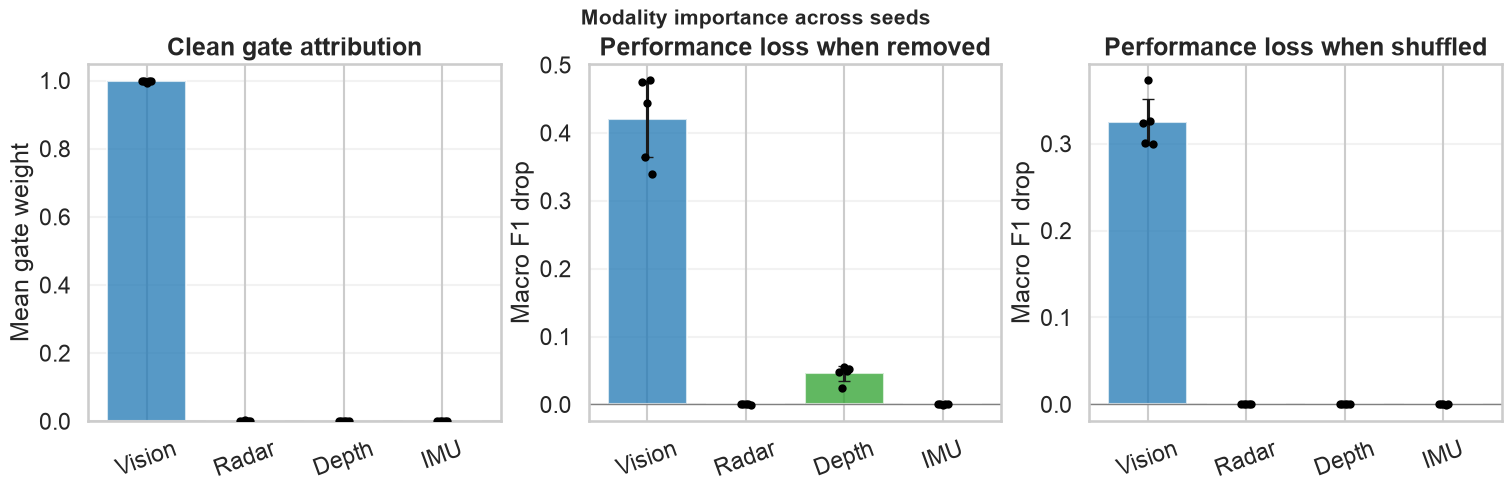

Saved: /Users/calebcooper/nuScenes/uq_results/object_classification/conclusive_multiseed/multiseed_modality_importance.png


In [135]:
def summarize_importance_across_seeds():
    rows = []
    metrics = ["clean_gate_weight", "leave_one_out_f1_drop", "only_modality_macro_f1", "permutation_f1_drop"]
    for modality in modality_order:
        subset = importance_df[importance_df["modality"] == modality]
        row = {"modality": modality}
        for metric in metrics:
            mean, interval = summarize_values(subset[metric])
            row[f"{metric}_ci95"] = interval
            row[f"{metric}_mean"] = mean
        rows.append(row)
    return pd.DataFrame(rows)

importance_summary_df = summarize_importance_across_seeds()
importance_summary_df.to_csv(conclusive_root / "modality_importance_summary.csv", index=False)
display(importance_summary_df.round(4))
figure, axes = plt.subplots(1, 3, figsize=(15, 4.8), constrained_layout=True)
plot_specs = [
    ("clean_gate_weight", "Clean gate attribution", "Mean gate weight"),
    ("leave_one_out_f1_drop", "Performance loss when removed", "Macro F1 drop"),
    ("permutation_f1_drop", "Performance loss when shuffled", "Macro F1 drop")]

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
x_positions = np.arange(4)

for axis, (metric, title, ylabel) in zip(axes, plot_specs):
    means = importance_summary_df[f"{metric}_mean"]
    intervals = importance_summary_df[f"{metric}_ci95"]
    axis.bar(x_positions, means, yerr=intervals, color=colors, alpha=0.75, capsize=4)

    for seed_index, seed in enumerate(conclusive_seeds):
        seed_subset = importance_df[importance_df["seed"] == seed].set_index("modality").loc[list(modality_order)]
        horizontal_jitter = (seed_index - (len(conclusive_seeds) - 1) / 2) * 0.025
        axis.scatter(x_positions + horizontal_jitter, seed_subset[metric], color="black", s=20, zorder=3)
    axis.axhline(0, color="gray", linewidth=1)
    axis.set_title(title, fontweight="bold")
    axis.set_ylabel(ylabel)
    axis.set_xticks(x_positions)
    axis.set_xticklabels(["Vision", "Radar", "Depth", "IMU"], rotation=20)
    axis.grid(axis="y", alpha=0.25)

figure.suptitle("Modality importance across seeds", fontsize=15, fontweight="bold")
importance_figure_path = (conclusive_root / "multiseed_modality_importance.png")
figure.savefig(importance_figure_path, dpi=200, bbox_inches="tight")
plt.show()
plt.close(figure)
print("Saved:", importance_figure_path)

In [136]:
def selected_and_retained_scores(mask, scores):
    selected = scores[mask == 0]
    retained = scores[mask == 1]
    pooled_variance = (selected.var(ddof=1) + retained.var(ddof=1)) / 2
    standardized_difference = (selected.mean() - retained.mean()) / np.sqrt(max(pooled_variance, 1e-12))
    return (selected.mean(), retained.mean(), standardized_difference)

def validate_mnar_selection():
    rows = []
    test_scores = mnar_scores_by_modality[test_indices]
    n_samples = len(test_indices)

    for rate in conclusive_rates:
        for repeat in range(conclusive_mask_repeats):
            for modality_index, modality_name in enumerate(modality_order):
                mcar_rng = np.random.default_rng(300_000 + int(rate * 1000) * 100 + repeat * 10 + modality_index)
                mnar_rng = np.random.default_rng(400_000 + int(rate * 1000) * 100 + repeat * 10 + modality_index)
                mcar_mask = make_presence_mask(n_samples, [modality_index], rate, mcar_rng)[:, modality_index]
                mnar_mask = make_presence_mask(n_samples, [modality_index], rate, mnar_rng, scores=test_scores)[:, modality_index]

                for mechanism, mask in [("MCAR", mcar_mask), ("MNAR", mnar_mask)]:
                    selected_mean, retained_mean, effect_size = (selected_and_retained_scores(mask, test_scores[:, modality_index]))
                    rows.append({
                        "mechanism": mechanism,
                        "rate": rate,
                        "repeat": repeat,
                        "modality": modality_name,
                        "realized_missingness": 1 - mask.mean(),
                        "selected_score_mean": selected_mean,
                        "retained_score_mean": retained_mean,
                        "selected_minus_retained": (selected_mean - retained_mean),
                        "standardized_difference": effect_size})
    return pd.DataFrame(rows)

mnar_validation_df = validate_mnar_selection()
mnar_validation_df.to_csv(conclusive_root / "mnar_selection_validation.csv", index=False)
mnar_validation_summary = (mnar_validation_df.groupby(["mechanism", "rate", "modality"])[["realized_missingness", "selected_minus_retained", "standardized_difference"]].mean().reset_index())


In [137]:
def run_matched_mcar_mnar_evaluations():
    rows = []
    test_scores = mnar_scores_by_modality[test_indices]
    n_samples = len(test_indices)
    for seed, model in trained_models.items():
        for rate in conclusive_rates:
            for repeat in range(conclusive_mask_repeats):
                for mechanism in ["MCAR", "MNAR"]:
                    rng_base = 500_000 if mechanism == "MCAR" else 600_000
                    rng = np.random.default_rng(rng_base + seed * 1000 + int(rate * 100) * 10 + repeat)
                    presence_mask = make_presence_mask(n_samples, [0, 1, 2, 3], rate, rng, scores=(None if mechanism == "MCAR" else test_scores))
                    result = evaluate_uq_condition(model, test_loader, presence_mask, conclusive_mc_passes)
                    rows.append({"seed": seed, "rate": rate, "repeat": repeat,"mechanism": mechanism,
                        **{key: result[key]for key in [
                                "accuracy", "macro_f1", "ece", "adaptive_ece", "brier", "nll", "total_uncertainty", "aleatoric_uncertainty", "epistemic_uncertainty"]}})
    return pd.DataFrame(rows)
matched_uq_df = run_matched_mcar_mnar_evaluations()
matched_uq_df.to_csv(conclusive_root / "matched_mcar_mnar_by_seed_and_repeat.csv", index=False)
display(matched_uq_df.head().round(4))
print("Matched MCAR/MNAR evaluations:", len(matched_uq_df))

,seed,rate,repeat,mechanism,accuracy,macro_f1,ece,adaptive_ece,brier,nll,total_uncertainty,aleatoric_uncertainty,epistemic_uncertainty
0,42,0.1,0,MCAR,0.6844,0.5949,0.1144,0.1139,0.3882,0.6469,0.5211,0.5176,0.0035
1,42,0.1,0,MNAR,0.6872,0.5939,0.1167,0.1166,0.3847,0.6418,0.5189,0.5154,0.0035
2,42,0.1,1,MCAR,0.6881,0.5959,0.1143,0.1144,0.3806,0.6340,0.5178,0.5143,0.0035
3,42,0.1,1,MNAR,0.6823,0.5921,0.1191,0.1198,0.3916,0.6529,0.5213,0.5177,0.0036
4,42,0.1,2,MCAR,0.6823,0.5919,0.1143,0.1149,0.3890,0.6477,0.5192,0.5157,0.0035


Matched MCAR/MNAR evaluations: 150


In [138]:
def paired_seed_level_summary(results):
    metrics = ["accuracy", "macro_f1", "ece", "adaptive_ece", "brier", "nll", "aleatoric_uncertainty", "epistemic_uncertainty"]
    seed_means = (results.groupby(["seed", "rate", "mechanism"])[metrics].mean().reset_index())
    difference_rows = []
    for rate in conclusive_rates:
        rate_rows = seed_means[np.isclose(seed_means["rate"], rate)]
        for metric in metrics:
            pivot = rate_rows.pivot(index="seed", columns="mechanism", values=metric)
            differences = pivot["MNAR"] - pivot["MCAR"]
            mean_difference, interval = summarize_values(differences)
            if np.isnan(interval):
                conclusion = "Not enough independent seeds"
            elif (mean_difference - interval > 0 or mean_difference + interval < 0):
                conclusion = "Consistent difference"
            else:
                conclusion = "Inconclusive: interval crosses zero"
            difference_rows.append({
                "rate": rate,
                "metric": metric,
                "mnar_minus_mcar_mean": mean_difference,
                "ci95_half_width": interval,
                "ci95_lower": mean_difference - interval,
                "ci95_upper": mean_difference + interval,
                "n_seeds": len(differences),
                "conclusion": conclusion})
    return seed_means, pd.DataFrame(difference_rows)
seed_means_df, paired_difference_df = paired_seed_level_summary(matched_uq_df)
seed_means_df.to_csv(conclusive_root / "mcar_mnar_seed_means.csv", index=False)
paired_difference_df.to_csv(conclusive_root / "mnar_minus_mcar_paired_differences.csv", index=False)
print("Positive = MNAR higher than MCAR.")
display(paired_difference_df.round(5))

Positive = MNAR higher than MCAR.


,rate,metric,mnar_minus_mcar_mean,ci95_half_width,ci95_lower,ci95_upper,n_seeds,conclusion
0,0.1,accuracy,-0.00046,0.00288,-0.00333,0.00242,5,Inconclusive: interval crosses zero
1,0.1,macro_f1,0.00062,0.00358,-0.00297,0.00420,5,Inconclusive: interval crosses zero
2,0.1,ece,0.00140,0.00199,-0.00059,0.00339,5,Inconclusive: interval crosses zero
3,0.1,adaptive_ece,0.00180,0.00251,-0.00071,0.00431,5,Inconclusive: interval crosses zero
4,0.1,brier,-0.00064,0.00238,-0.00301,0.00174,5,Inconclusive: interval crosses zero
5,0.1,nll,-0.00211,0.00457,-0.00668,0.00247,5,Inconclusive: interval crosses zero
6,0.1,aleatoric_uncertainty,0.00109,0.00086,0.00022,0.00195,5,Consistent difference
7,0.1,epistemic_uncertainty,0.00003,0.00001,0.00003,0.00004,5,Consistent difference
8,0.3,accuracy,0.00644,0.00130,0.00514,0.00775,5,Consistent difference
9,0.3,macro_f1,0.01003,0.00242,0.00761,0.01245,5,Consistent difference


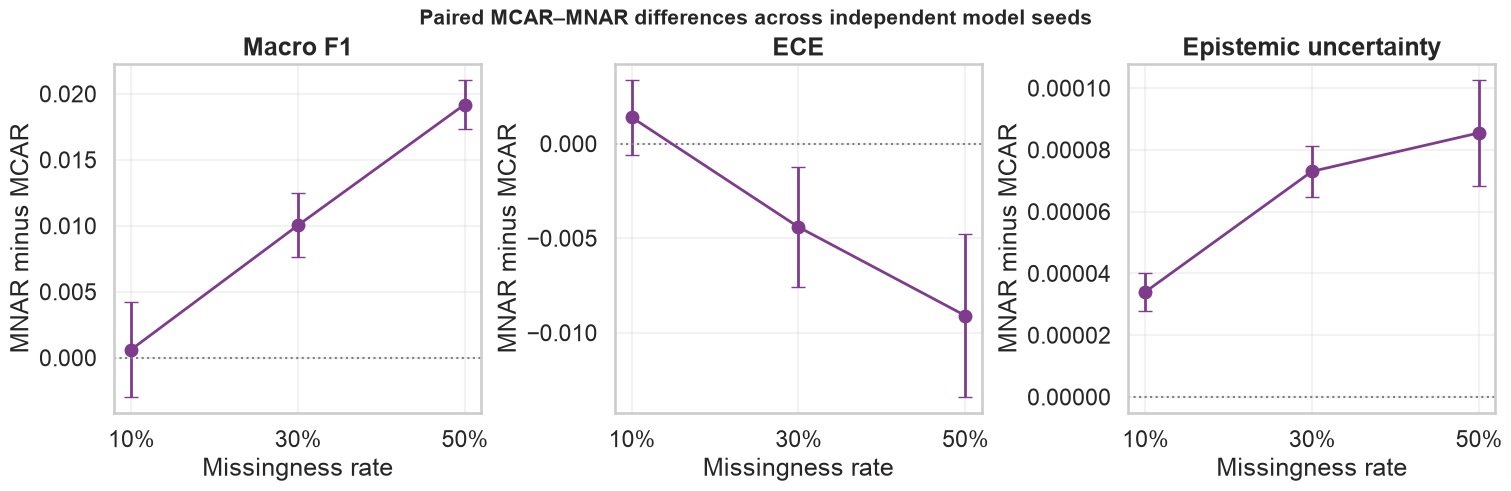

Saved: /Users/calebcooper/nuScenes/uq_results/object_classification/conclusive_multiseed/paired_mnar_minus_mcar.png

Notes:
If gates are stable across seeds that probably means the model relies on the same modalities
If gates are all over the place the modalities might be redundant
MNAR is working if it picks harder samples than MCAR
Only say MCAR vs MNAR is different if the CI doesn't cross zero


In [139]:
metrics_to_plot = [("macro_f1", "Macro F1"), ("ece", "ECE"), ("epistemic_uncertainty", "Epistemic uncertainty")]
figure, axes = plt.subplots(1, 3, figsize=(15, 4.8), constrained_layout=True)
for axis, (metric, display_name) in zip(axes, metrics_to_plot):
    summary_rows = paired_difference_df[paired_difference_df["metric"] == metric].sort_values("rate")
    axis.errorbar(summary_rows["rate"], summary_rows["mnar_minus_mcar_mean"], yerr=summary_rows["ci95_half_width"], marker="o", color="#7f3c8d", capsize=5, linewidth=2)
    axis.axhline(0, color="gray", linestyle=":", linewidth=1.5)
    axis.set_title(display_name, fontweight="bold")
    axis.set_xlabel("Missingness rate")
    axis.set_ylabel("MNAR minus MCAR")
    axis.set_xticks(conclusive_rates)
    axis.set_xticklabels(["10%", "30%", "50%"])
    axis.grid(alpha=0.25)
figure.suptitle("Paired MCAR–MNAR differences across independent model seeds", fontsize=15, fontweight="bold")
paired_figure_path = (conclusive_root / "paired_mnar_minus_mcar.png")
figure.savefig(paired_figure_path, dpi=200, bbox_inches="tight")
plt.show()
plt.close(figure)
print("Saved:", paired_figure_path)
print("\nNotes:")
print("If gates are stable across seeds that probably means the model relies on the same modalities")
print("If gates are all over the place the modalities might be redundant")
print("MNAR is working if it picks harder samples than MCAR")
print("Only say MCAR vs MNAR is different if the CI doesn't cross zero")

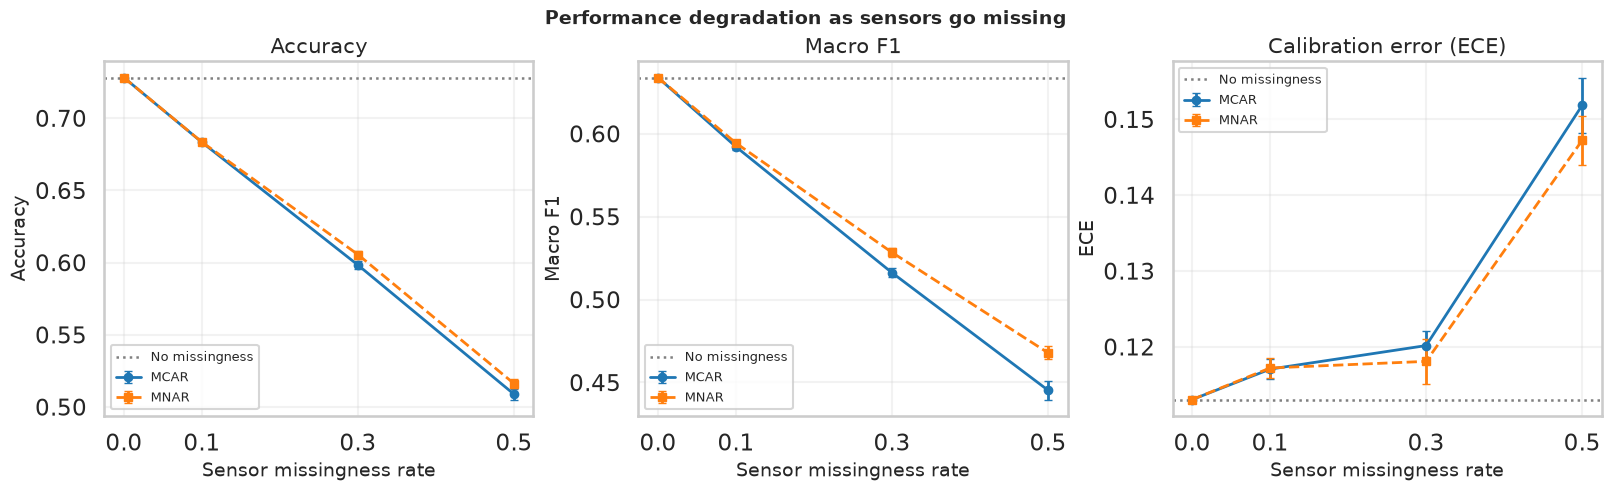

Saved: 01_degradation_three_panel_natural.png


TypeError: matplotlib.axes._axes.Axes.plot() got multiple values for keyword argument 'label'

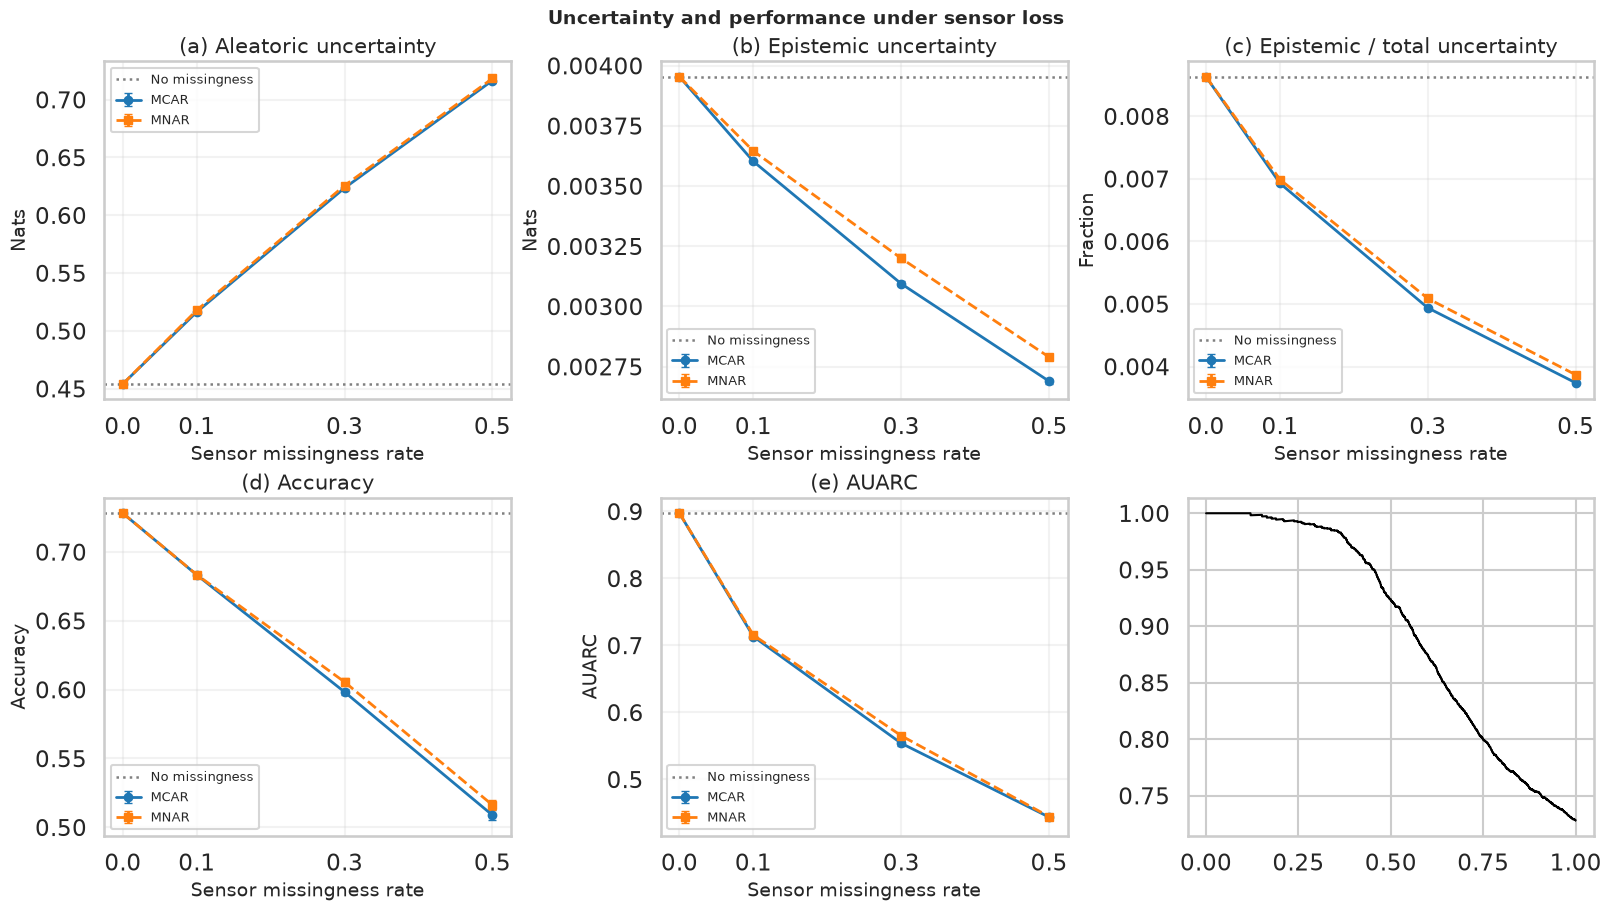

In [140]:
# Regenerate the presentation figures with cleaner fonts and labels
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "legend.fontsize": 9,
})

line_styles = {
    "MCAR": {"color": "#1f77b4", "marker": "o", "linestyle": "-", "label": "MCAR"},
    "MNAR": {"color": "#ff7f0e", "marker": "s", "linestyle": "--", "label": "MNAR"},
}
rate_labels = ["0.0", "0.1", "0.3", "0.5"]

def style_axis(ax, ylabel):
    ax.set_xlabel("Sensor missingness rate")
    ax.set_ylabel(ylabel)
    ax.set_xticks(presentation_rates)
    ax.set_xticklabels(rate_labels)
    ax.grid(alpha=0.25)

def plot_curve(ax, summary, metric, ci_col, ylabel, clean_val):
    for mechanism in ["MCAR", "MNAR"]:
        subset = summary[summary["mechanism"] == mechanism].sort_values("rate")
        style = line_styles[mechanism]
        ax.errorbar(subset["rate"], subset[metric], yerr=subset[ci_col],
                    linewidth=2, markersize=6, capsize=3, **style)
    ax.axhline(clean_val, color="gray", linestyle=":", linewidth=1.8, label="No missingness")
    style_axis(ax, ylabel)

# Figure 1: performance degradation
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)
fig.suptitle("Performance degradation as sensors go missing", fontsize=14, fontweight="bold")
for ax, metric, ci_col, title, ylabel, clean_val in [
    (axes[0], "accuracy", "accuracy_ci95", "Accuracy", "Accuracy", clean_result["accuracy"]),
    (axes[1], "macro_f1", "macro_f1_ci95", "Macro F1", "Macro F1", clean_result["macro_f1"]),
    (axes[2], "ece", "ece_ci95", "Calibration error (ECE)", "ECE", clean_result["ece"]),
]:
    plot_curve(ax, presentation_summary_df, metric, ci_col, ylabel, clean_val)
    ax.set_title(title)
    ax.legend()
fig.savefig(new_figure_root / "01_degradation_three_panel_natural.png", dpi=250, bbox_inches="tight")
plt.show()
plt.close(fig)
print("Saved: 01_degradation_three_panel_natural.png")

# Figure 2: uncertainty and selective prediction
fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)
fig.suptitle("Uncertainty and performance under sensor loss", fontsize=14, fontweight="bold")
for ax, metric, ci_col, title, ylabel, clean_val in [
    (axes[0, 0], "aleatoric", "aleatoric_ci95", "(a) Aleatoric uncertainty", "Nats", clean_result["aleatoric_uncertainty"]),
    (axes[0, 1], "bald", "bald_ci95", "(b) Epistemic uncertainty", "Nats", clean_result["epistemic_uncertainty"]),
    (axes[0, 2], "bald_fraction", "bald_fraction_ci95", "(c) Epistemic / total uncertainty", "Fraction",
     clean_result["epistemic_uncertainty"] / max(clean_result["total_uncertainty"], 1e-12)),
    (axes[1, 0], "accuracy", "accuracy_ci95", "(d) Accuracy", "Accuracy", clean_result["accuracy"]),
    (axes[1, 1], "auarc", "auarc_ci95", "(e) AUARC", "AUARC",
     presentation_summary_df.loc[presentation_summary_df["rate"].eq(0), "auarc"].iloc[0]),
]:
    plot_curve(ax, presentation_summary_df, metric, ci_col, ylabel, clean_val)
    ax.set_title(title)
    ax.legend()

selective_ax = axes[1, 2]
clean_coverage, clean_risk = risk_coverage_curve(
    clean_result["details"]["labels"], clean_result["details"]["predictions"],
    clean_result["details"]["epistemic_uncertainty"])
selective_ax.plot(clean_coverage, 1 - clean_risk, color="black", linewidth=1.5, label="No missingness")
for mechanism in ["MCAR", "MNAR"]:
    details = condition_details[f"{mechanism}__all_modalities__0.5__0"]
    coverage, risk = risk_coverage_curve(details["labels"], details["predictions"], details["epistemic_uncertainty"])
    style = line_styles[mechanism]
    selective_ax.plot(coverage, 1 - risk, markevery=max(1, len(coverage) // 12),
                       linewidth=1.5, label=f"{style['label']} at 0.5", **style)
selective_ax.set_title("(f) Accuracy vs. coverage")
selective_ax.set_xlabel("Fraction of predictions kept")
selective_ax.set_ylabel("Accuracy on kept predictions")
selective_ax.set_xlim(0, 1)
selective_ax.set_ylim(0, 1.05)
selective_ax.grid(alpha=0.25)
selective_ax.legend()
fig.savefig(new_figure_root / "02_uq_bald_six_panel_natural.png", dpi=250, bbox_inches="tight")
plt.show()
plt.close(fig)
print("Saved: 02_uq_bald_six_panel_natural.png")

# Figure 3: aleatoric vs. epistemic uncertainty
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
fig.suptitle("How uncertainty responds to missing sensors", fontsize=15, fontweight="bold")
plot_curve(axes[0], presentation_summary_df, "aleatoric", "aleatoric_ci95", "Nats", clean_result["aleatoric_uncertainty"])
axes[0].set_title("Aleatoric uncertainty (data)")
axes[0].legend()
plot_curve(axes[1], presentation_summary_df, "bald", "bald_ci95", "Nats", clean_result["epistemic_uncertainty"])
axes[1].set_title("Epistemic uncertainty (model)")
axes[1].legend()
fig.savefig(new_figure_root / "03_aleatoric_vs_bald_natural.png", dpi=250, bbox_inches="tight")
plt.show()
plt.close(fig)
print("Saved: 03_aleatoric_vs_bald_natural.png")

## mu sweep

`FEDPROX_MU` was just set to 0.01 with nothing to compare it against. Sweeping mu (including 0, i.e. plain FedAvg) across a few seeds and checking both clean-test and 50%-MNAR performance shows whether the proximal term is actually doing anything here.

In [141]:
import copy as _copy


def train_federated_general(
    global_model,
    seed,
    mu,
    checkpoint_path=None,
    participation_rate=1.0,
    rounds=None,
    verbose=True,
):
    # Same as train_federated() above, but mu and participation_rate are
    # explicit arguments instead of coming from the TRAINING_MODE/FEDPROX_MU
    # globals, so it can be reused for the mu sweep and the dropout test below.
    if federated_client_datasets is None:
        raise RuntimeError("Run the federated client-partition cell first")

    set_seed = globals().get("set_experiment_seed")
    if set_seed is not None:
        set_seed(seed)
    else:
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

    n_rounds = rounds if rounds is not None else COMMUNICATION_ROUNDS
    n_clients = len(federated_client_datasets)
    n_participants = max(2, int(np.ceil(n_clients * participation_rate)))

    best_validation_f1 = -np.inf
    best_state = _copy.deepcopy(global_model.state_dict())
    rounds_without_improvement = 0
    history = []

    for round_id in range(1, n_rounds + 1):
        if participation_rate < 1.0:
            round_rng = np.random.default_rng(seed * 100000 + round_id)
            participants = round_rng.choice(n_clients, size=n_participants, replace=False)
        else:
            participants = np.arange(n_clients)

        updates = []
        for client_id in participants:
            update = train_local_client(
                global_model,
                federated_client_datasets[client_id],
                mu=mu,
                round_seed=seed * 100000 + round_id * 100 + int(client_id),
            )
            updates.append(update)

        global_model.load_state_dict(sample_weighted_average(updates))
        global_model.to(DEVICE)
        validation_accuracy, validation_f1 = evaluate_model(global_model, validation_loader)

        history.append({
            "round": round_id,
            "seed": seed,
            "mu": mu,
            "participation_rate": participation_rate,
            "n_participants": len(participants),
            "validation_accuracy": validation_accuracy,
            "validation_macro_f1": validation_f1,
        })
        if verbose:
            print(
                f"Round {round_id:02d} | mu={mu:g} | "
                f"participants={len(participants)}/{n_clients} | "
                f"Val acc: {validation_accuracy:.3f} | Val Macro F1: {validation_f1:.3f}"
            )

        if validation_f1 > best_validation_f1:
            best_validation_f1 = validation_f1
            best_state = _copy.deepcopy(global_model.state_dict())
            rounds_without_improvement = 0
        else:
            rounds_without_improvement += 1
            if rounds_without_improvement >= early_stopping_patience:
                if verbose:
                    print("Early stopping: validation Macro F1 did not improve.")
                break

    global_model.load_state_dict(best_state)
    history_df = pd.DataFrame(history)
    if checkpoint_path is not None:
        torch.save({
            "model_state": best_state,
            "mu": mu,
            "seed": seed,
            "participation_rate": participation_rate,
            "best_validation_macro_f1": float(best_validation_f1),
        }, checkpoint_path)
    return global_model, best_validation_f1, history_df


In [142]:
# Train FedAvg (mu=0) and FedProx across a few mu values and seeds
mu_sweep_values = [0.0, 0.01]
mu_sweep_seeds = [42, 264]
mu_sweep_mc_passes = 10  # lighter than the 20 used for the main UQ analysis, just to keep this ablation fast

mu_sweep_root = results_root / "fedprox_mu_sweep"
mu_sweep_root.mkdir(parents=True, exist_ok=True)

test_mnar_scores_sweep = mnar_scores_by_modality[test_indices]
mu_sweep_rows = []

for mu in mu_sweep_values:
    for seed in mu_sweep_seeds:
        model = PresenceAwareFusion().to(DEVICE)
        checkpoint_path = mu_sweep_root / f"fusion_model_mu_{mu:g}_seed_{seed}.pt"
        trained_model, best_val_f1, _ = train_federated_general(
            global_model=model,
            seed=seed,
            mu=mu,
            checkpoint_path=checkpoint_path,
            participation_rate=1.0,
            verbose=False,
        )

        clean_accuracy, clean_macro_f1 = evaluate_model(trained_model, test_loader)

        stress_rng = np.random.default_rng(700_000 + int(mu * 1000) + seed)
        stress_mask = make_presence_mask(
            len(test_indices), [0, 1, 2, 3], 0.5, stress_rng, scores=test_mnar_scores_sweep
        )
        stress_result = evaluate_uq_condition(trained_model, test_loader, stress_mask, mu_sweep_mc_passes)

        mu_sweep_rows.append({
            "mu": mu,
            "seed": seed,
            "best_validation_macro_f1": best_val_f1,
            "clean_test_accuracy": clean_accuracy,
            "clean_test_macro_f1": clean_macro_f1,
            "mnar50_accuracy": stress_result["accuracy"],
            "mnar50_macro_f1": stress_result["macro_f1"],
            "mnar50_ece": stress_result["ece"],
        })
        print(
            f"mu={mu:<6g} seed={seed} | clean F1={clean_macro_f1:.3f} | "
            f"MNAR50 F1={stress_result['macro_f1']:.3f} | MNAR50 ECE={stress_result['ece']:.3f}"
        )

mu_sweep_df = pd.DataFrame(mu_sweep_rows)
mu_sweep_df.to_csv(mu_sweep_root / "mu_sweep_raw.csv", index=False)
display(mu_sweep_df.round(4))

mu=0      seed=42 | clean F1=0.632 | MNAR50 F1=0.501 | MNAR50 ECE=0.115
mu=0      seed=264 | clean F1=0.608 | MNAR50 F1=0.463 | MNAR50 ECE=0.172
mu=0.01   seed=42 | clean F1=0.642 | MNAR50 F1=0.456 | MNAR50 ECE=0.152
mu=0.01   seed=264 | clean F1=0.613 | MNAR50 F1=0.486 | MNAR50 ECE=0.134


,mu,seed,best_validation_macro_f1,clean_test_accuracy,clean_test_macro_f1,mnar50_accuracy,mnar50_macro_f1,mnar50_ece
0,0.00,42,0.8717,0.7559,0.6316,0.5498,0.5015,0.1145
1,0.00,264,0.8732,0.7361,0.6080,0.4934,0.4630,0.1719
2,0.01,42,0.8697,0.7300,0.6424,0.5063,0.4564,0.1524
3,0.01,264,0.8753,0.7326,0.6125,0.5603,0.4857,0.1340


,mu,clean_test_macro_f1_mean,clean_test_macro_f1_ci95,mnar50_macro_f1_mean,mnar50_macro_f1_ci95,mnar50_ece_mean,mnar50_ece_ci95,best_validation_macro_f1_mean,best_validation_macro_f1_ci95
0,0.00,0.6198,0.0231,0.4822,0.0377,0.1432,0.0563,0.8724,0.0015
1,0.01,0.6275,0.0292,0.4710,0.0288,0.1432,0.0180,0.8725,0.0055


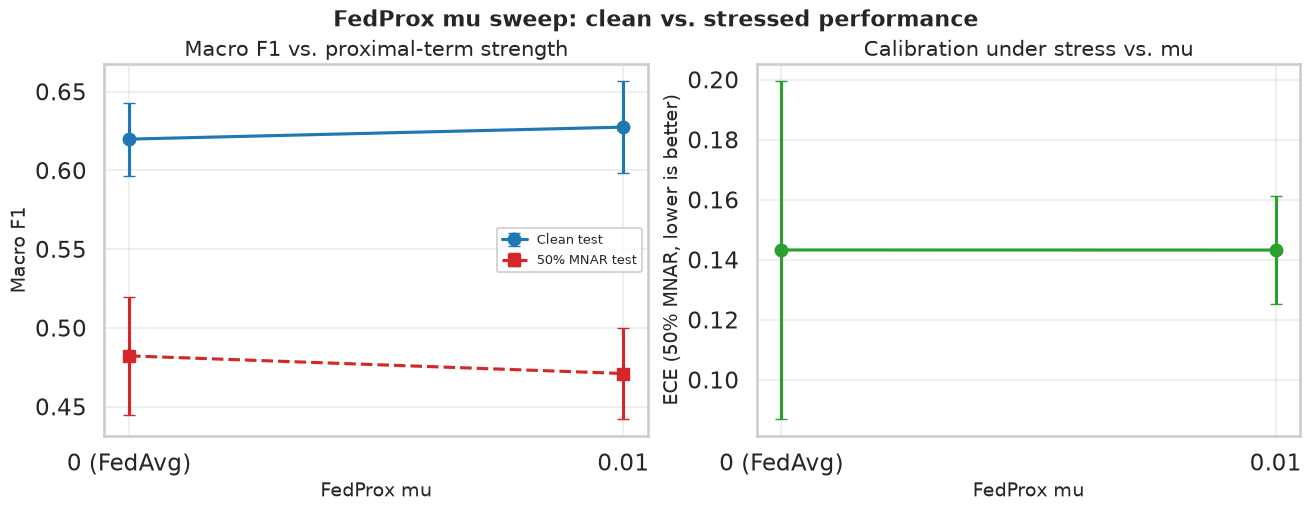

Saved: /Users/calebcooper/nuScenes/uq_results/object_classification/fedprox_mu_sweep/mu_sweep_macro_f1_and_ece.png

Best mu by 50% MNAR macro F1: 0 (F1=0.482 ± 0.038)


In [143]:
# Aggregate across seeds and plot Macro F1 / ECE vs. mu
def summarize_by_mu(df, metric):
    rows = []
    for mu in mu_sweep_values:
        subset = df.loc[df["mu"] == mu, metric]
        mean, ci = summarize_values(subset)
        rows.append({"mu": mu, f"{metric}_mean": mean, f"{metric}_ci95": ci})
    return pd.DataFrame(rows)

mu_sweep_summary_df = summarize_by_mu(mu_sweep_df, "clean_test_macro_f1")
for metric in ["mnar50_macro_f1", "mnar50_ece", "best_validation_macro_f1"]:
    mu_sweep_summary_df = mu_sweep_summary_df.merge(summarize_by_mu(mu_sweep_df, metric), on="mu")

mu_sweep_summary_df.to_csv(mu_sweep_root / "mu_sweep_summary.csv", index=False)
display(mu_sweep_summary_df.round(4))

mu_labels = ["0 (FedAvg)" if mu == 0 else f"{mu:g}" for mu in mu_sweep_values]
x_positions = np.arange(len(mu_sweep_values))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

axes[0].errorbar(x_positions, mu_sweep_summary_df["clean_test_macro_f1_mean"],
                  yerr=mu_sweep_summary_df["clean_test_macro_f1_ci95"],
                  marker="o", color="#1f77b4", capsize=4, label="Clean test")
axes[0].errorbar(x_positions, mu_sweep_summary_df["mnar50_macro_f1_mean"],
                  yerr=mu_sweep_summary_df["mnar50_macro_f1_ci95"],
                  marker="s", linestyle="--", color="#d62728", capsize=4, label="50% MNAR test")
axes[0].set_xticks(x_positions)
axes[0].set_xticklabels(mu_labels)
axes[0].set_xlabel("FedProx mu")
axes[0].set_ylabel("Macro F1")
axes[0].set_title("Macro F1 vs. proximal-term strength")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].errorbar(x_positions, mu_sweep_summary_df["mnar50_ece_mean"],
                  yerr=mu_sweep_summary_df["mnar50_ece_ci95"],
                  marker="o", color="#2ca02c", capsize=4)
axes[1].set_xticks(x_positions)
axes[1].set_xticklabels(mu_labels)
axes[1].set_xlabel("FedProx mu")
axes[1].set_ylabel("ECE (50% MNAR, lower is better)")
axes[1].set_title("Calibration under stress vs. mu")
axes[1].grid(alpha=0.3)

fig.suptitle("FedProx mu sweep: clean vs. stressed performance", fontweight="bold")
sweep_figure_path = mu_sweep_root / "mu_sweep_macro_f1_and_ece.png"
fig.savefig(sweep_figure_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", sweep_figure_path)

best_row = mu_sweep_summary_df.loc[mu_sweep_summary_df["mnar50_macro_f1_mean"].idxmax()]
print(
    f"\nBest mu by 50% MNAR macro F1: {best_row['mu']:g} "
    f"(F1={best_row['mnar50_macro_f1_mean']:.3f} ± {best_row['mnar50_macro_f1_ci95']:.3f})"
)


## Client dropout (optional)

With only 4 clients (one per training scene), dropping clients means each round runs on 2-3 out of 4 rather than a large pool losing a small slice — a rough sanity check that training survives a missing client, not a real partial-participation benchmark. Splitting scenes into more, smaller clients would make this a more meaningful test.

In [144]:
# Partial client participation (dropout) stress test
dropout_participation_rates = [1.0, 0.75, 0.5]
dropout_seeds = [42, 264]
dropout_mu = float(best_row["mu"])  # reuse the best mu found in the sweep above

dropout_root = results_root / "fedprox_client_dropout"
dropout_root.mkdir(parents=True, exist_ok=True)

dropout_rows = []
for participation_rate in dropout_participation_rates:
    for seed in dropout_seeds:
        model = PresenceAwareFusion().to(DEVICE)
        trained_model, best_val_f1, _ = train_federated_general(
            global_model=model,
            seed=seed,
            mu=dropout_mu,
            checkpoint_path=None,
            participation_rate=participation_rate,
            verbose=False,
        )
        clean_accuracy, clean_macro_f1 = evaluate_model(trained_model, test_loader)
        dropout_rows.append({
            "participation_rate": participation_rate,
            "seed": seed,
            "mu": dropout_mu,
            "best_validation_macro_f1": best_val_f1,
            "clean_test_accuracy": clean_accuracy,
            "clean_test_macro_f1": clean_macro_f1,
        })
        print(
            f"participation={participation_rate:.2f} seed={seed} | "
            f"val F1={best_val_f1:.3f} | test F1={clean_macro_f1:.3f}"
        )

dropout_df = pd.DataFrame(dropout_rows)
dropout_df.to_csv(dropout_root / "client_dropout_raw.csv", index=False)

dropout_summary_rows = []
for rate in dropout_participation_rates:
    subset = dropout_df.loc[dropout_df["participation_rate"] == rate, "clean_test_macro_f1"]
    mean, ci = summarize_values(subset)
    dropout_summary_rows.append({"participation_rate": rate, "clean_test_macro_f1_mean": mean, "clean_test_macro_f1_ci95": ci})
dropout_summary_df = pd.DataFrame(dropout_summary_rows)
dropout_summary_df.to_csv(dropout_root / "client_dropout_summary.csv", index=False)
display(dropout_summary_df.round(4))

fig, axis = plt.subplots(figsize=(7, 5))
axis.errorbar(
    dropout_summary_df["participation_rate"], dropout_summary_df["clean_test_macro_f1_mean"],
    yerr=dropout_summary_df["clean_test_macro_f1_ci95"], marker="o", color="#9467bd", capsize=4)
axis.set_xlabel("Client participation rate")
axis.set_ylabel("Clean test Macro F1")
axis.set_title(f"Effect of client dropout (mu={dropout_mu:g})", fontweight="bold")
axis.set_xticks(dropout_participation_rates)
axis.grid(alpha=0.3)
dropout_figure_path = dropout_root / "client_dropout_macro_f1.png"
fig.savefig(dropout_figure_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", dropout_figure_path)

participation=1.00 seed=42 | val F1=0.866 | test F1=0.608
participation=1.00 seed=264 | val F1=0.868 | test F1=0.604


KeyboardInterrupt: 

## Local epochs

mu=0, 0.001, and 0.01 all scored about the same in the sweep above, which fits LOCAL_EPOCHS=1 giving clients too little room to drift for the proximal term to matter. Sweeping local epochs (1, 2, 4) at the best mu from that sweep checks whether more local computation changes that, and whether the two clients missing an entire class start overfitting harder to their own labels as local epochs grow.

epochs=1 seed=42 | clean F1=0.620 | MNAR50 F1=0.481 | MNAR50 ECE=0.136
epochs=1 seed=43 | clean F1=0.581 | MNAR50 F1=0.428 | MNAR50 ECE=0.114
epochs=1 seed=44 | clean F1=0.593 | MNAR50 F1=0.466 | MNAR50 ECE=0.165
epochs=1 seed=264 | clean F1=0.629 | MNAR50 F1=0.458 | MNAR50 ECE=0.166
epochs=2 seed=42 | clean F1=0.645 | MNAR50 F1=0.484 | MNAR50 ECE=0.127
epochs=2 seed=43 | clean F1=0.622 | MNAR50 F1=0.502 | MNAR50 ECE=0.081
epochs=2 seed=44 | clean F1=0.562 | MNAR50 F1=0.437 | MNAR50 ECE=0.126
epochs=2 seed=264 | clean F1=0.565 | MNAR50 F1=0.434 | MNAR50 ECE=0.162
epochs=4 seed=42 | clean F1=0.565 | MNAR50 F1=0.441 | MNAR50 ECE=0.114
epochs=4 seed=43 | clean F1=0.671 | MNAR50 F1=0.533 | MNAR50 ECE=0.115
epochs=4 seed=44 | clean F1=0.655 | MNAR50 F1=0.509 | MNAR50 ECE=0.121
epochs=4 seed=264 | clean F1=0.642 | MNAR50 F1=0.480 | MNAR50 ECE=0.140


,local_epochs,seed,mu,best_validation_macro_f1,clean_test_accuracy,clean_test_macro_f1,mnar50_accuracy,mnar50_macro_f1,mnar50_ece
0,1,42,0.0,0.8762,0.7492,0.6198,0.5356,0.4806,0.1359
1,1,43,0.0,0.8787,0.7214,0.5811,0.5270,0.4285,0.1140
2,1,44,0.0,0.8764,0.7406,0.5929,0.5253,0.4661,0.1654
3,1,264,0.0,0.8578,0.7427,0.6290,0.4898,0.4583,0.1660
4,2,42,0.0,0.8379,0.7617,0.6446,0.5666,0.4840,0.1266
5,2,43,0.0,0.8356,0.7565,0.6223,0.5993,0.5021,0.0811
6,2,44,0.0,0.8664,0.7079,0.5616,0.4762,0.4366,0.1261
7,2,264,0.0,0.8435,0.7399,0.5653,0.5025,0.4337,0.1617
8,4,42,0.0,0.8259,0.7320,0.5651,0.5778,0.4408,0.1143
9,4,43,0.0,0.8157,0.7647,0.6706,0.5827,0.5333,0.1151


,local_epochs,clean_test_macro_f1_mean,clean_test_macro_f1_ci95,mnar50_macro_f1_mean,mnar50_macro_f1_ci95,mnar50_ece_mean,mnar50_ece_ci95,best_validation_macro_f1_mean,best_validation_macro_f1_ci95
0,1,0.6057,0.0220,0.4584,0.0215,0.1453,0.0246,0.8723,0.0095
1,2,0.5985,0.0406,0.4641,0.0336,0.1239,0.0324,0.8458,0.0138
2,4,0.6330,0.0459,0.4907,0.0390,0.1227,0.0119,0.8189,0.0132


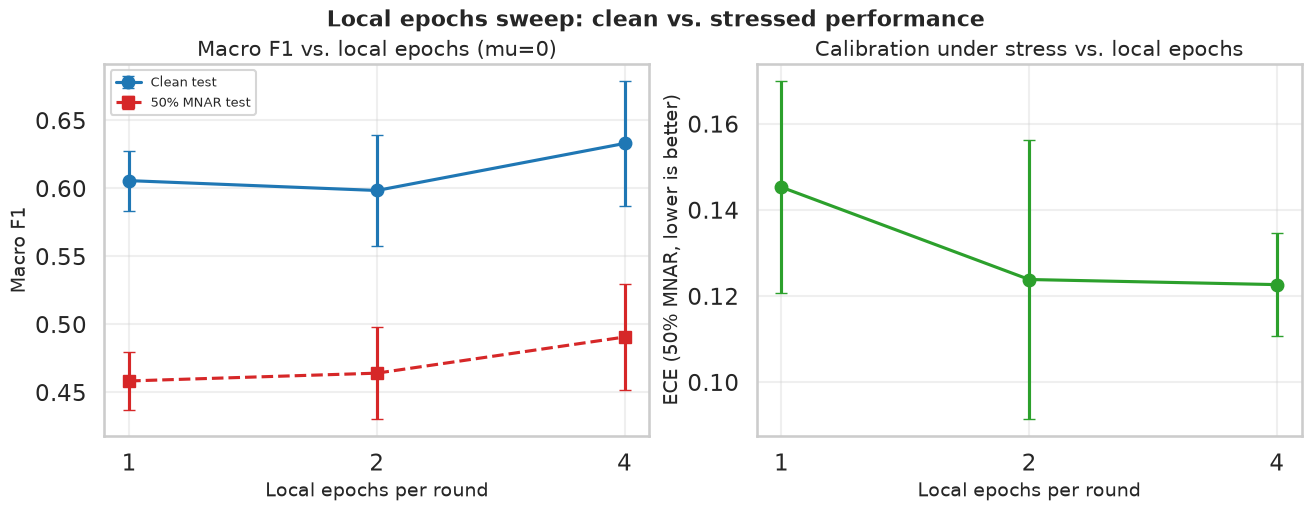

Saved: /Users/calebcooper/nuScenes/uq_results/object_classification/fedprox_local_epochs/local_epochs_macro_f1_and_ece.png


In [145]:
# Local epochs sweep, at the mu selected above
epoch_sweep_values = [1, 2, 4]
epoch_sweep_seeds = [42, 43, 44, 264]
epoch_sweep_mu = dropout_mu  # reuse the best mu from the sweep above

epoch_sweep_root = results_root / "fedprox_local_epochs"
epoch_sweep_root.mkdir(parents=True, exist_ok=True)

test_mnar_scores_epoch = mnar_scores_by_modality[test_indices]
epoch_sweep_rows = []
original_local_epochs = LOCAL_EPOCHS

for epochs in epoch_sweep_values:
    LOCAL_EPOCHS = epochs
    for seed in epoch_sweep_seeds:
        model = PresenceAwareFusion().to(DEVICE)
        trained_model, best_val_f1, _ = train_federated_general(
            global_model=model,
            seed=seed,
            mu=epoch_sweep_mu,
            checkpoint_path=None,
            participation_rate=1.0,
            verbose=False,
        )

        clean_accuracy, clean_macro_f1 = evaluate_model(trained_model, test_loader)

        stress_rng = np.random.default_rng(800_000 + epochs * 1000 + seed)
        stress_mask = make_presence_mask(
            len(test_indices), [0, 1, 2, 3], 0.5, stress_rng, scores=test_mnar_scores_epoch
        )
        stress_result = evaluate_uq_condition(trained_model, test_loader, stress_mask, mu_sweep_mc_passes)

        epoch_sweep_rows.append({
            "local_epochs": epochs,
            "seed": seed,
            "mu": epoch_sweep_mu,
            "best_validation_macro_f1": best_val_f1,
            "clean_test_accuracy": clean_accuracy,
            "clean_test_macro_f1": clean_macro_f1,
            "mnar50_accuracy": stress_result["accuracy"],
            "mnar50_macro_f1": stress_result["macro_f1"],
            "mnar50_ece": stress_result["ece"],
        })
        print(
            f"epochs={epochs} seed={seed} | clean F1={clean_macro_f1:.3f} | "
            f"MNAR50 F1={stress_result['macro_f1']:.3f} | MNAR50 ECE={stress_result['ece']:.3f}"
        )

LOCAL_EPOCHS = original_local_epochs

epoch_sweep_df = pd.DataFrame(epoch_sweep_rows)
epoch_sweep_df.to_csv(epoch_sweep_root / "local_epochs_sweep_raw.csv", index=False)
display(epoch_sweep_df.round(4))


def summarize_by_epochs(df, metric):
    rows = []
    for epochs in epoch_sweep_values:
        subset = df.loc[df["local_epochs"] == epochs, metric]
        mean, ci = summarize_values(subset)
        rows.append({"local_epochs": epochs, f"{metric}_mean": mean, f"{metric}_ci95": ci})
    return pd.DataFrame(rows)


epoch_summary_df = summarize_by_epochs(epoch_sweep_df, "clean_test_macro_f1")
for metric in ["mnar50_macro_f1", "mnar50_ece", "best_validation_macro_f1"]:
    epoch_summary_df = epoch_summary_df.merge(summarize_by_epochs(epoch_sweep_df, metric), on="local_epochs")

epoch_summary_df.to_csv(epoch_sweep_root / "local_epochs_sweep_summary.csv", index=False)
display(epoch_summary_df.round(4))

x_positions = np.arange(len(epoch_sweep_values))
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

axes[0].errorbar(x_positions, epoch_summary_df["clean_test_macro_f1_mean"],
                  yerr=epoch_summary_df["clean_test_macro_f1_ci95"],
                  marker="o", color="#1f77b4", capsize=4, label="Clean test")
axes[0].errorbar(x_positions, epoch_summary_df["mnar50_macro_f1_mean"],
                  yerr=epoch_summary_df["mnar50_macro_f1_ci95"],
                  marker="s", linestyle="--", color="#d62728", capsize=4, label="50% MNAR test")
axes[0].set_xticks(x_positions)
axes[0].set_xticklabels([str(e) for e in epoch_sweep_values])
axes[0].set_xlabel("Local epochs per round")
axes[0].set_ylabel("Macro F1")
axes[0].set_title(f"Macro F1 vs. local epochs (mu={epoch_sweep_mu:g})")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].errorbar(x_positions, epoch_summary_df["mnar50_ece_mean"],
                  yerr=epoch_summary_df["mnar50_ece_ci95"],
                  marker="o", color="#2ca02c", capsize=4)
axes[1].set_xticks(x_positions)
axes[1].set_xticklabels([str(e) for e in epoch_sweep_values])
axes[1].set_xlabel("Local epochs per round")
axes[1].set_ylabel("ECE (50% MNAR, lower is better)")
axes[1].set_title("Calibration under stress vs. local epochs")
axes[1].grid(alpha=0.3)

fig.suptitle("Local epochs sweep: clean vs. stressed performance", fontweight="bold")
epoch_figure_path = epoch_sweep_root / "local_epochs_macro_f1_and_ece.png"
fig.savefig(epoch_figure_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", epoch_figure_path)